<div class="alert alert-block alert-success">
<h1> DATA MINING - PROJECT </h1>
<h2> Group 19 </h2>
<h3> 20225/2026 </h3>

Student Name - António Parafita <br>
Student id - 20250363 <br>

Student Name - Diogo Montenegro <br>
Student id - 20250491 <br>

Student Name - Francisco <br>
Student id - 20250482 <br>

## **Index**<br>



<a class="anchor" id="1st-bullet">    </a>
# 1. Imports

<a class="anchor" id="2st-bullet">    </a>
## 1.1 Import libraries

In [1]:
import sqlite3
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from itertools import product
from sklearn.neighbors import NearestNeighbors
#maps
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap
from IPython.display import IFrame

from ydata_profiling import ProfileReport

# new libraries for clustering evaluation
import matplotlib.cm as cm
from sklearn.metrics import silhouette_score, silhouette_samples # new library
from sklearn.cluster import KMeans, MeanShift, DBSCAN, estimate_bandwidth, AgglomerativeClustering  
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set_style("ticks")

## Functions

In [2]:
def detect_outliers_iqr(data, threshold=0.01):
    """
    Detects outliers in numerical columns using the Interquartile Range (IQR) method
    and optionally reports columns where the percentage of outliers exceeds a threshold.
    A boxplot highlighting the outliers is also generated for each column.

    Parameters:
        data (DataFrame): 
            The input dataset containing numerical variables.
    """
    outlier_summary = []
    for col in data.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Identify outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        n_outliers = len(outliers)
        pct_outliers = 100 * n_outliers / len(data)
        # Print summary
        print(f"Column: {col} - Number of Outliers: {n_outliers}")
        print(f"Column: {col} - % of Outliers: {pct_outliers:.2f}%\n")
        # Add to list if exceeds threshold
        if pct_outliers > threshold * 100:
            outlier_summary.append((col, n_outliers, pct_outliers))
        # Plot boxplot
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=data[col], color='orange')
        sns.stripplot(x=outliers, color='red', size=4, label='Outliers')
        plt.title(f'Boxplot with Outliers for {col}', fontsize=14)
        plt.legend()
        plt.show()
    return pd.DataFrame(outlier_summary, columns=['Column', 'Num_Outliers', 'Pct_Outliers'])

<a class="anchor" id="3st-bullet">    </a>
## 1.2 Import Data

In [3]:
customers = pd.read_csv('data/DM_AIAI_CustomerDB.csv', index_col = 0)
flights = pd.read_csv('data/DM_AIAI_FlightsDB.csv')

In [4]:
df_c = customers.copy()

In [5]:
df_f = flights.copy()

In [6]:
df_f.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

## 2 Data Preprocessing


Before starting, we'll make the changes proposed on the EDA notebook.

In [7]:
df_c['Country'].unique()

array(['Canada'], dtype=object)

Since all the customers are from Canada, we are going to drop this column since this does not give us any relevant information.

In [8]:
df_c = df_c.drop('Country', axis=1)

We also saw that "Location Code" seems random.

In [9]:
df_c.loc[df_c['Postal code'] == 'M2M 7K8', ['City','Postal code','Location Code']]

,City,Postal code,Location Code
14,Toronto,M2M 7K8,Rural
102,Toronto,M2M 7K8,Suburban
143,Toronto,M2M 7K8,Urban
157,Toronto,M2M 7K8,Rural
206,Toronto,M2M 7K8,Suburban
...,...,...,...
16776,Toronto,M2M 7K8,Urban
16795,Toronto,M2M 7K8,Urban
16801,Toronto,M2M 7K8,Suburban
16845,Toronto,M2M 7K8,Urban


As we can observe, people from the same area ("Postal Code") have different "Location Code".

In [10]:
df_c = df_c.drop('Location Code', axis=1)

Finnaly, the names of the customers are also meaningless, since we already have the loyalty number as an identifier, so we are also going to drop it.

In [11]:
df_c = df_c.drop('First Name', axis=1)
df_c = df_c.drop('Last Name', axis=1)
df_c = df_c.drop('Customer Name', axis=1)

In [12]:
df_c

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,100012,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16,100013,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
17,100014,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
18,100015,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


We also saw that "YearMonthDate" is meaningless, since this feature always shows the first day of the month for each activity record.

In [13]:
df_f[['Year','Month','YearMonthDate']].sample(10)

,Year,Month,YearMonthDate
319285,2020,11,11/1/2020
11991,2020,5,5/1/2020
373374,2020,8,8/1/2020
576779,2019,11,11/1/2019
162315,2021,12,12/1/2021
465749,2019,4,4/1/2019
34315,2020,4,4/1/2020
9267,2020,5,5/1/2020
407691,2019,1,1/1/2019
117235,2021,9,9/1/2021


As we can see, this feature does not give us any useful information.

In [14]:
df_f = df_f.drop('YearMonthDate', axis=1)

In [15]:
df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
600423,573972,2019,12,0.0,0.0,0.0,0.00,0.0,0.0
310200,152014,2020,12,5.0,0.0,1802.0,180.00,0.0,0.0
335353,663719,2020,10,0.0,0.0,0.0,0.00,0.0,0.0
588476,835295,2019,11,0.0,0.0,0.0,0.00,0.0,0.0
422484,997654,2019,1,11.7,3.6,12282.3,1228.23,2725.2,27.0
312661,557880,2020,12,12.0,0.0,13435.0,1343.00,0.0,0.0
293279,462279,2020,12,0.0,0.0,0.0,0.00,0.0,0.0
235050,549080,2021,4,4.0,0.0,4034.0,403.00,0.0,0.0
77045,447439,2020,1,0.0,0.0,0.0,0.00,0.0,0.0
181851,642020,2021,9,8.0,4.0,1169.0,116.00,0.0,0.0


We also decided to take a look to the "Postal Code" and "City".

In [16]:
df_c['Postal code'].nunique()

75

In [17]:
df_c['City'].nunique()


29

In [18]:
df_c['Province or State'].nunique()

11

For now, we decided to remove "Postal Code" due to its high cardinality and being to much specific.

In [19]:
df_c = df_c.drop('Postal code', axis=1)

Also, "Latitude" and "Longitude" is extremely specific for a single customer, so we also must remove them.

In [20]:
df_c = df_c.drop('Latitude', axis=1)
df_c = df_c.drop('Longitude', axis=1)

### 2.1 Data types

**Customers dataset**

In [21]:
df_c.sample(10)

,Loyalty#,Province or State,City,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
10960,745901,Ontario,Toronto,female,College,0.0,Single,Star,4/14/2021,NaN,2522.41,2021 Promotion
6186,374736,British Columbia,Vancouver,female,Bachelor,36305.0,Married,Nova,11/5/2016,NaN,4861.37,Standard
11711,834120,Alberta,Banff,female,Bachelor,32720.0,Divorced,Star,10/28/2015,NaN,2695.18,Standard
4931,131673,British Columbia,Vancouver,female,Bachelor,46435.0,Married,Nova,12/17/2019,NaN,3245.33,Standard
6936,308176,British Columbia,Vancouver,male,College,0.0,Married,Nova,3/29/2019,NaN,5678.05,Standard
16453,819267,Alberta,Calgary,male,High School or Below,21708.0,Divorced,Star,12/18/2018,NaN,17930.60,Standard
15237,565040,Alberta,Edmonton,female,College,0.0,Married,Star,4/5/2015,NaN,8470.04,Standard
16293,657492,Ontario,Toronto,male,Bachelor,95140.0,Divorced,Star,1/14/2018,NaN,15228.20,Standard
9241,733907,British Columbia,Whistler,male,Bachelor,31189.0,Single,Nova,10/1/2021,NaN,14244.73,Standard
13587,369715,Manitoba,Winnipeg,male,Bachelor,85721.0,Married,Star,1/8/2021,10/5/2021,5218.34,Standard


In [22]:
df_c.dtypes

Loyalty#                     int64
Province or State           object
City                        object
Gender                      object
Education                   object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [23]:
df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
589114,869265,2019,11,0.0,0.0,0.0,0.00,0.0,0.0
270527,586076,2021,2,0.0,0.0,0.0,0.00,0.0,0.0
87099,502390,2020,1,8.0,1.0,2752.0,275.00,0.0,0.0
470611,858228,2019,4,0.0,0.0,0.0,0.00,0.0,0.0
280343,614634,2021,2,1.0,0.0,12254.0,1225.00,0.0,0.0
516428,601407,2019,7,13.5,4.5,8050.5,805.05,0.0,0.0
420683,901775,2019,1,0.9,0.0,11617.2,1161.72,0.0,0.0
394330,216517,2020,7,16.0,10.0,22890.0,2289.00,0.0,0.0
289693,657748,2021,1,1.0,1.0,13302.0,1330.00,0.0,0.0
1373,256483,2020,6,4.0,1.0,39384.0,3938.00,0.0,0.0


In [24]:
df_f.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

**Set 'EnrollmentDateOpening'& 'CancellationDate' type to *datetime***

In [25]:
df_c['EnrollmentDateOpening'] = pd.to_datetime(
    df_c['EnrollmentDateOpening'],
    errors='coerce'
)

df_c['CancellationDate'] = pd.to_datetime(
    df_c['CancellationDate'],
    errors='coerce'
)

**Changing NumFlights and NumFlightsWithCompanions to int**

In [26]:
df_f['NumFlights'] = df_f['NumFlights'].astype(int)
df_f['NumFlightsWithCompanions'] = df_f['NumFlightsWithCompanions'].astype(int)

**Changing income to int**

In [27]:
df_c["Income"] = df_c["Income"].astype("Int64")

### Check if there are rows where DistanceKM is > 0 and NumFlights == 0 and vice-versa

In [28]:
#lets see the rows where DistanceKM is > 0 and NumFlights == 0 
df_f[(df_f['DistanceKM'] > 0) & (df_f['NumFlights'] == 0)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
19,261109,2021,12,0,0,13736.0,1373.00,0.0,0.0
93,817609,2021,12,0,0,23775.0,2377.00,0.0,0.0
96,192600,2021,12,0,0,5119.0,511.00,0.0,0.0
116,883242,2021,12,0,0,20681.0,2068.00,0.0,0.0
154,493800,2021,12,0,0,17502.0,1750.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...
608166,984636,2019,12,0,0,18302.4,1830.24,0.0,0.0
608303,992488,2019,12,0,0,17276.4,1727.64,0.0,0.0
608323,993650,2019,12,0,0,20648.7,2064.87,0.0,0.0
608346,995128,2019,12,0,0,15497.1,1549.71,0.0,0.0


In [29]:
df_f[(df_f['DistanceKM'] == 0) & (df_f['NumFlights'] > 0)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed


Its looks like a problem from NumFlights since DistanceKM and PointsAccumulated are in sync. We will set thos NumFlights values to missing values

In [30]:
# There are rows where DistanceKM is > 0 and NumFlights == 0, set those NumFlights to nan
df_f.loc[(df_f['DistanceKM'] > 0) & (df_f['NumFlights'] == 0), 'NumFlights'] = np.nan

## Duplicates

In [31]:
# replace "" by nans
df_c.replace("", np.nan, inplace=True)
# count of missing values
df_c.isna().sum()

Loyalty#                       0
Province or State              0
City                           0
Gender                         0
Education                      0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14613
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [32]:
# replace "" by nans
df_f.replace("", np.nan, inplace=True)

# count of missing values
df_f.isna().sum()

Loyalty#                        0
Year                            0
Month                           0
NumFlights                  11752
NumFlightsWithCompanions        0
DistanceKM                      0
PointsAccumulated               0
PointsRedeemed                  0
DollarCostPointsRedeemed        0
dtype: int64

**Checking for duplicates and dropping them**

In [33]:
df_c.duplicated().sum()

0

In [34]:
df_f.duplicated().sum()

2903

In [35]:
df_f = df_f.drop_duplicates()
df_f.duplicated().sum()

0

— We should drop them because a customer shouldn't have the same month of the same year registered more than once

**Checking if Loyalty# has repeated values**

In [36]:
# How many Loyalty# have duplicates?
print(df_c['Loyalty#'].value_counts()[df_c['Loyalty#'].value_counts() > 1].size)
print(df_f['Loyalty#'].value_counts()[df_f['Loyalty#'].value_counts() > 1].size)

163
16737


In [37]:
#checking if there are extra ids in flights dataset
extra_ids = set(df_f['Loyalty#']) - set(df_c['Loyalty#'])
print( len(extra_ids))

0


In [38]:
#checking how many customer ids don't have flights
ids_without_flights = set(df_c['Loyalty#']) - set(df_f['Loyalty#'])
print( len(ids_without_flights))


20


In [39]:
# 1) Find problematic Loyalty# values in the df_c (appear more than once)
dupe_ids_cust = (
    df_c['Loyalty#']
    .value_counts()
    .loc[lambda s: s > 1]
    .index
)

# 2) Completely remove those values from both datasets
df_c = df_c[~df_c['Loyalty#'].isin(dupe_ids_cust)].copy()
df_f = df_f[~df_f['Loyalty#'].isin(dupe_ids_cust)].copy()

**Checking zeros and negative values**

In [40]:
# Check for zeros in customer dataset
(df_c == 0).sum()

Loyalty#                      0
Province or State             0
City                          0
Gender                        0
Education                     0
Income                     4198
Marital Status                0
LoyaltyStatus                 0
EnrollmentDateOpening         0
CancellationDate              0
Customer Lifetime Value       0
EnrollmentType                0
dtype: Int64

In [41]:
# Check for negative values in customer dataset
(df_c.select_dtypes(include=['number']) < 0).sum()

Loyalty#                   0
Income                     0
Customer Lifetime Value    0
dtype: Int64

In [42]:
# Check for zeros in flights dataset
(df_f == 0).sum()

Loyalty#                         0
Year                             0
Month                            0
NumFlights                  291496
NumFlightsWithCompanions    447294
DistanceKM                  291496
PointsAccumulated           291496
PointsRedeemed              561780
DollarCostPointsRedeemed    561780
dtype: int64

In [43]:
# Check for negative values in flights dataset
(df_f.select_dtypes(include=['number']) < 0).sum()

Loyalty#                    0
Year                        0
Month                       0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

## Feature Creation

**"Days_sub" - number of days subscribed in program**

In [44]:
# Converte to datetime
df_c["EnrollmentDateOpening"] = pd.to_datetime(df_c["EnrollmentDateOpening"], errors="coerce")
df_c["CancellationDate"] = pd.to_datetime(df_c["CancellationDate"], errors="coerce")

# Assume that "today" is the last recent date found in dataset
max_date = max(df_c["EnrollmentDateOpening"].max(), df_c["CancellationDate"].max())
print(f"Most recent date extracted: {max_date}\n")

# Compute difference in days
df_c["Days_sub"] = (
    df_c["CancellationDate"].fillna(max_date) - df_c["EnrollmentDateOpening"]
).dt.days

# If negative value, assume there was a switch of dates 
df_c["Days_sub"] = df_c["Days_sub"].abs()
# Description (no negative value)
print(df_c["Days_sub"].describe())

Most recent date extracted: 2021-12-30 00:00:00

count    16594.000000
mean      1098.976076
std        737.900363
min          0.000000
25%        389.000000
50%       1015.000000
75%       1744.000000
max       2465.000000
Name: Days_sub, dtype: float64


Since we've created this new feature, we can now drop both **"EnrollmentDateOpening"** and **"CancellationDate"** since having this have the same meaning.

In [45]:
df_c = df_c.drop(['EnrollmentDateOpening', 'CancellationDate'], axis=1)

***AvgFlightDistance_month* — Average distance per flight taken by a customer in a specific month**

In [46]:
df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
285309,510865,2020,11,0.0,0,0.0,0.00,0.0,0.0,0.000
137667,461012,2021,5,0.0,0,0.0,0.00,0.0,0.0,0.000
86106,555112,2020,1,0.0,0,0.0,0.00,0.0,0.0,0.000
200841,740703,2021,8,0.0,0,0.0,0.00,0.0,0.0,0.000
6577,177713,2020,6,0.0,0,0.0,0.00,0.0,0.0,0.000
553551,773986,2019,9,4.0,0,22272.3,2227.23,0.0,0.0,5568.075
150531,904283,2021,5,3.0,0,16299.0,1629.00,0.0,0.0,5433.000
588701,846374,2019,11,0.0,0,0.0,0.00,0.0,0.0,0.000
359614,898427,2020,8,0.0,0,0.0,0.00,0.0,0.0,0.000
57693,287198,2020,3,10.0,3,16499.0,1649.00,0.0,0.0,1649.900


## Dealing with outliers

<h1>df_c

In [47]:
df_c.columns

Index(['Loyalty#', 'Province or State', 'City', 'Gender', 'Education',
       'Income', 'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub'],
      dtype='object')

In [48]:
df_c_metric = ['Customer Lifetime Value', 'Income', 'Days_sub']

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.80%



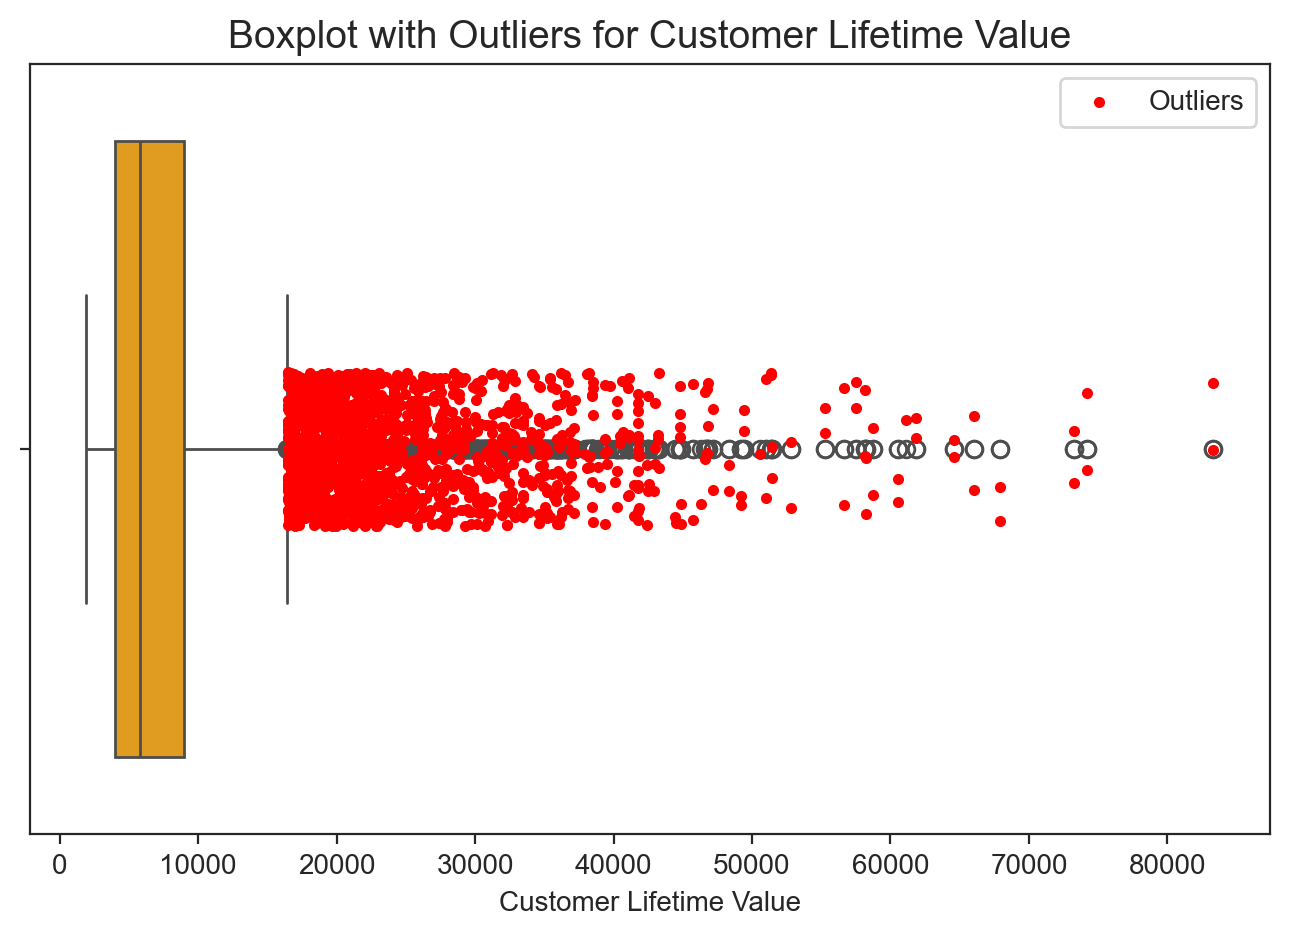

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


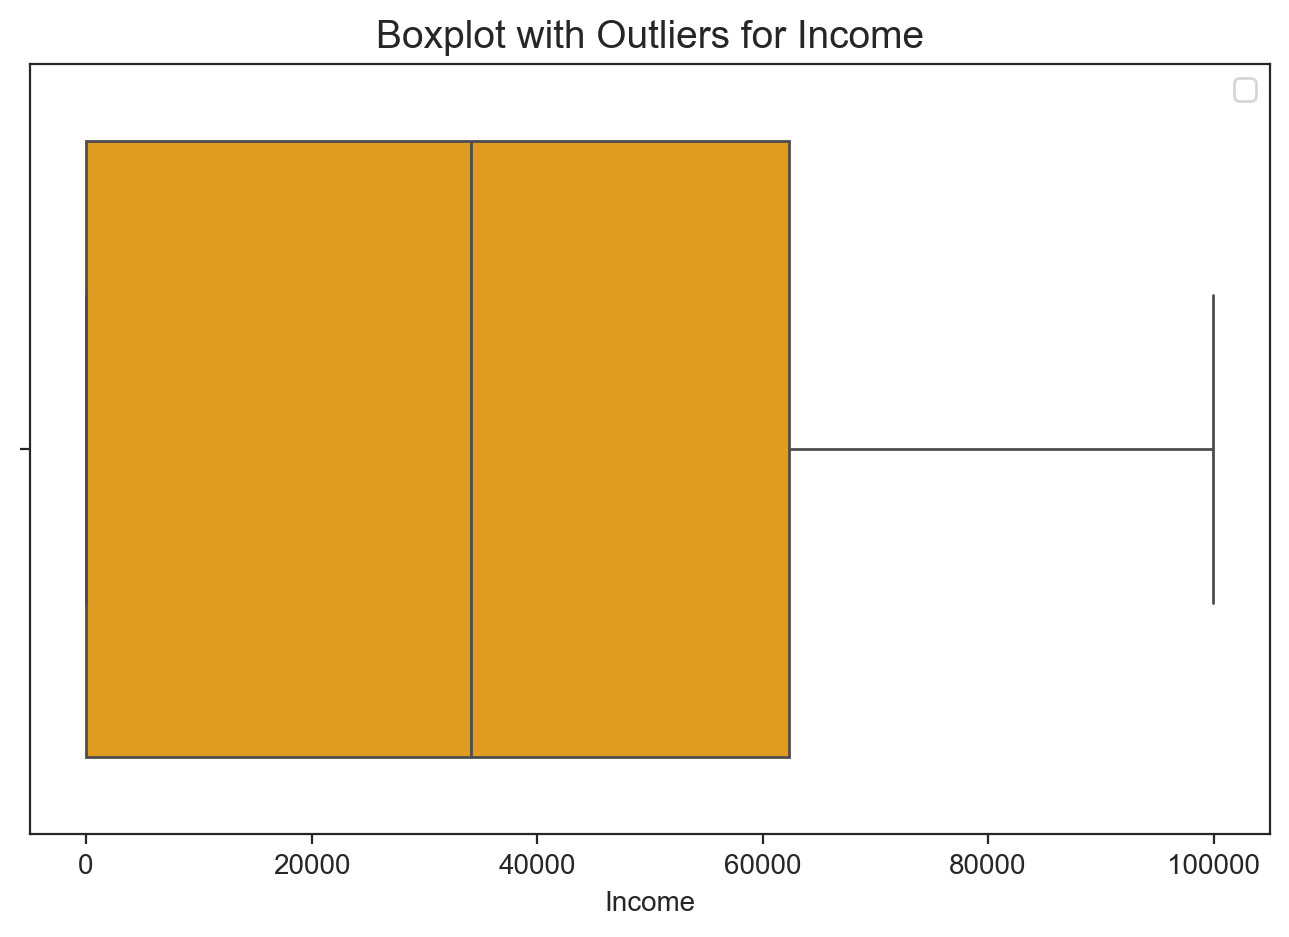

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


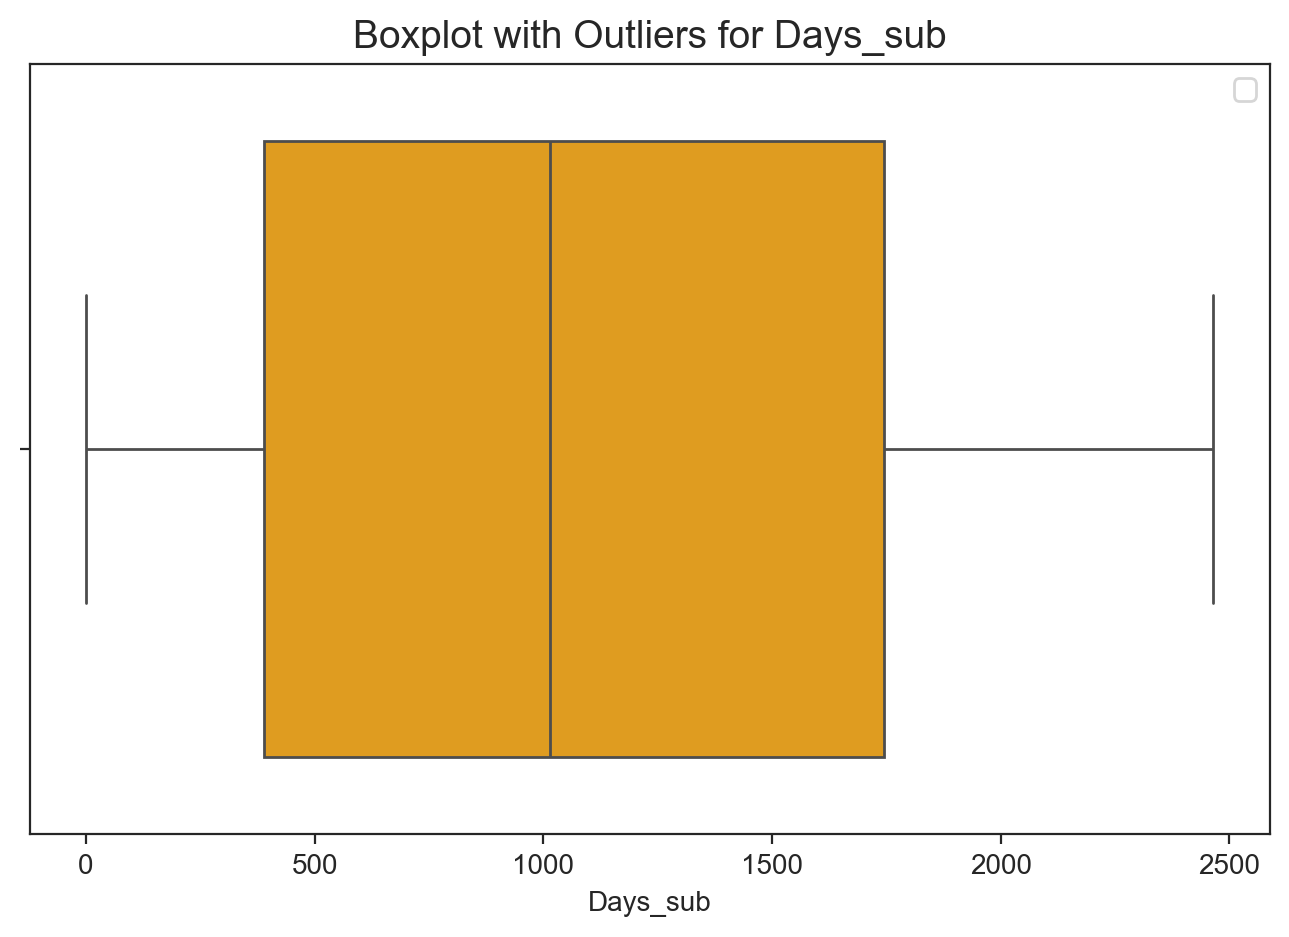

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.798361


In [49]:
detect_outliers_iqr(df_c[df_c_metric], 0.001)

We only observe missing values for **Customer Lifetime Value**

In [50]:
df_c.loc[df_c['Customer Lifetime Value']>50000]

,Loyalty#,Province or State,City,Gender,Education,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
4149,364710,Quebec,Tremblant,female,Bachelor,25167,Married,Aurora,51016.07,2021 Promotion,270
4150,566374,New Brunswick,Moncton,female,Bachelor,25167,Married,Aurora,51016.07,Standard,902
4151,333051,New Brunswick,Moncton,male,Bachelor,84650,Married,Aurora,51426.25,2021 Promotion,244
4152,642323,Ontario,Toronto,male,College,0,Married,Aurora,52811.49,Standard,372
4153,798869,New Brunswick,Fredericton,male,Bachelor,40740,Single,Aurora,55277.45,Standard,68
4154,977244,Quebec,Montreal,female,Bachelor,77237,Married,Aurora,56675.94,Standard,1366
4155,801738,Saskatchewan,Regina,female,Bachelor,48367,Married,Aurora,57520.50,2021 Promotion,331
4156,219139,Alberta,Banff,female,Bachelor,61321,Single,Aurora,58166.55,Standard,1025
4157,228030,British Columbia,Vancouver,male,Bachelor,24964,Married,Aurora,58753.88,Standard,851
4158,592992,Ontario,Trenton,male,College,0,Married,Aurora,61850.19,Standard,2000


***

<h1>df_f

In [51]:
df_f.columns

Index(['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'AvgFlightDistance_month'],
      dtype='object')

In [52]:
df_f_out = ['NumFlights','NumFlightsWithCompanions','DistanceKM','PointsRedeemed', 'AvgFlightDistance_month']

Column: NumFlights - Number of Outliers: 519
Column: NumFlights - % of Outliers: 0.09%



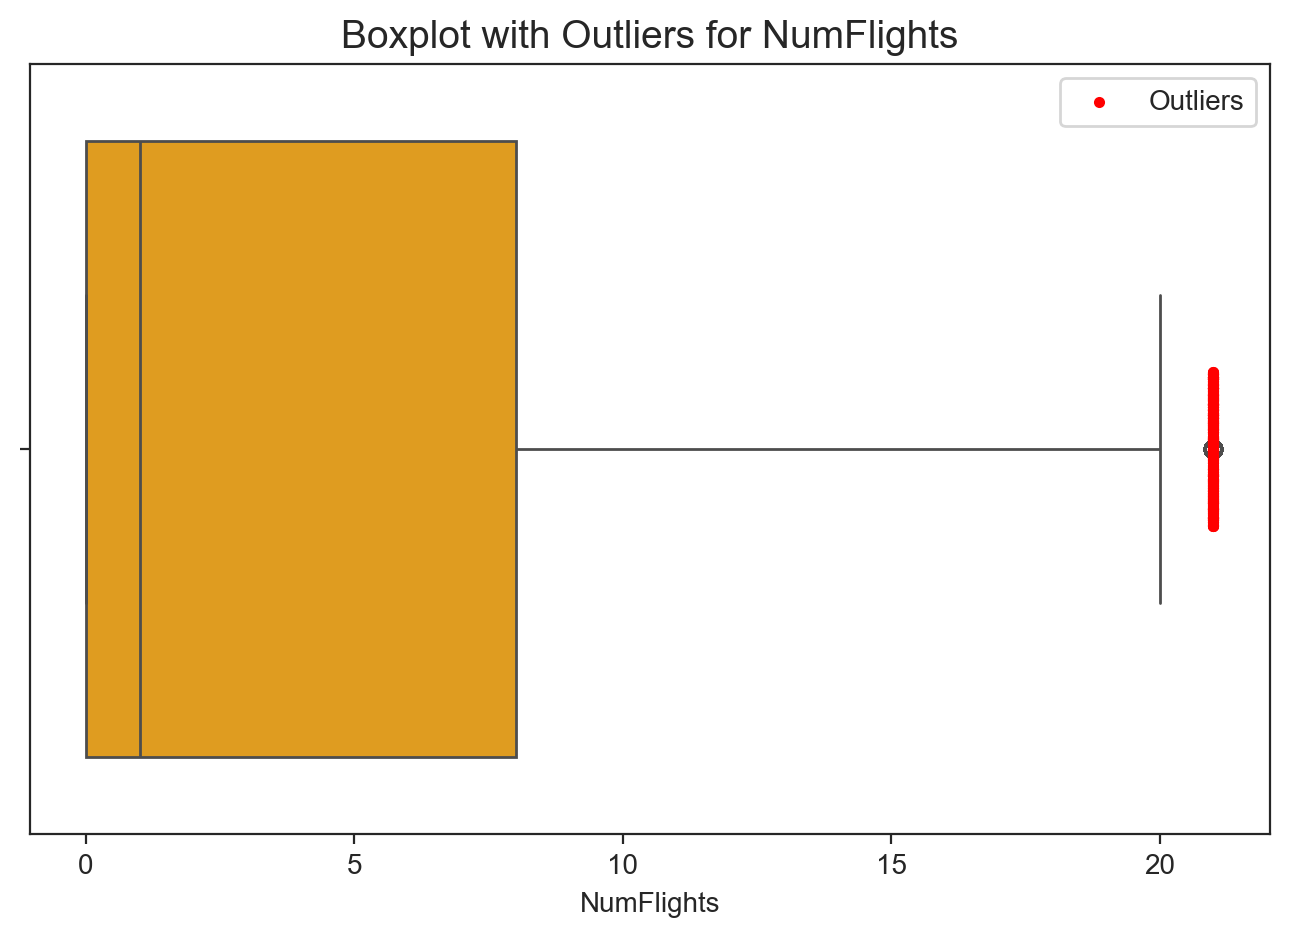

Column: NumFlightsWithCompanions - Number of Outliers: 95880
Column: NumFlightsWithCompanions - % of Outliers: 16.07%



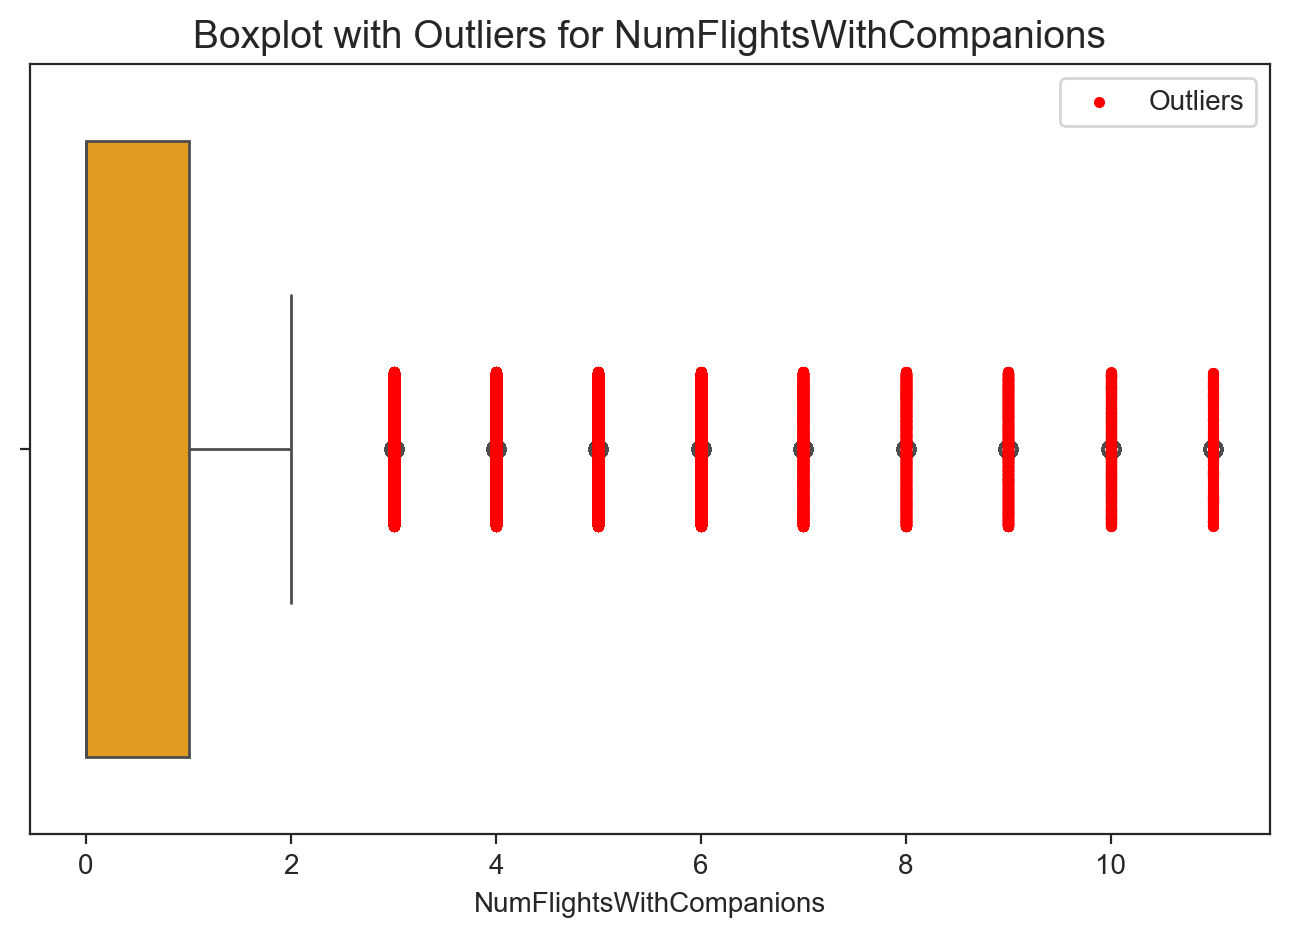

Column: DistanceKM - Number of Outliers: 1828
Column: DistanceKM - % of Outliers: 0.31%



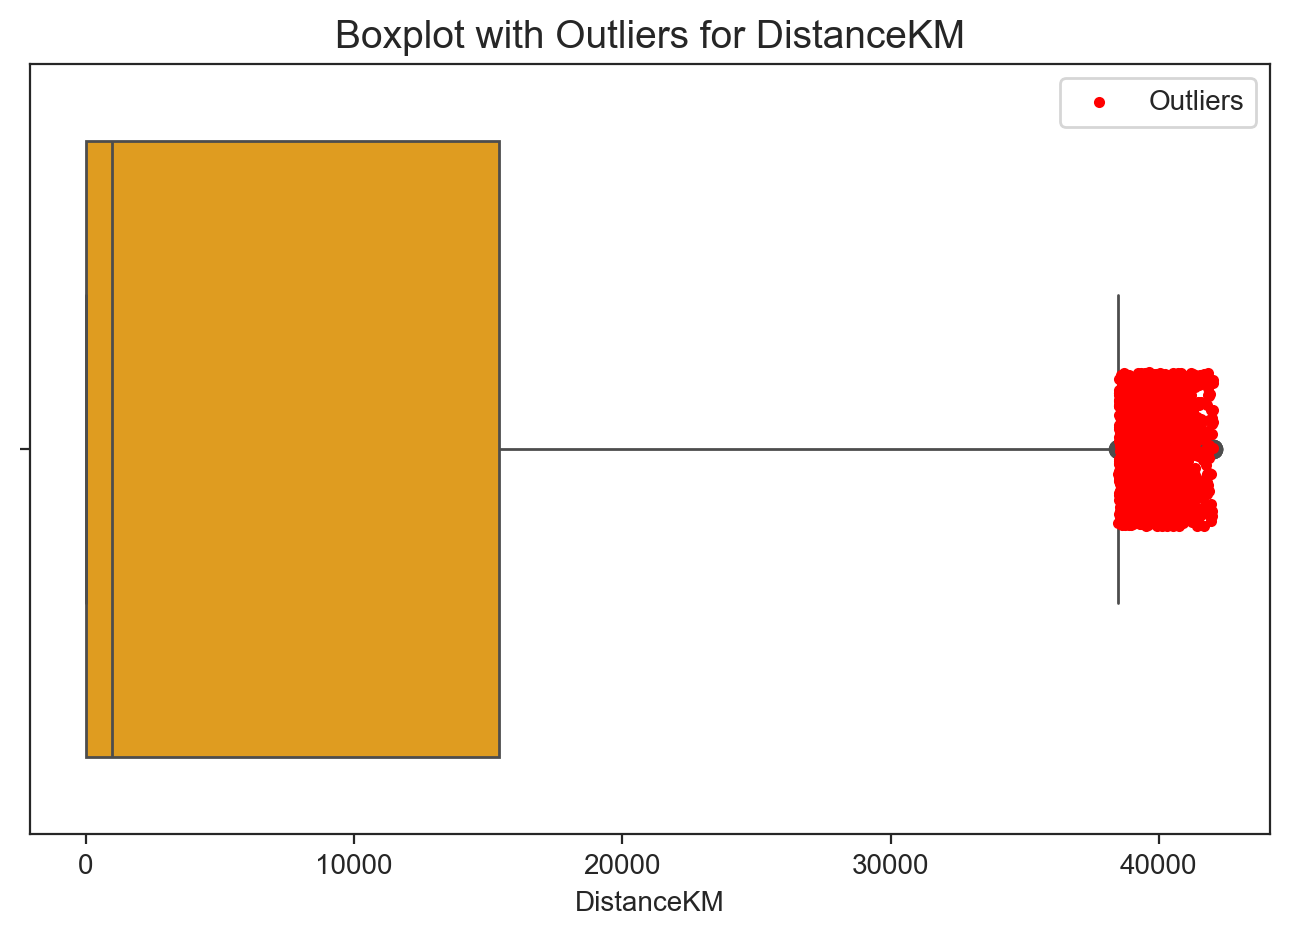

Column: PointsRedeemed - Number of Outliers: 34884
Column: PointsRedeemed - % of Outliers: 5.85%



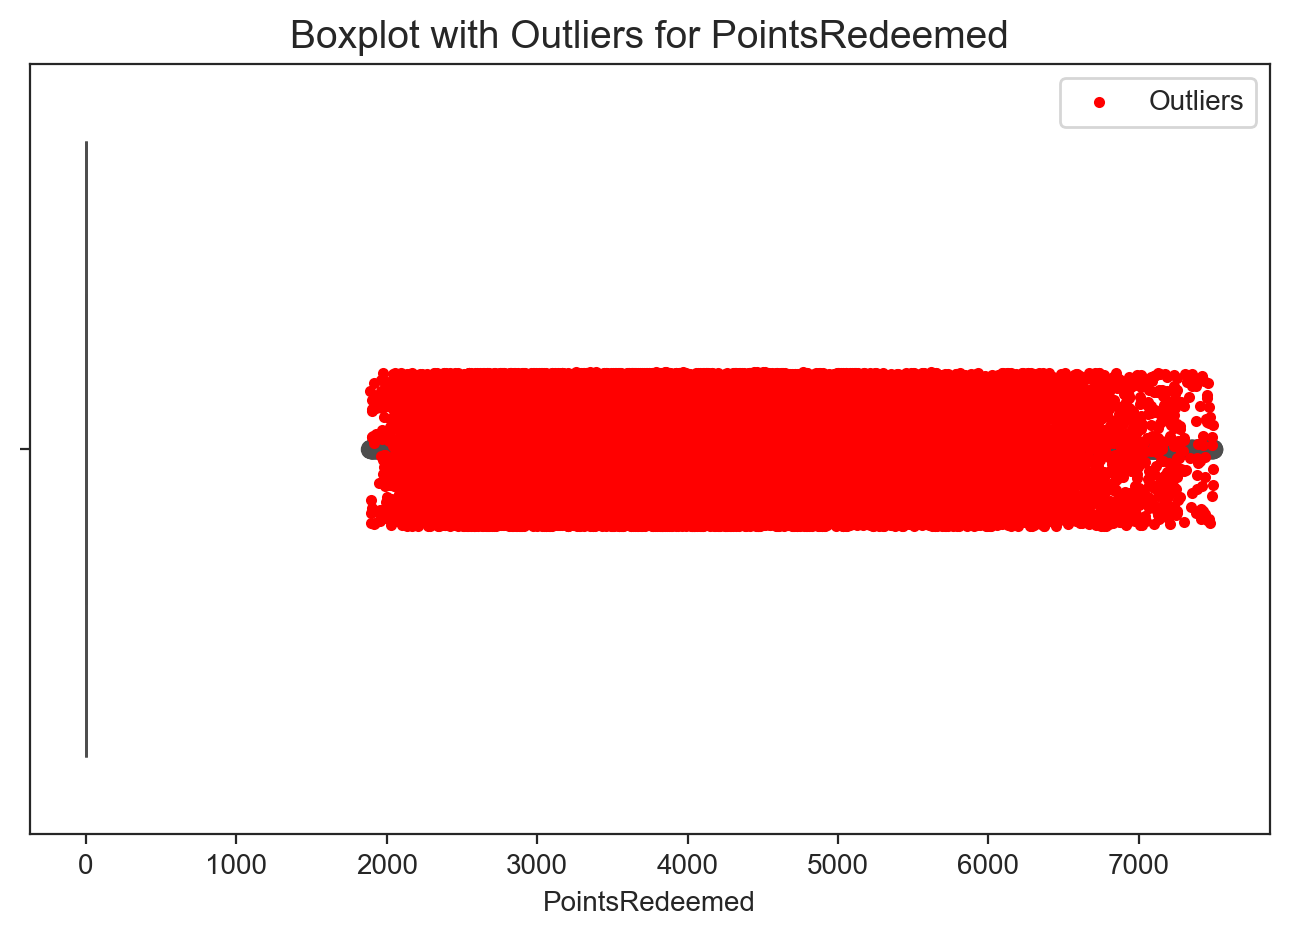

Column: AvgFlightDistance_month - Number of Outliers: 52947
Column: AvgFlightDistance_month - % of Outliers: 8.87%



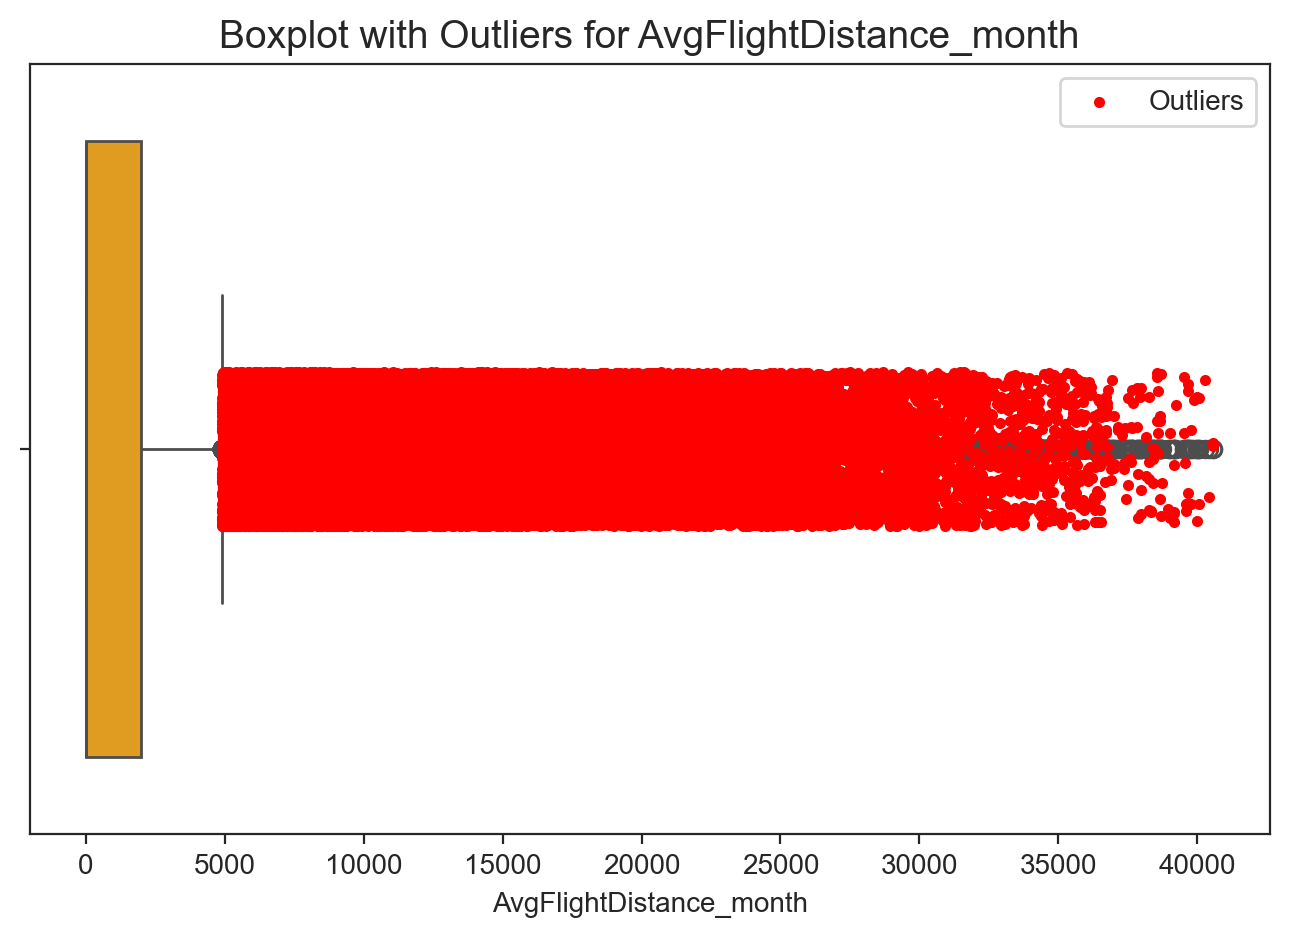

,Column,Num_Outliers,Pct_Outliers
0,NumFlightsWithCompanions,95880,16.069346
1,DistanceKM,1828,0.306370
2,PointsRedeemed,34884,5.846507
3,AvgFlightDistance_month,52947,8.873839


In [53]:
detect_outliers_iqr(df_f[df_f_out], 0.001)

<h2>NumFlightsWithCompanions

In [54]:
df_f[df_f['NumFlightsWithCompanions'] == 5].shape

(18343, 10)

In [55]:
df_f[df_f['NumFlightsWithCompanions'] == 10].shape

(1051, 10)

Lower NumFlightsWithCompanions values have more observations, as expected.

<h2>AvgFlightDistance_month

AvgFlightDistance_month measures the average distance traveled per flight by a customer in a single month. The longest flight in 2025 is New York (JFK) – Singapore (SIN) with 15,349 km (9,537 mi) of Flight Distance (https://airinsight.com/top-10-longest-flights-in-2025/). This means that AvgFlightDistance_month values above 15.349 KM are unrealistic and probably an identation error of NumFlights or DistanceKM.

In [56]:
df_f[df_f['AvgFlightDistance_month']>15349].sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
104388,460058,2021,11,1.0,1,21580.0,2158.00,4223.0,42.0,21580.0
389319,988307,2020,7,2.0,2,35858.0,3585.00,0.0,0.0,17929.0
181968,769346,2021,9,1.0,1,24792.0,2479.00,0.0,0.0,24792.0
138663,633458,2021,5,1.0,0,20304.0,2030.00,0.0,0.0,20304.0
556465,932745,2019,9,1.0,1,23536.8,2353.68,0.0,0.0,23536.8
564059,437810,2019,10,1.0,0,21738.6,2173.86,0.0,0.0,21738.6
6000,991210,2020,6,1.0,1,40055.0,4005.00,5252.0,52.0,40055.0
468331,737949,2019,4,1.0,0,24816.6,2481.66,0.0,0.0,24816.6
216642,775176,2021,6,1.0,0,21461.0,2146.00,0.0,0.0,21461.0
118750,663521,2021,6,1.0,0,30757.0,3075.00,0.0,0.0,30757.0


All of these flights have 1-2 Number of flights in that month (NumFlights) and DistanceKM is in sinc with PointAccumulated. It looks like an identation error from NumFlights variable. Therefore we will set those as missing values to impute them later.

In [57]:
#set NumFlights where AvgFlightDistance_month is >15349 to NaN
df_f.loc[df_f['AvgFlightDistance_month']>15349, 'NumFlights'] = np.nan

## Imputing NumFlights missing values

Before aggregating the flights dataset by customer and merging customers and flight dataset, we will impute the Numflights missing values with a KNN imputer

In [58]:
df_f.isna().sum()

Loyalty#                        0
Year                            0
Month                           0
NumFlights                  21530
NumFlightsWithCompanions        0
DistanceKM                      0
PointsAccumulated               0
PointsRedeemed                  0
DollarCostPointsRedeemed        0
AvgFlightDistance_month         0
dtype: int64

In [59]:
# Valid mask to aggregate observations for imputation
mask_valid = (df_f["NumFlights"].notna() & df_f["DistanceKM"].notna() & (df_f["NumFlights"] > 0)
)
# Where we want to impute
mask_missing = df_f["NumFlights"].isna()

# Just for sanity check - in the end we check if the imputation made sense
df_f["NumFlights_imputed"] = False
df_f.loc[mask_missing, "NumFlights_imputed"] = True

# Adjust model
X = df_f.loc[mask_valid, ["DistanceKM"]]
y = df_f.loc[mask_valid, "NumFlights"]

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

# Imputation
df_f.loc[mask_missing, "NumFlights"] = (
    pd.Series(model.predict(df_f.loc[mask_missing, ["DistanceKM"]]), index=df_f.loc[mask_missing].index)
    .round()
    .clip(lower=0)
)

df_f.loc[df_f["NumFlights_imputed"]].sample(20)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month,NumFlights_imputed
250126,556313,2021,3,7.0,0,16447.0,1644.00,0.0,0.0,16447.0,True
563576,413266,2019,10,2.0,0,5147.1,514.71,0.0,0.0,0.0,True
558568,144523,2019,10,10.0,1,24591.6,2459.16,0.0,0.0,24591.6,True
539651,937911,2019,8,4.0,0,10464.3,1046.43,0.0,0.0,0.0,True
325762,966117,2020,11,7.0,1,17842.0,1784.00,0.0,0.0,17842.0,True
80177,309364,2020,1,8.0,0,20547.0,2054.00,0.0,0.0,20547.0,True
181169,775176,2021,9,11.0,0,28023.0,2802.00,0.0,0.0,0.0,True
505270,905854,2019,6,8.0,0,20876.4,2087.64,0.0,0.0,0.0,True
22088,878653,2020,4,10.0,0,25909.0,2590.00,0.0,0.0,25909.0,True
545530,351145,2019,9,0.0,0,1138.5,113.85,0.0,0.0,0.0,True


In [60]:
df_f = df_f.drop(columns=['AvgFlightDistance_month'])

df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

In [61]:
df_f[df_f['AvgFlightDistance_month']>15349]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,NumFlights_imputed,AvgFlightDistance_month


## Aggregate Flights dataset by customer

In [62]:
# Aggregate by client - Loyalty 
df_f_agg = (df_f.groupby("Loyalty#").agg(
    {"Year": ["nunique"],                     
    "Month": ["nunique"],                    
    "NumFlights": ["sum", "mean", "max"],    
    "NumFlightsWithCompanions": ["sum", "mean"],  
    "DistanceKM": ["sum", "mean", "max"],    
    "PointsAccumulated": ["sum", "mean"],    
    "PointsRedeemed": ["sum", "mean"],       
    "DollarCostPointsRedeemed": ["sum", "mean"]}).reset_index())

# I know there are a lot of variables, but u never know if we will use them. In the end, they can be removed
df_f_agg.columns = ["Loyalty#", "Years_Active", "Months_Active", "Flights_Sum", "Flights_Mean", "Flights_Max",
                          "FlightsComp_Sum", "FlightsComp_Mean", "DistKM_Sum", "DistKM_Mean", "DistKM_Max", "PtsAcc_Sum", "PtsAcc_Mean",
                          "PtsRed_Sum", "PtsRed_Mean", "CostPts_Sum", "CostPts_Mean"]

# Feature Engineering (some variables created that could be important)
# Ratio between Points Redeemed and Points Accumulated over the time
df_f_agg["PointsEfficiency"] = (
    df_f_agg["PtsRed_Sum"] / df_f_agg["PtsAcc_Sum"]
).replace([np.inf, np.nan], 0)

# Distance
df_f_agg["DistPerFlight"] = (
    df_f_agg["DistKM_Sum"] / df_f_agg["Flights_Sum"]
).replace([np.inf, np.nan], 0)


In [63]:
df_f_agg.sample(10)

,Loyalty#,Years_Active,Months_Active,Flights_Sum,Flights_Mean,Flights_Max,FlightsComp_Sum,FlightsComp_Mean,DistKM_Sum,DistKM_Mean,DistKM_Max,PtsAcc_Sum,PtsAcc_Mean,PtsRed_Sum,PtsRed_Mean,CostPts_Sum,CostPts_Mean,PointsEfficiency,DistPerFlight
10035,643362,3,12,113.0,3.138889,13.0,9,0.250000,247009.5,6861.375000,34017.0,24697.45,686.040278,0.0,0.000000,0.0,0.000000,0.000000,2185.924779
12098,753977,3,12,95.0,2.638889,13.0,32,0.888889,227542.1,6320.613889,32249.0,22750.31,631.953056,6321.3,175.591667,62.7,1.741667,0.277856,2395.180000
3931,314189,3,12,10.0,0.277778,7.0,9,0.250000,61247.0,1701.305556,31841.0,6124.00,170.111111,5935.0,164.861111,59.0,1.638889,0.969138,6124.700000
1525,183626,3,12,148.0,4.111111,16.0,35,0.972222,350147.5,9726.319444,33656.0,35008.25,972.451389,5382.0,149.500000,53.0,1.472222,0.153735,2365.861486
753,140534,3,12,146.0,4.055556,16.0,33,0.916667,376049.7,10445.825000,30764.0,37598.57,1044.404722,5802.0,161.166667,58.0,1.611111,0.154314,2575.682877
14579,890404,3,12,43.0,1.194444,11.0,21,0.583333,112337.0,3120.472222,27275.0,11232.00,312.000000,3431.0,95.305556,34.0,0.944444,0.305467,2612.488372
2786,252472,3,12,0.0,0.000000,0.0,0,0.000000,0.0,0.000000,0.0,0.00,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
1593,187141,3,12,51.0,1.416667,12.0,28,0.777778,135410.0,3761.388889,37143.0,13538.00,376.055556,10892.0,302.555556,108.0,3.000000,0.804550,2655.098039
12412,770702,3,12,15.0,0.416667,9.0,11,0.305556,31061.0,862.805556,20159.0,3104.00,86.222222,0.0,0.000000,0.0,0.000000,0.000000,2070.733333
12713,787763,3,12,210.0,5.833333,14.0,31,0.861111,405293.9,11258.163889,31874.0,40520.19,1125.560833,15068.6,418.572222,149.6,4.155556,0.371879,1929.970952


As we can see, for all the customers, the "Years_Active" and "Months_Active" are the same, so we are going to drop both.

In [64]:
df_f_agg = df_f_agg.drop(['Years_Active', 'Months_Active'], axis=1)

## Missing Values

Let's treat the Missing Values before Merging the datasets

In [65]:
df_c.isna().sum()

Loyalty#                    0
Province or State           0
City                        0
Gender                      0
Education                   0
Income                     20
Marital Status              0
LoyaltyStatus               0
Customer Lifetime Value    20
EnrollmentType              0
Days_sub                    0
dtype: int64

In [66]:
#lets the the rows where income is Nan
df_c[df_c['Income'].isna()]

,Loyalty#,Province or State,City,Gender,Education,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
0,999987,New Brunswick,Fredericton,female,Bachelor,<NA>,Single,Star,NaN,Standard,0
1,999988,Quebec,Montreal,male,College,<NA>,Single,Star,NaN,Standard,0
2,999989,Ontario,Trenton,male,College,<NA>,Married,Star,NaN,Standard,0
3,999990,New Brunswick,Moncton,female,College,<NA>,Married,Star,NaN,Standard,0
4,999991,New Brunswick,Fredericton,female,College,<NA>,Married,Star,NaN,Standard,0
5,999992,Ontario,Toronto,male,College,<NA>,Single,Star,NaN,Standard,0
6,999993,British Columbia,Dawson Creek,female,College,<NA>,Married,Star,NaN,Standard,0
7,999994,Ontario,Ottawa,female,College,<NA>,Married,Star,NaN,Standard,0
8,999995,Ontario,Ottawa,female,College,<NA>,Married,Star,NaN,Standard,0
9,999996,Ontario,Toronto,female,Bachelor,<NA>,Single,Star,NaN,Standard,0


The rows where income is Na are the rows where Customer Lifetime Value is also NaN. Lets see these customers on the flights dataset

In [67]:
Nan_customer_ids = df_c[df_c['Income'].isna()]['Loyalty#'].tolist()

df_f[df_f['Loyalty#'].isin(Nan_customer_ids)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,NumFlights_imputed,AvgFlightDistance_month


The customers that have missing values on income and Customer Lifetime Value dont exist in the flights dataset so we will just remove them.

In [68]:
#remove these customers from customer dataset
df_c = df_c[~df_c['Loyalty#'].isin(Nan_customer_ids)].copy()

## Merge both datasets

In [69]:
df_agg_merged = pd.merge(df_c, df_f_agg, on="Loyalty#", how="left")
print("Final dimensions:", df_agg_merged.shape)

Final dimensions: (16574, 27)


In [70]:
df_agg_merged.columns

Index(['Loyalty#', 'Province or State', 'City', 'Gender', 'Education',
       'Income', 'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub', 'Flights_Sum', 'Flights_Mean',
       'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean', 'DistKM_Sum',
       'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum',
       'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean', 'PointsEfficiency',
       'DistPerFlight'],
      dtype='object')

### Check outliers

We had checked outliers for df_c and df_f. But with the new flights dataset aggregated by customer we have created new variables.

In [71]:
df_agg_merged_out = ['Income', 'Customer Lifetime Value',
       'Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight']

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


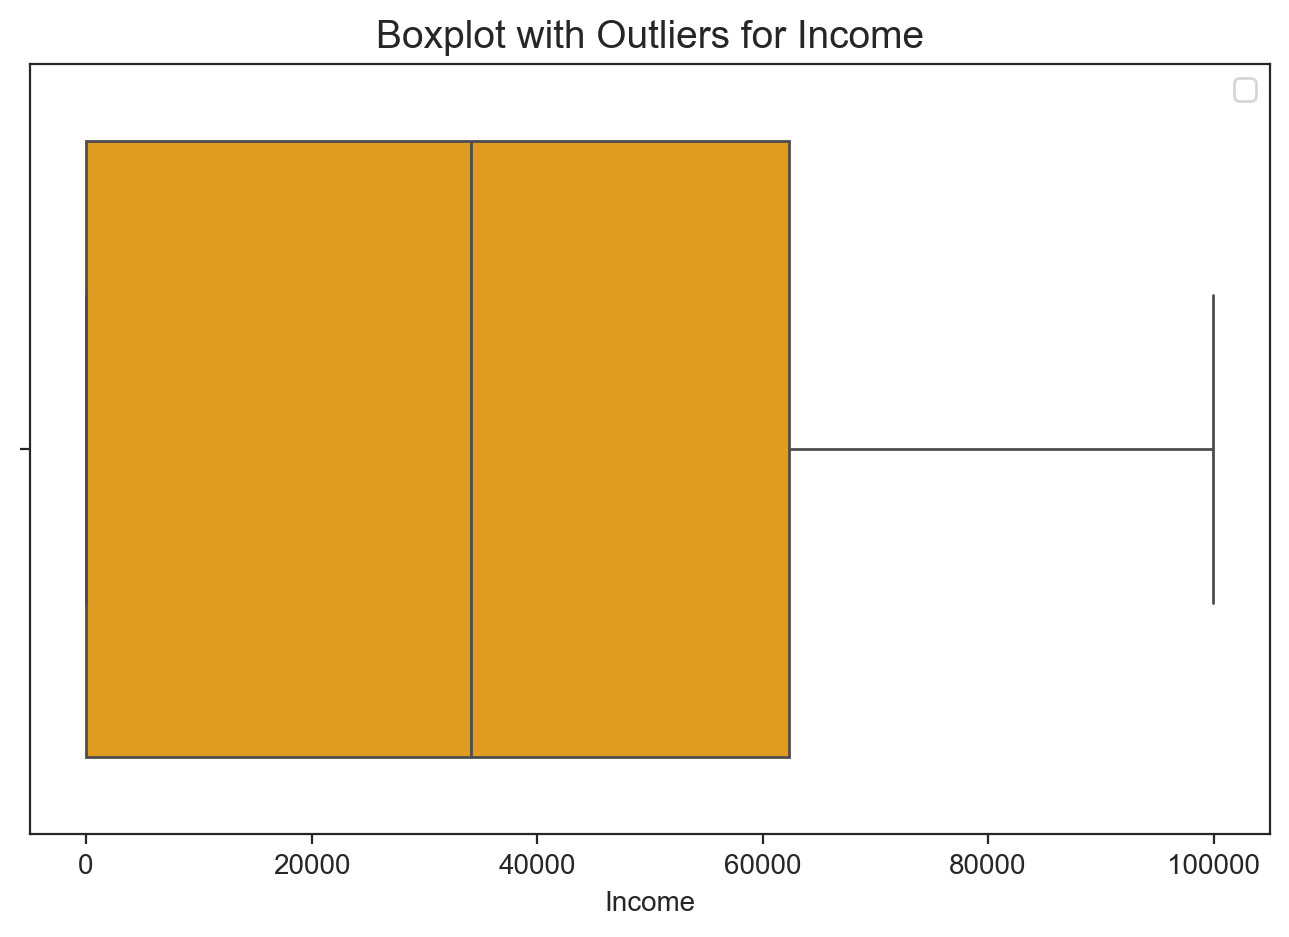

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.81%



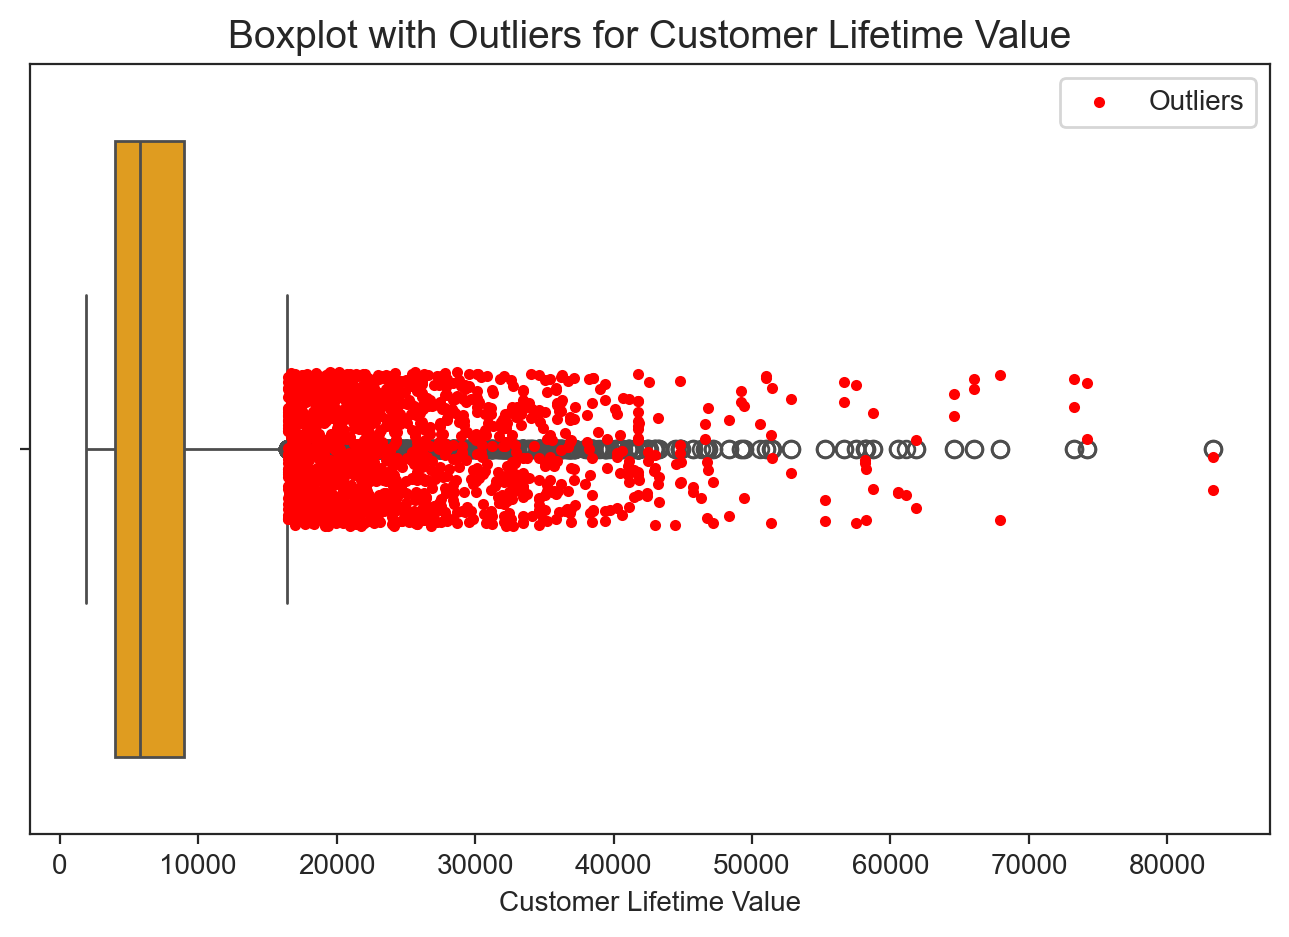

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


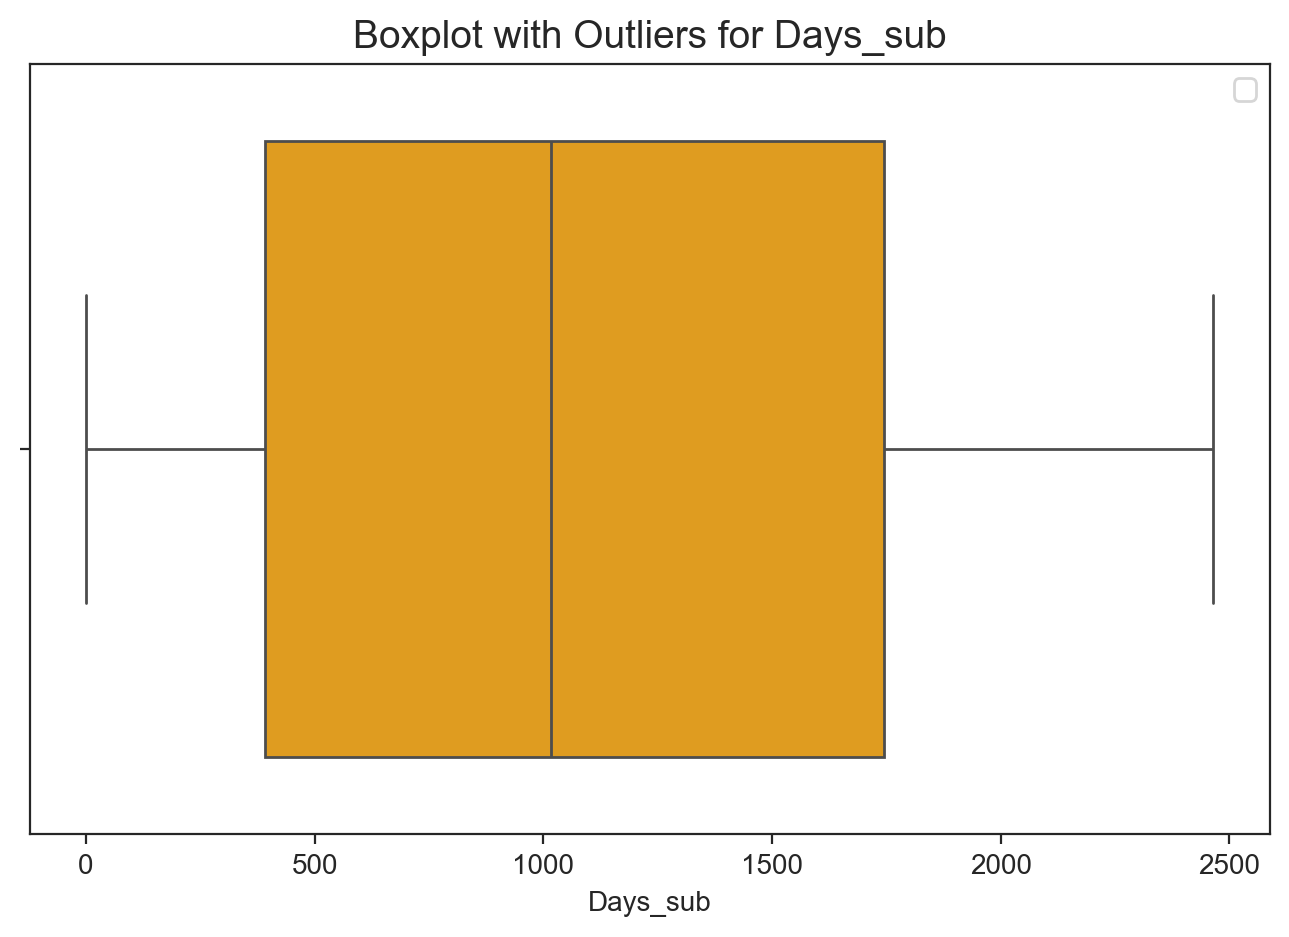

Column: Flights_Sum - Number of Outliers: 0
Column: Flights_Sum - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


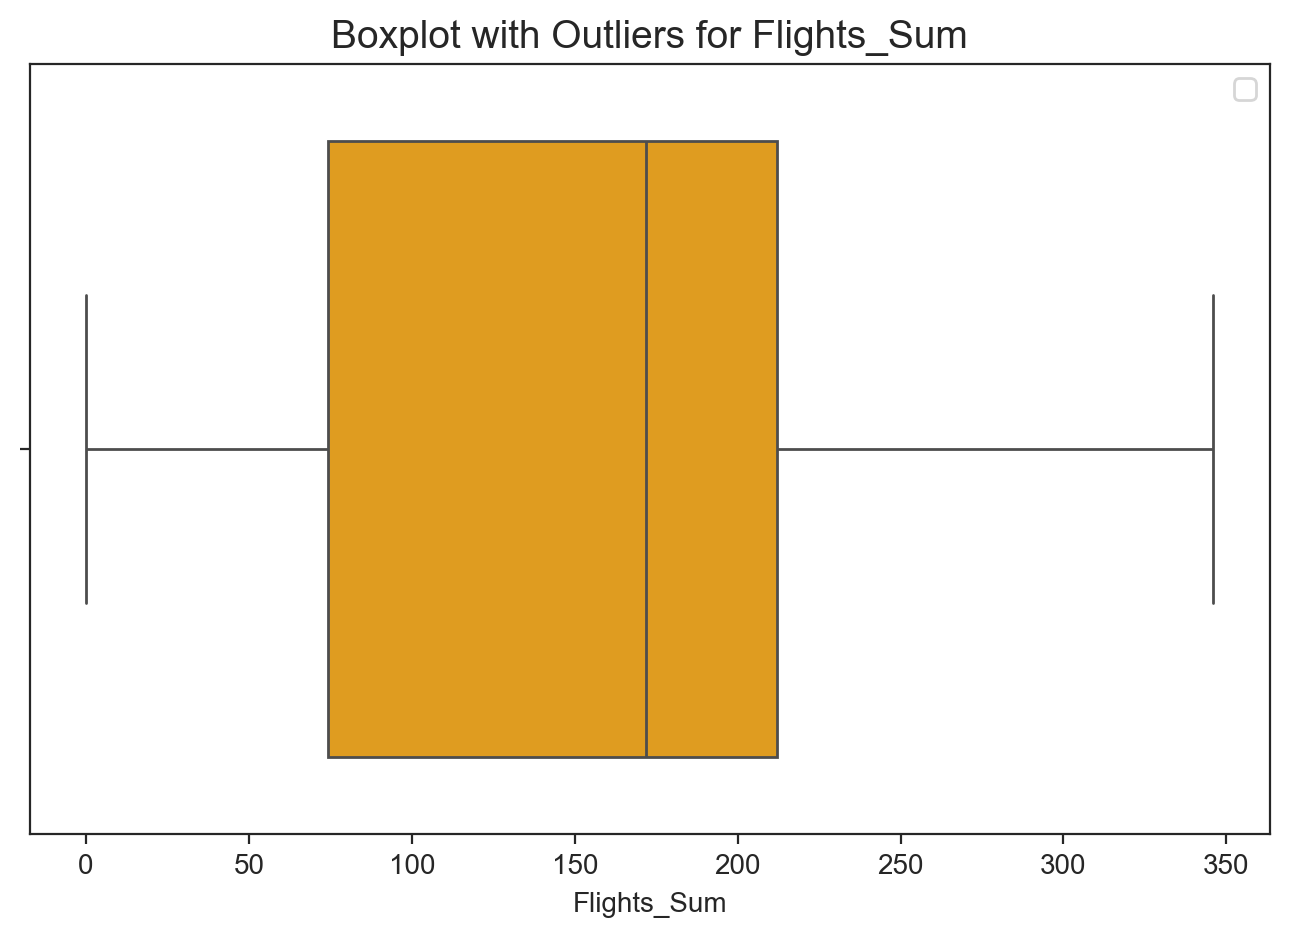

/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Column: Flights_Mean - Number of Outliers: 0
Column: Flights_Mean - % of Outliers: 0.00%



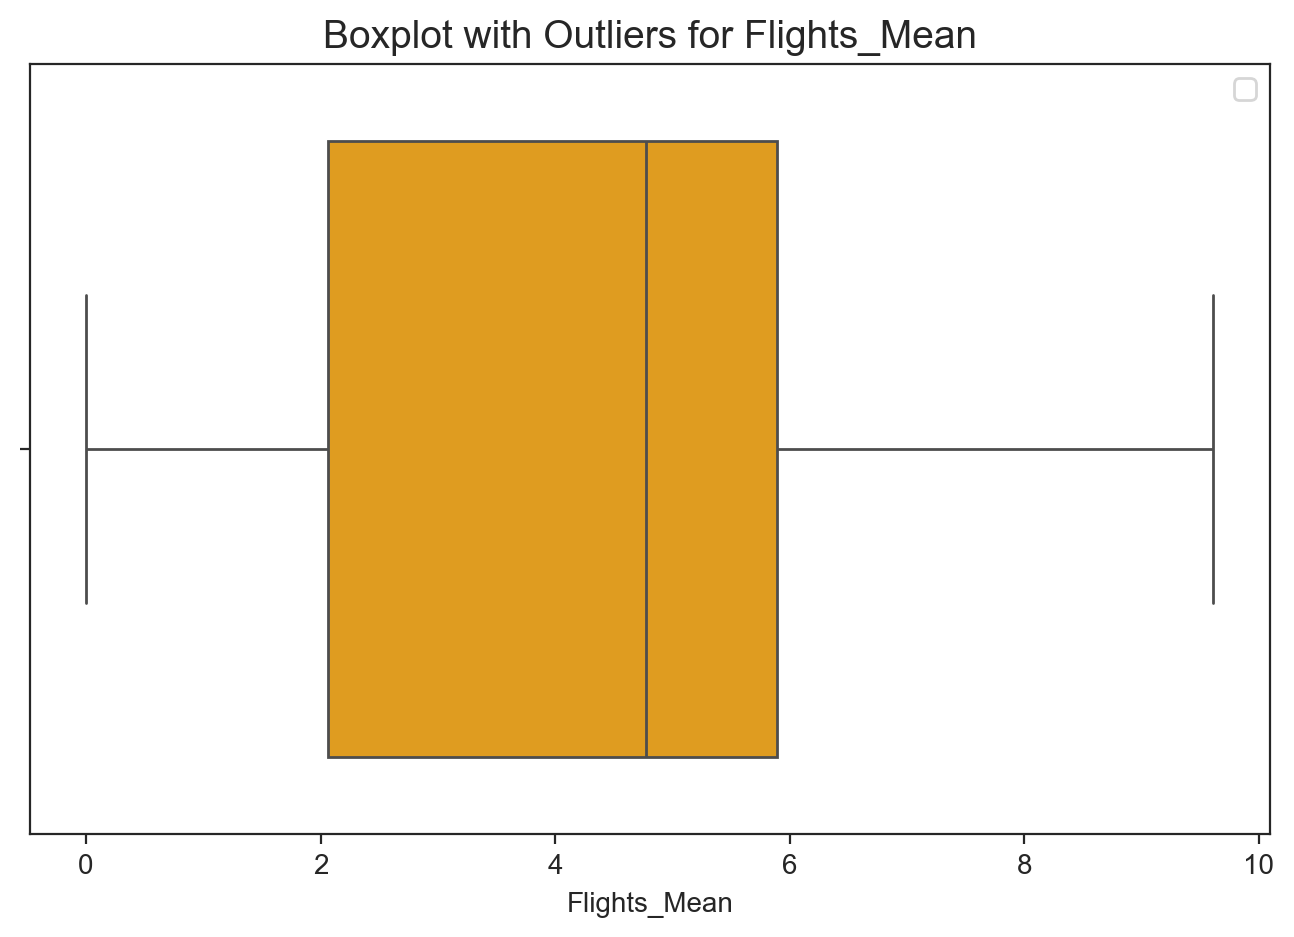

Column: Flights_Max - Number of Outliers: 1630
Column: Flights_Max - % of Outliers: 9.83%



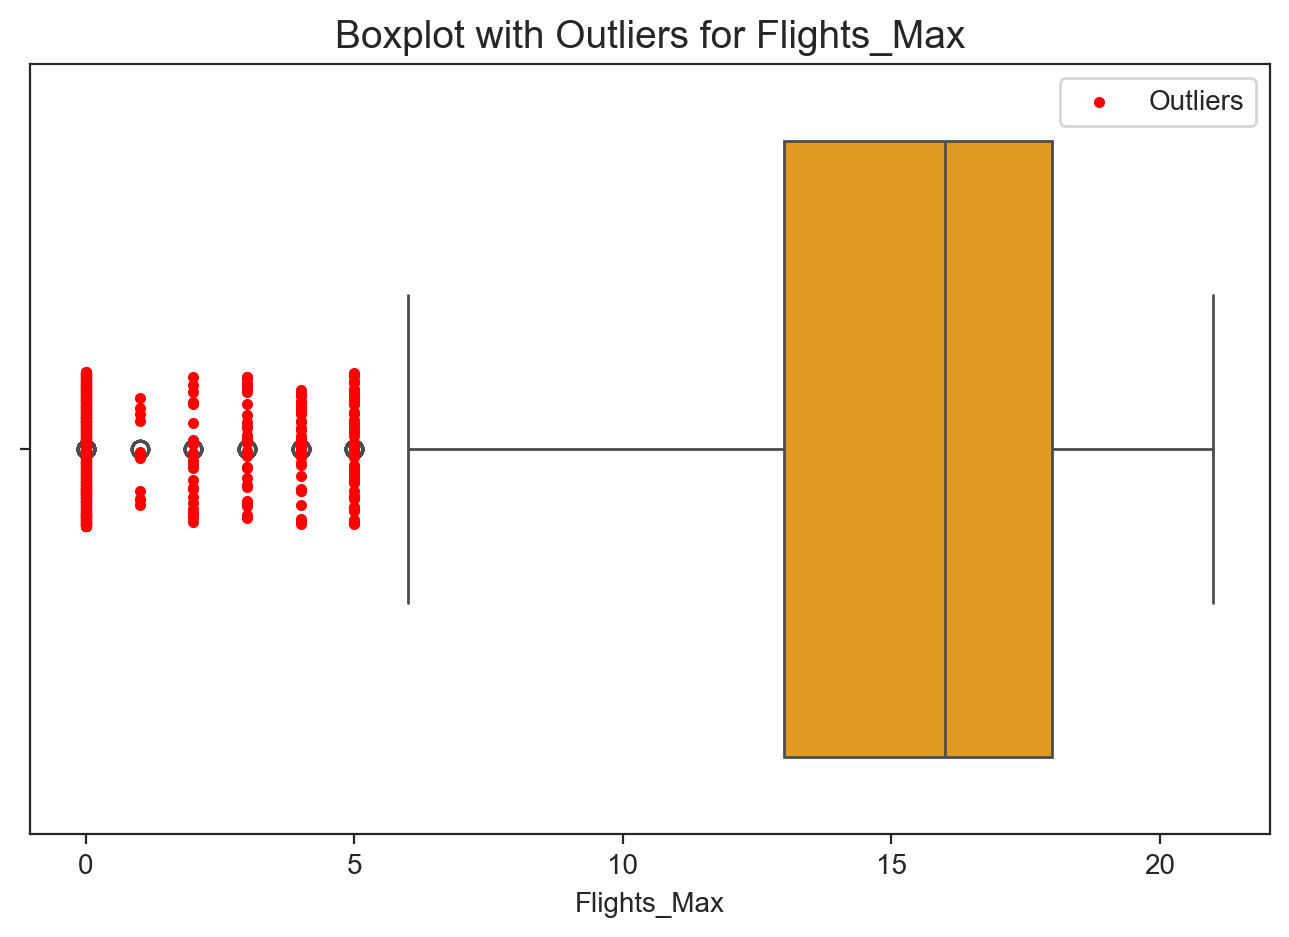

Column: FlightsComp_Sum - Number of Outliers: 18
Column: FlightsComp_Sum - % of Outliers: 0.11%



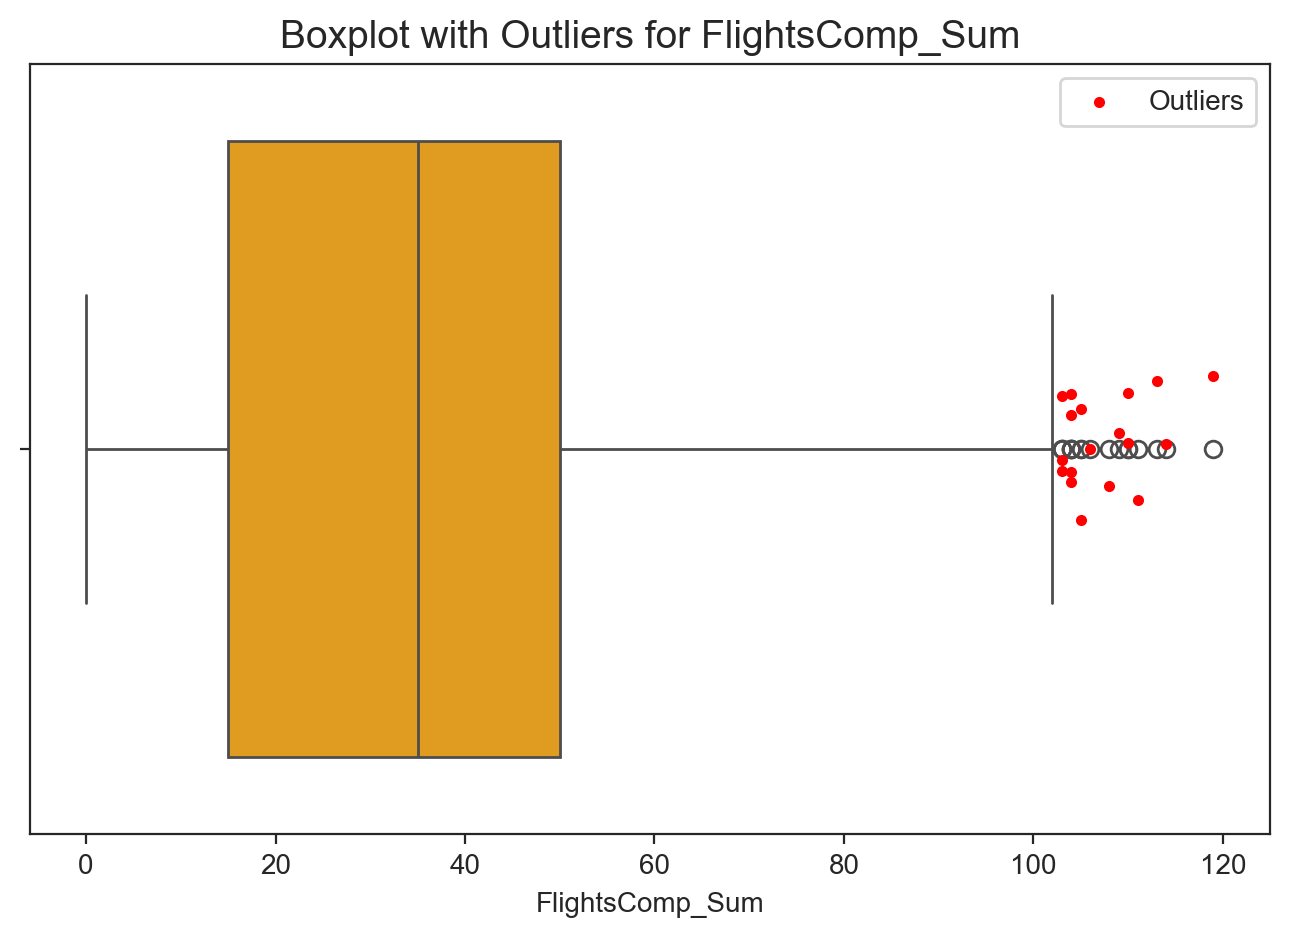

Column: FlightsComp_Mean - Number of Outliers: 18
Column: FlightsComp_Mean - % of Outliers: 0.11%



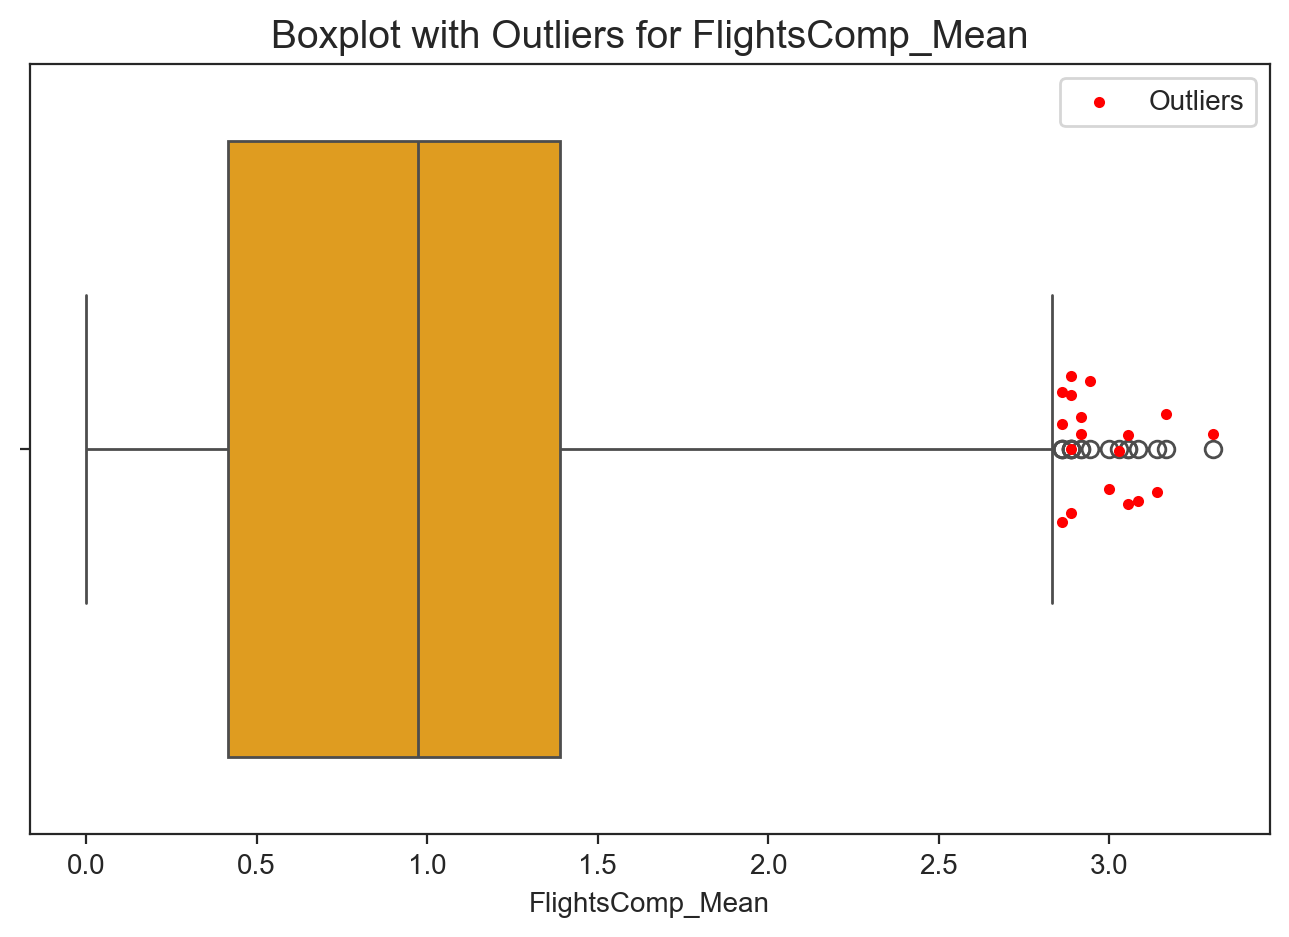

Column: DistKM_Sum - Number of Outliers: 0
Column: DistKM_Sum - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


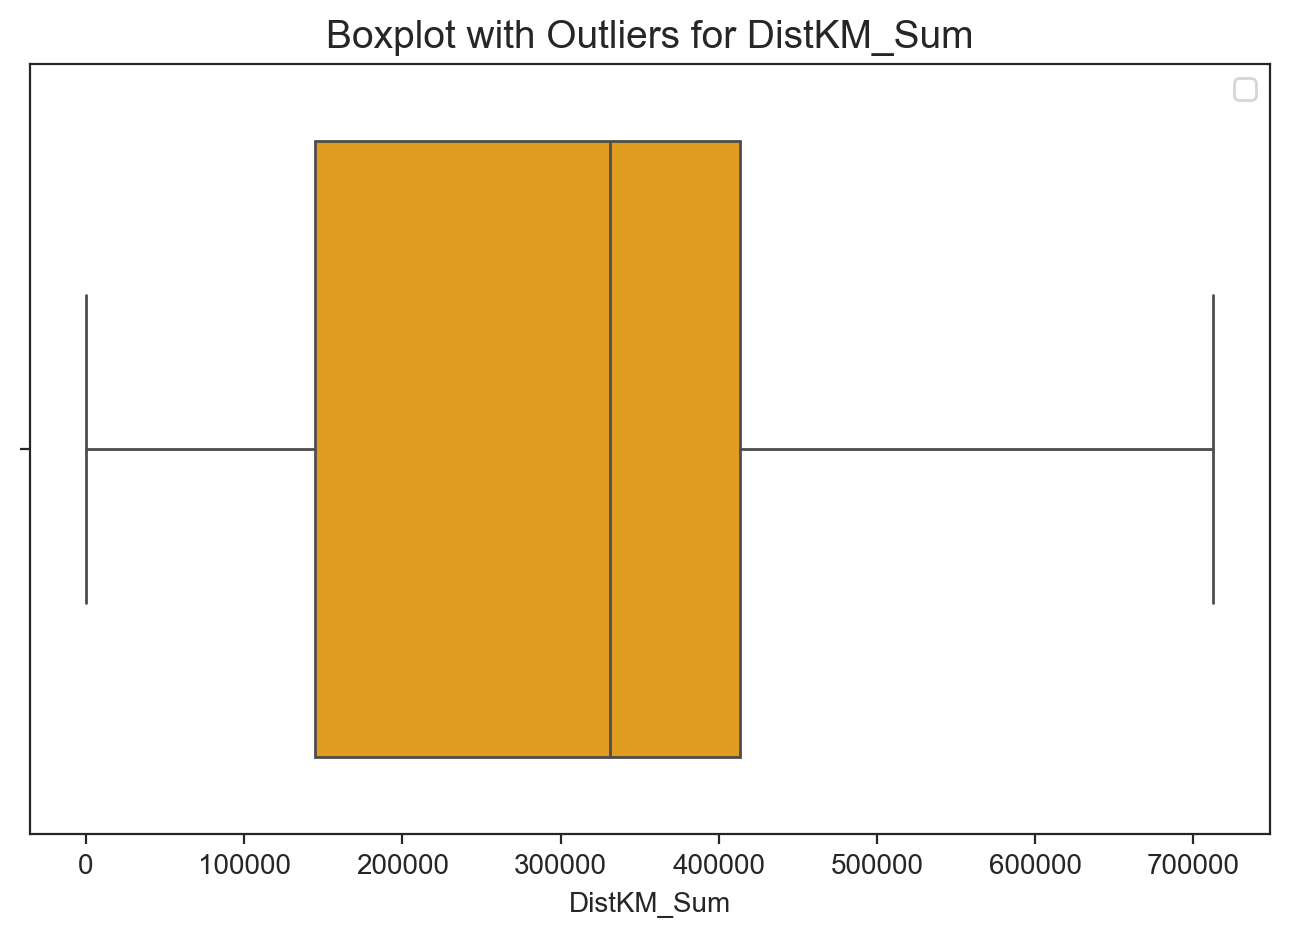

Column: DistKM_Mean - Number of Outliers: 0
Column: DistKM_Mean - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


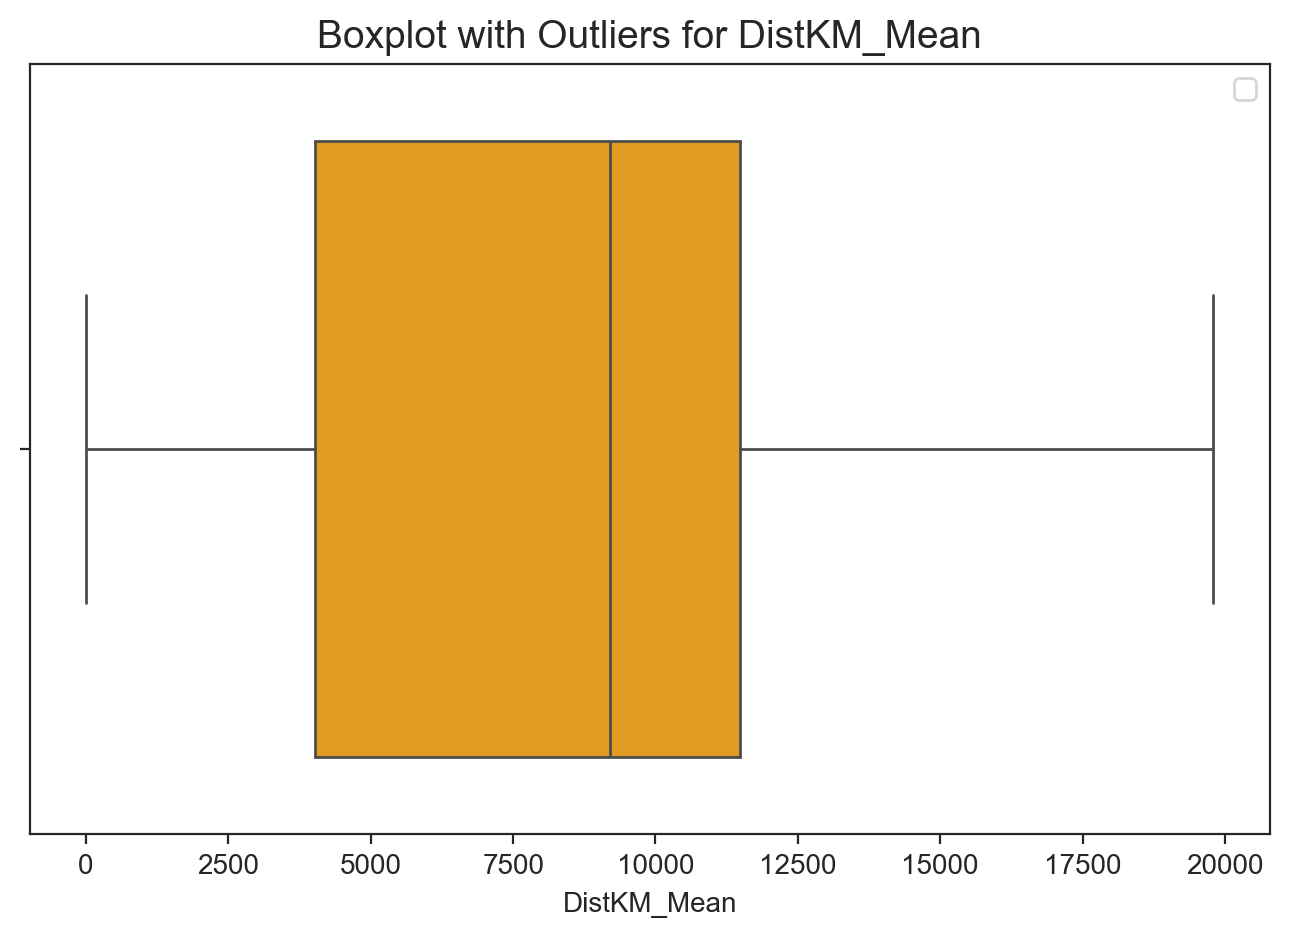

Column: DistKM_Max - Number of Outliers: 1808
Column: DistKM_Max - % of Outliers: 10.91%



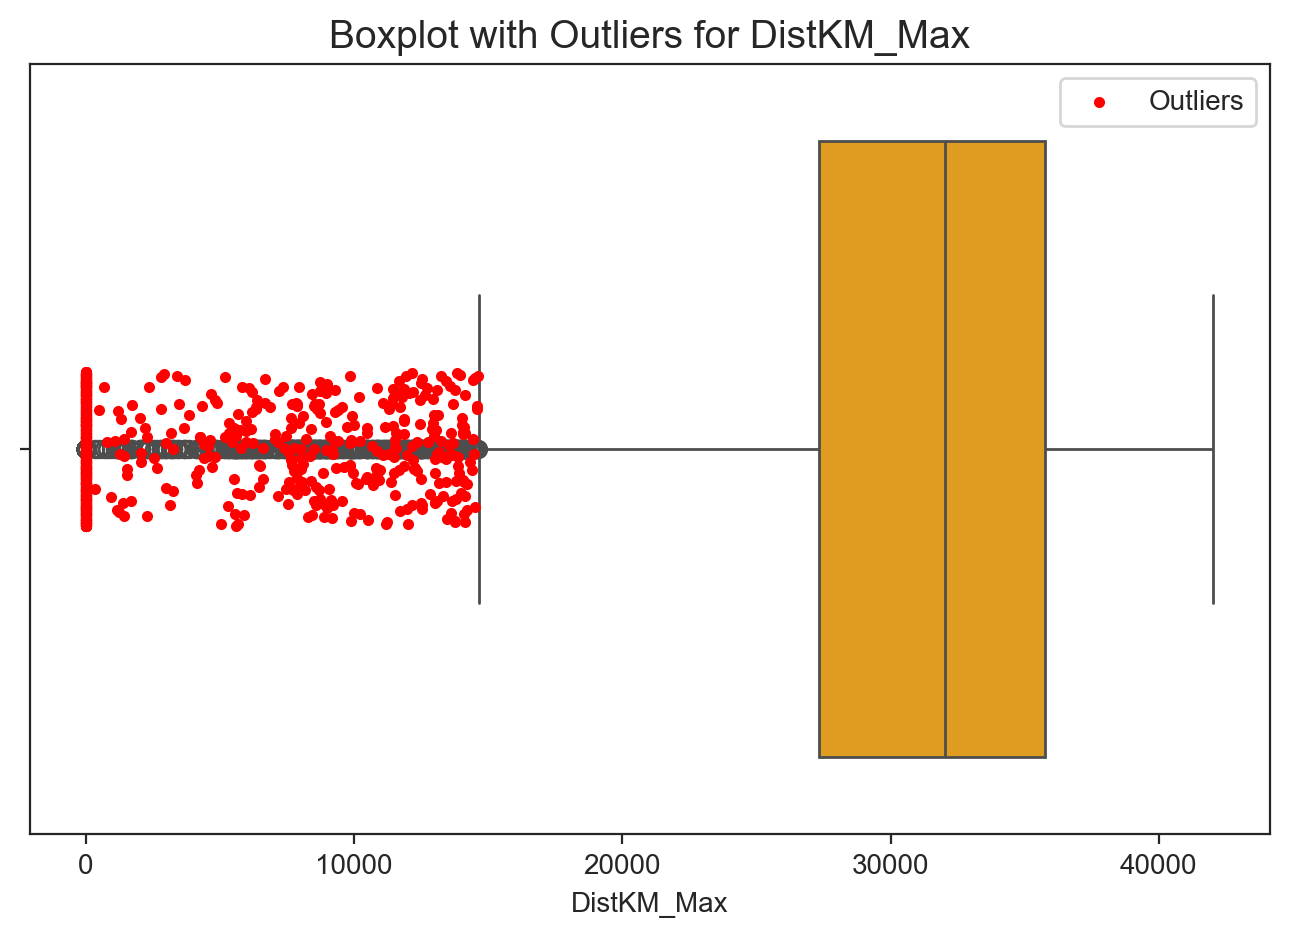

Column: PtsAcc_Sum - Number of Outliers: 0
Column: PtsAcc_Sum - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


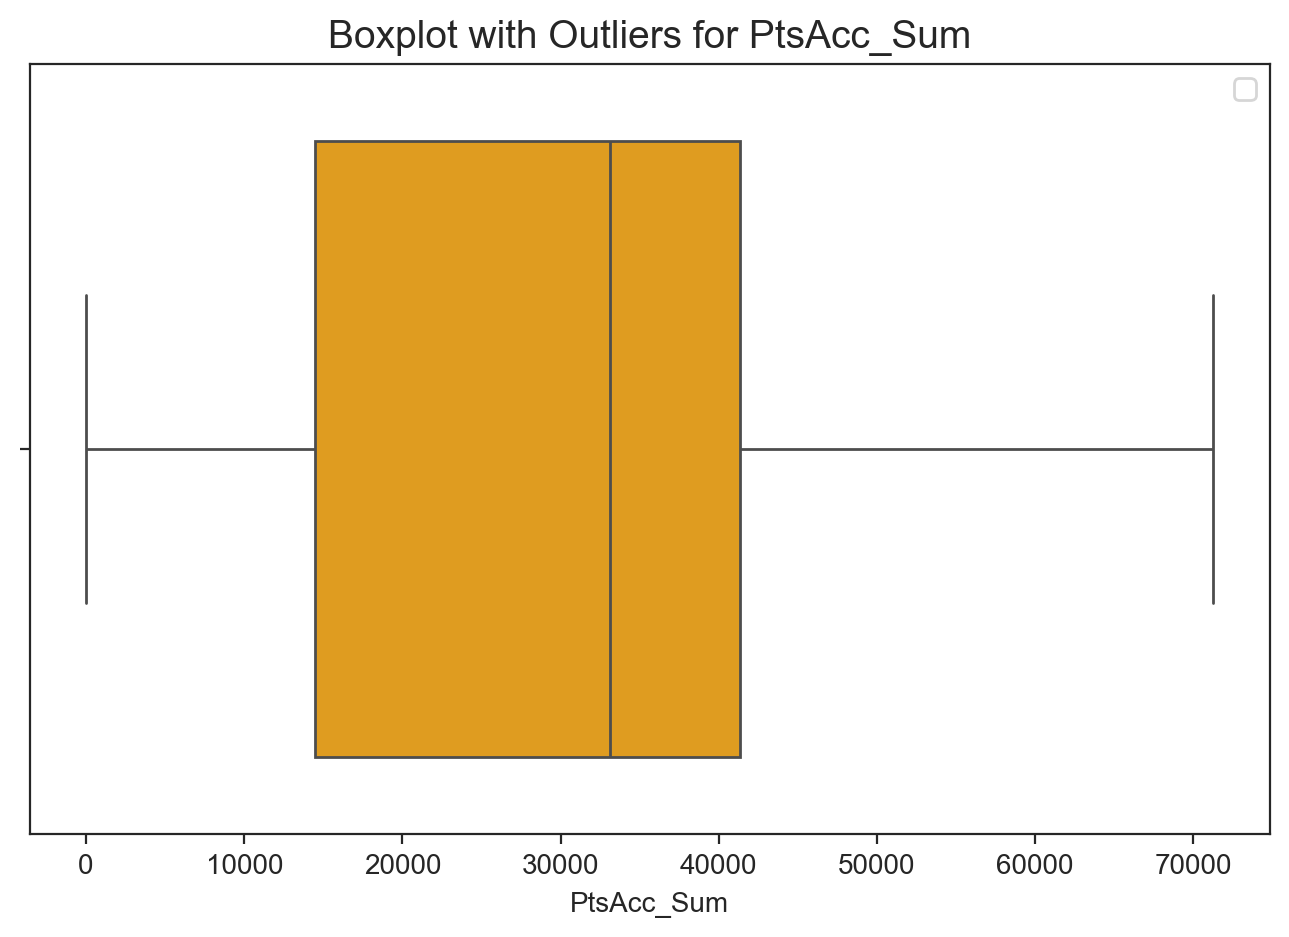

Column: PtsAcc_Mean - Number of Outliers: 0
Column: PtsAcc_Mean - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


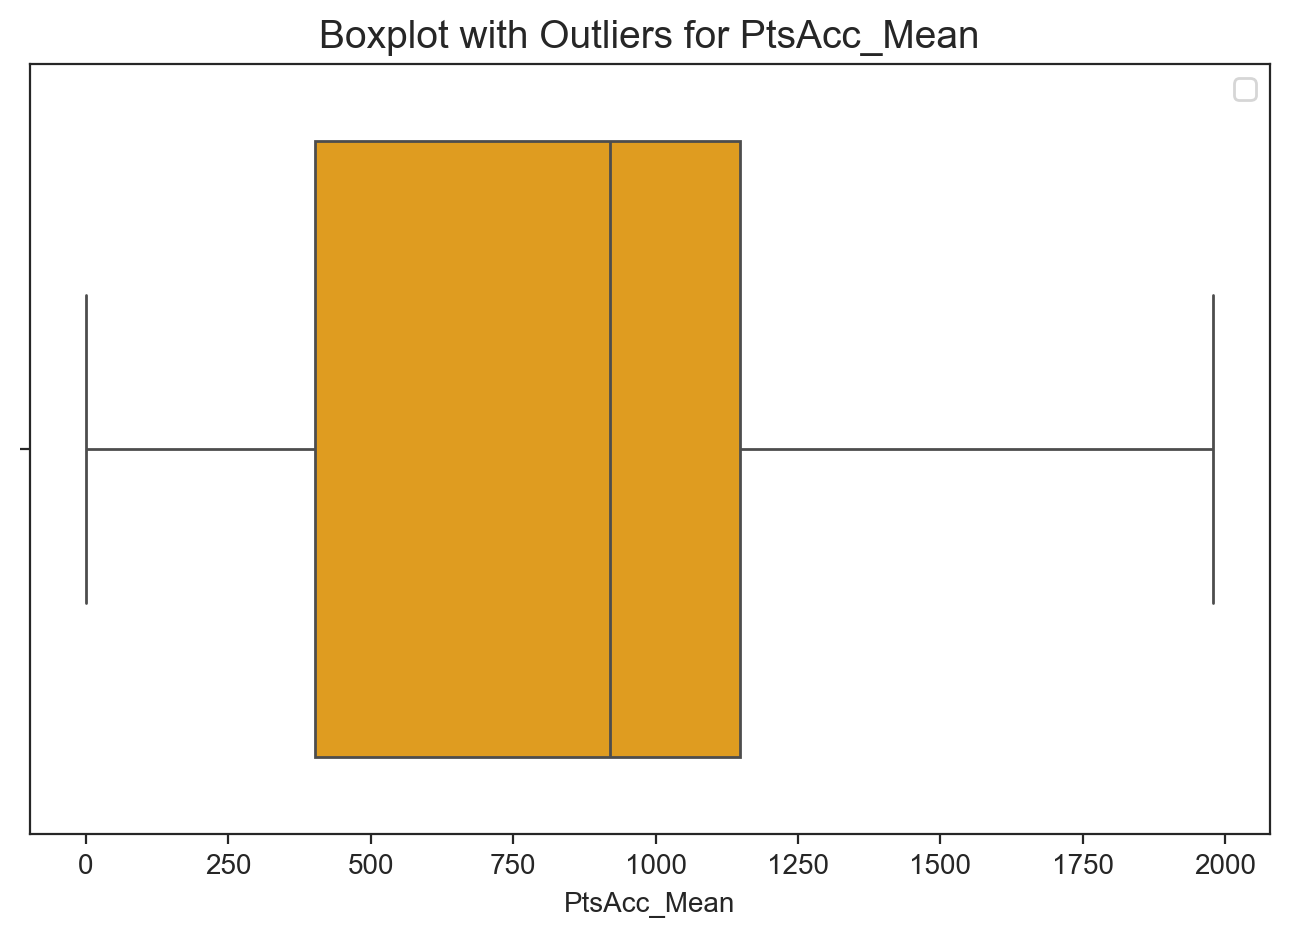

Column: PtsRed_Sum - Number of Outliers: 190
Column: PtsRed_Sum - % of Outliers: 1.15%



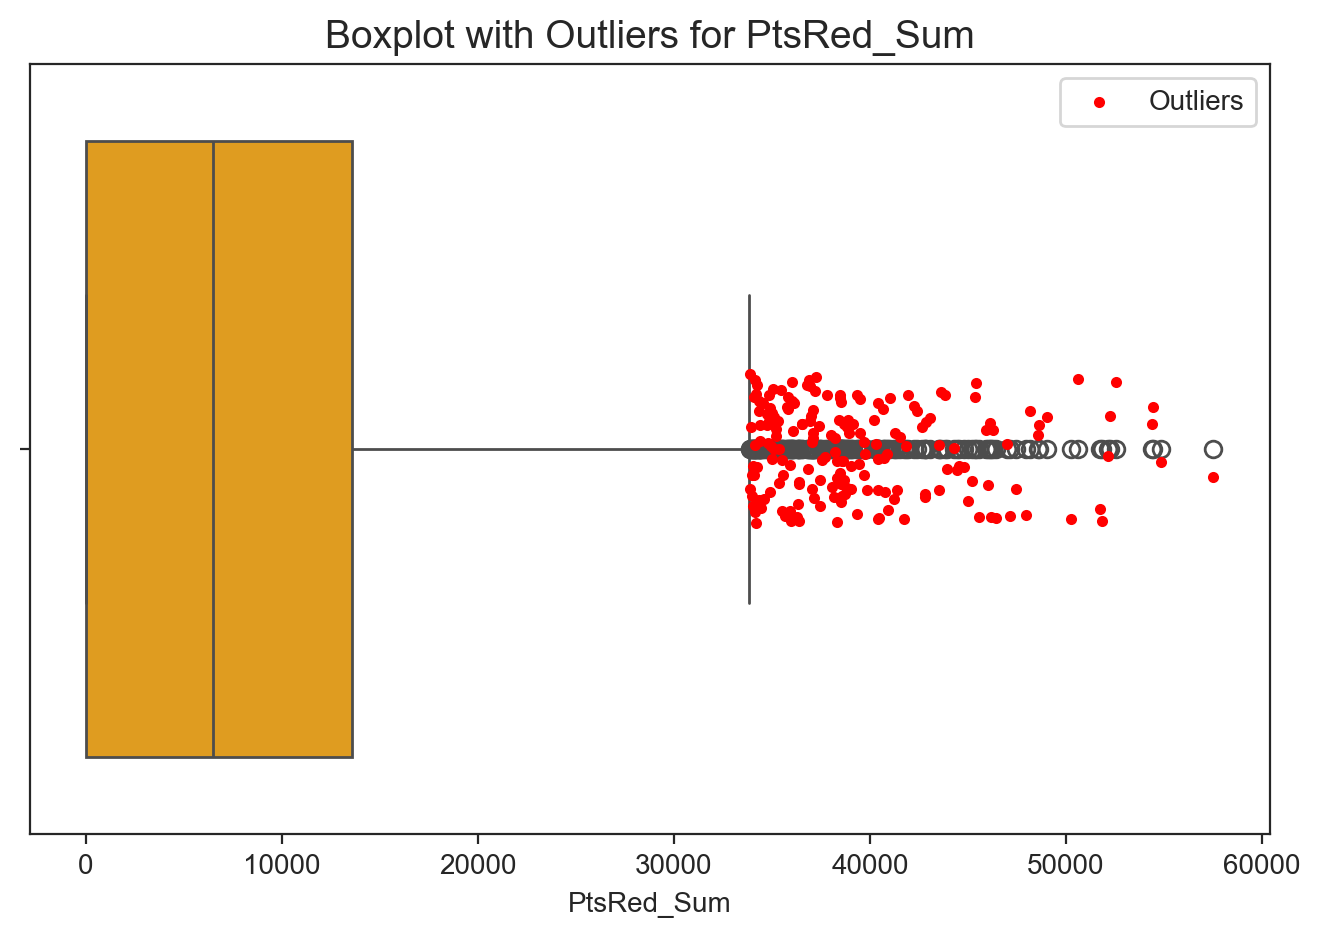

Column: PtsRed_Mean - Number of Outliers: 190
Column: PtsRed_Mean - % of Outliers: 1.15%



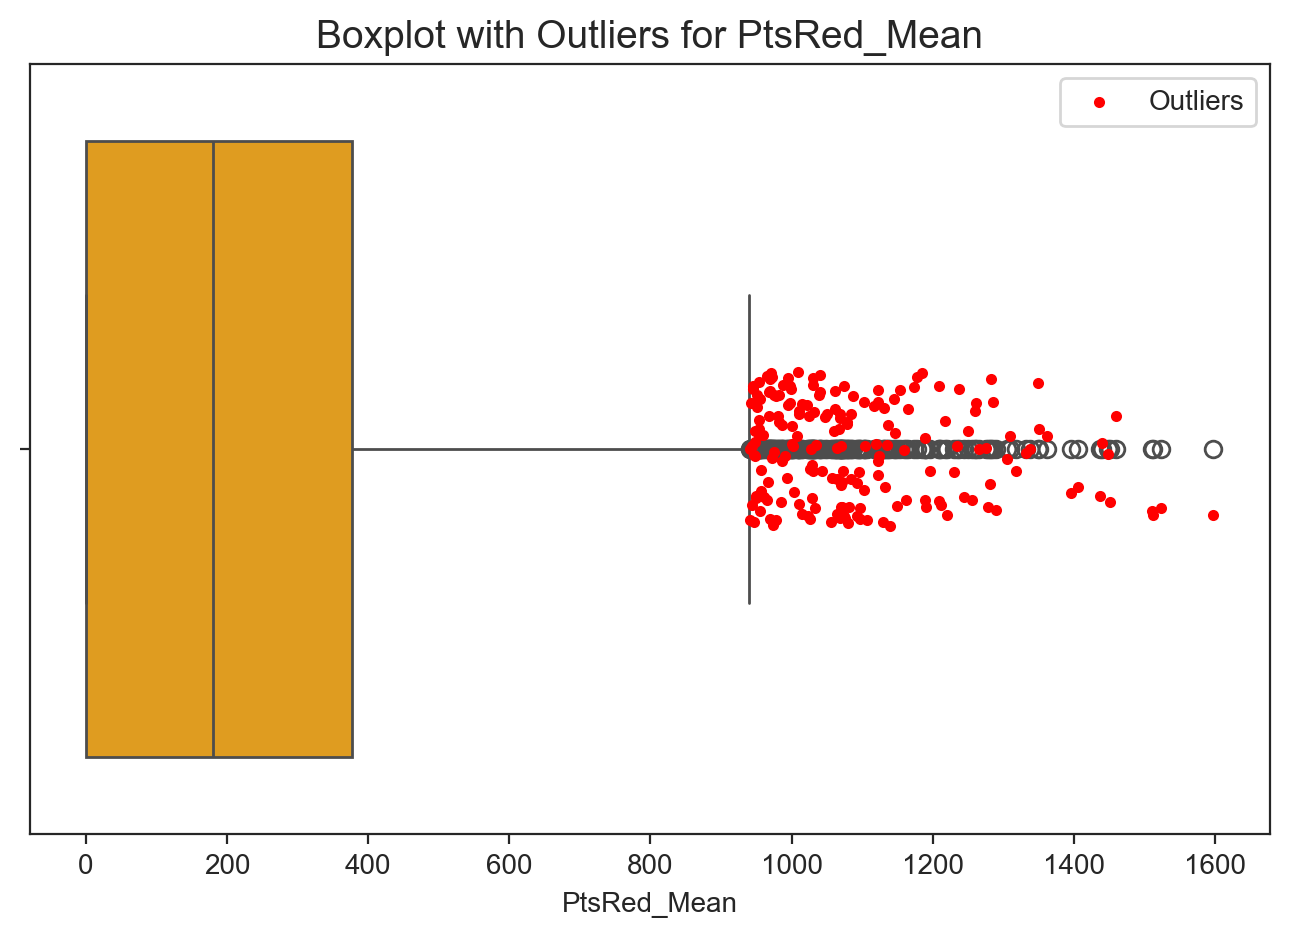

Column: CostPts_Sum - Number of Outliers: 187
Column: CostPts_Sum - % of Outliers: 1.13%



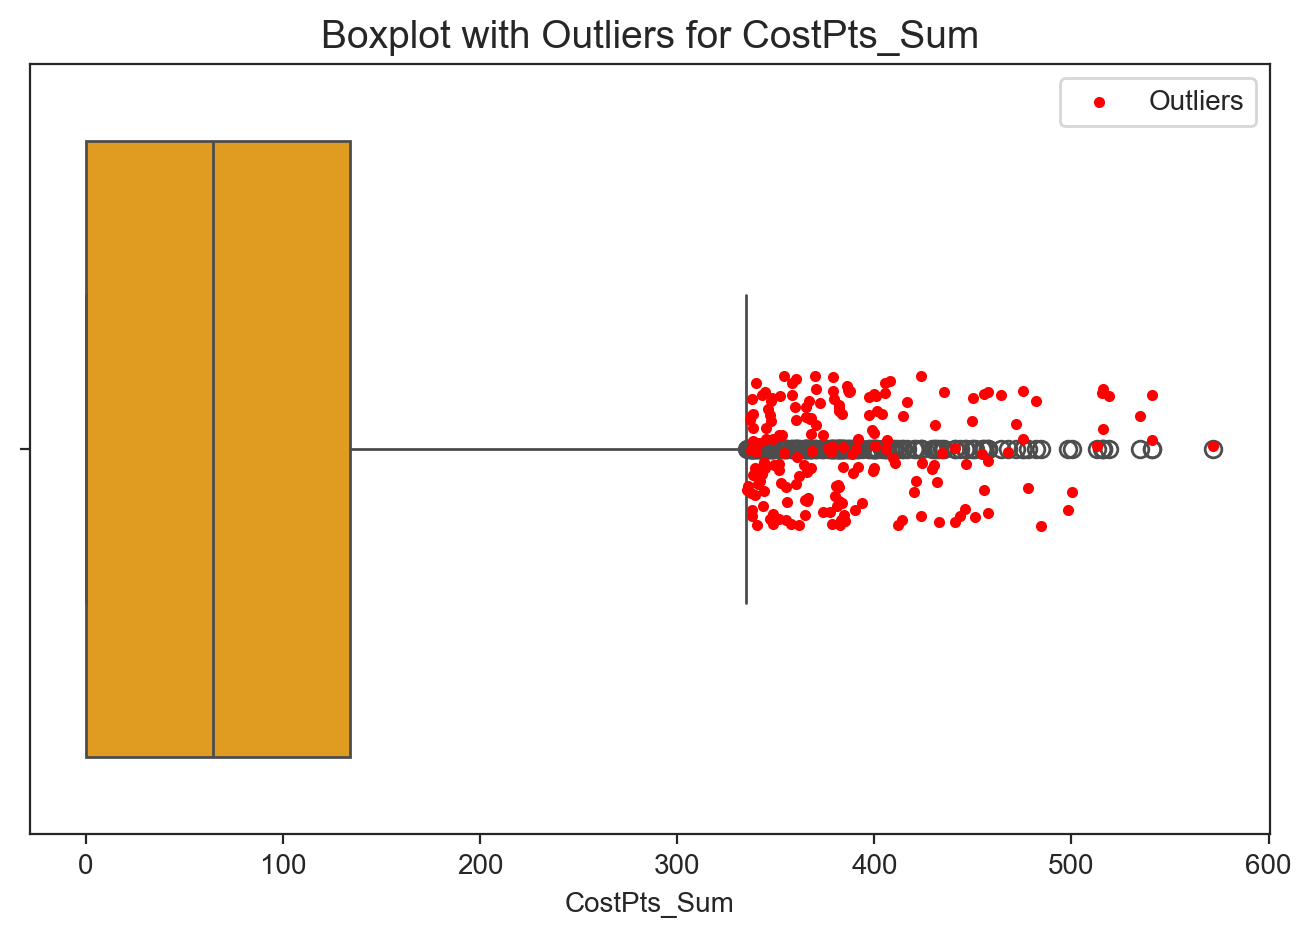

Column: CostPts_Mean - Number of Outliers: 187
Column: CostPts_Mean - % of Outliers: 1.13%



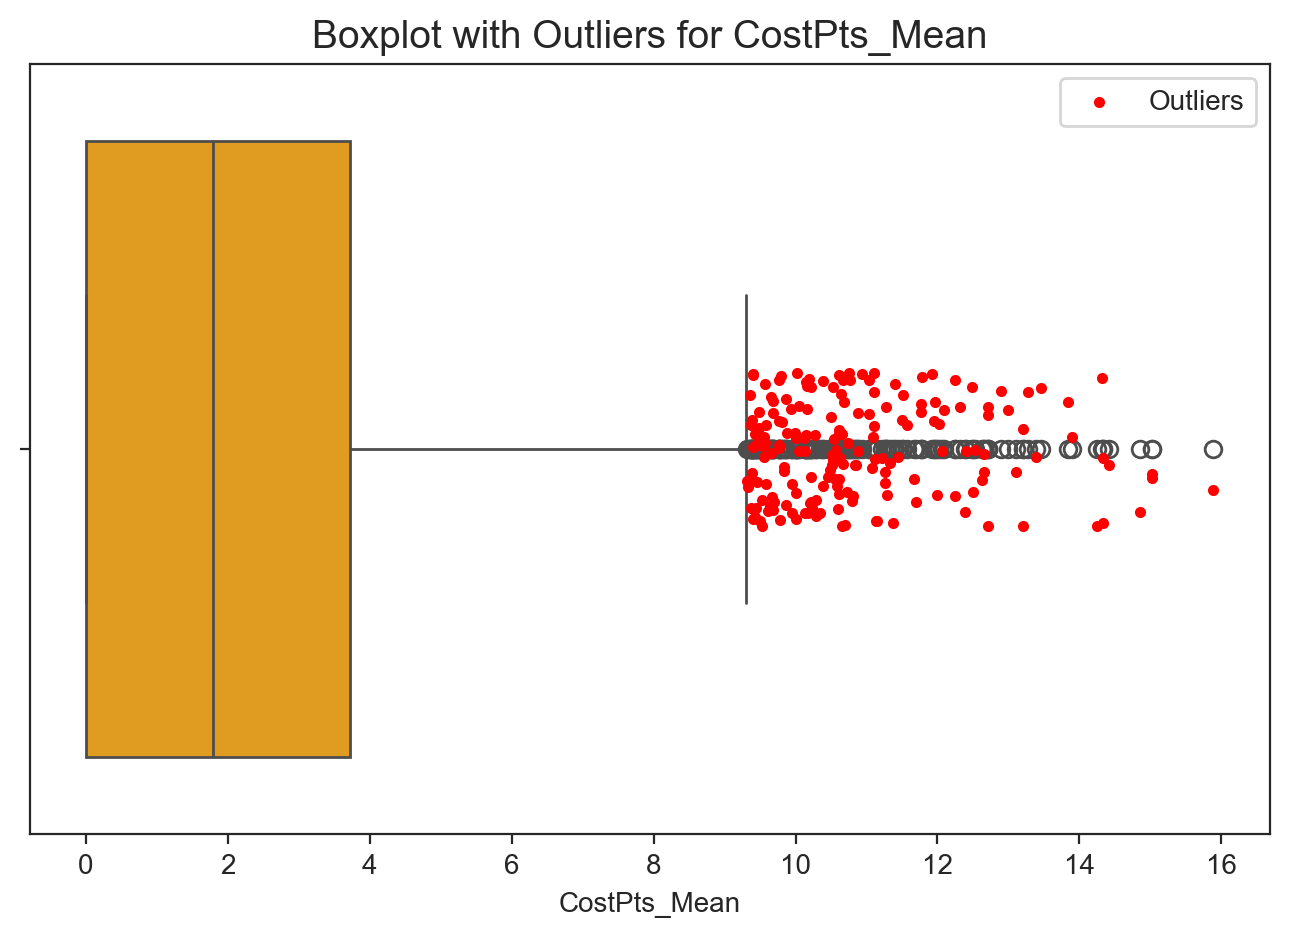

Column: PointsEfficiency - Number of Outliers: 408
Column: PointsEfficiency - % of Outliers: 2.46%



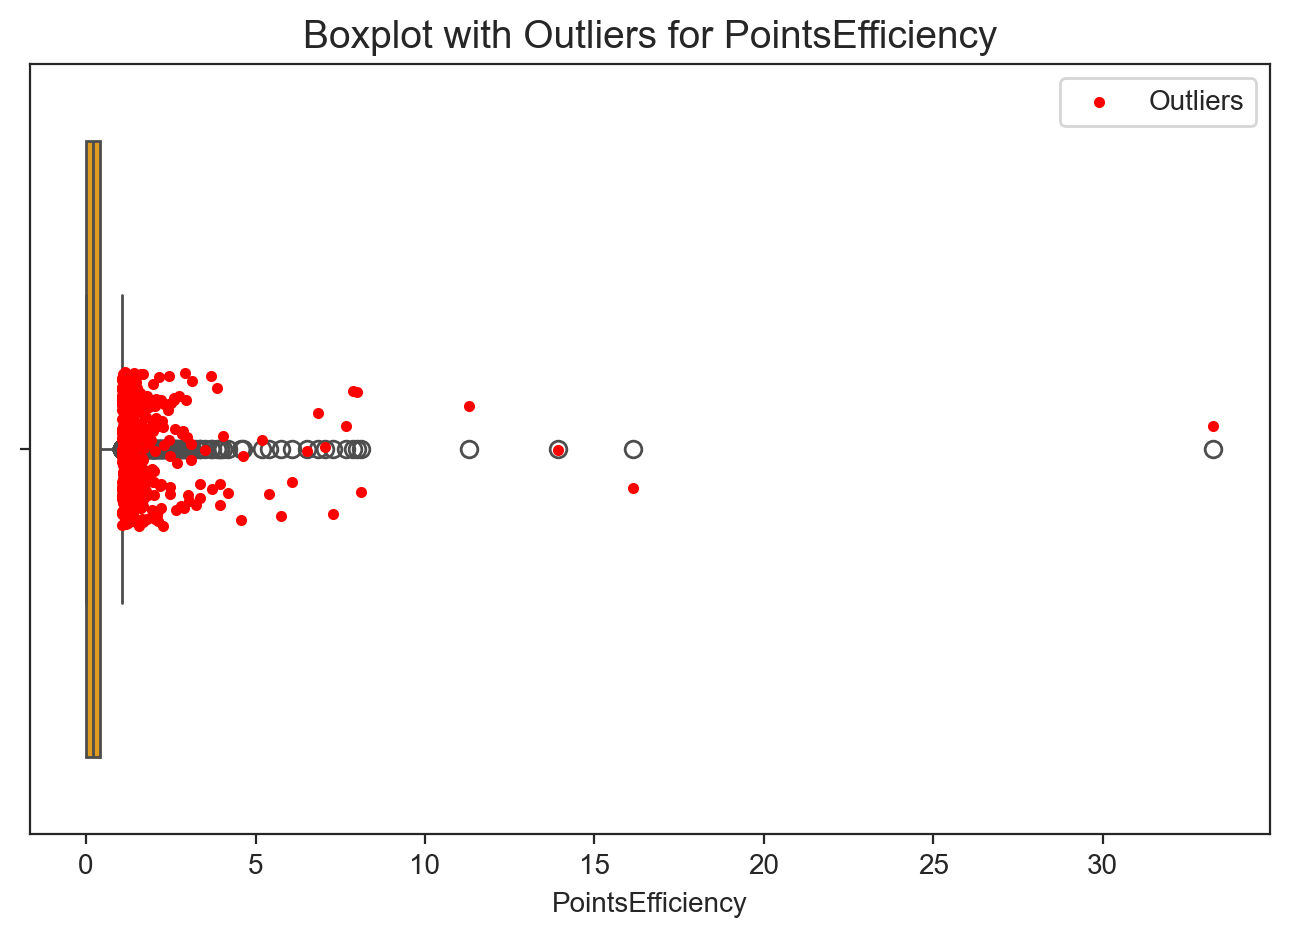

Column: DistPerFlight - Number of Outliers: 1956
Column: DistPerFlight - % of Outliers: 11.80%



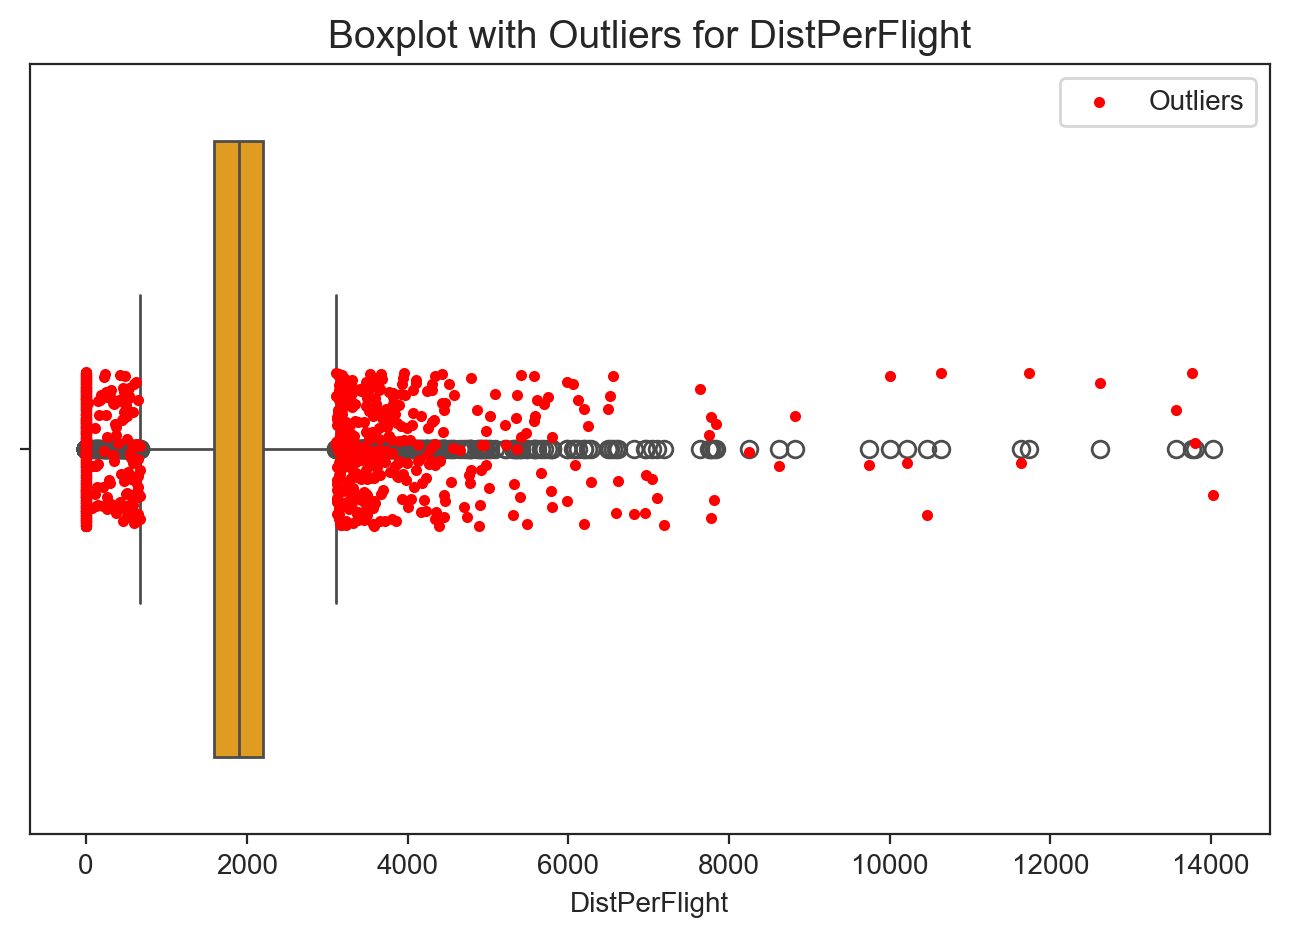

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.808978
1,Flights_Max,1630,9.834681
2,FlightsComp_Sum,18,0.108604
3,FlightsComp_Mean,18,0.108604
4,DistKM_Max,1808,10.908652
5,PtsRed_Sum,190,1.146374
6,PtsRed_Mean,190,1.146374
7,CostPts_Sum,187,1.128273
8,CostPts_Mean,187,1.128273
9,PointsEfficiency,408,2.461687


In [72]:
detect_outliers_iqr(df_agg_merged[df_agg_merged_out], 0.001)

<h3> PointsEfficiency

In [73]:
df_agg_merged.loc[df_agg_merged['PointsEfficiency']> 1, ['Loyalty#', 'Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum', 'PointsEfficiency']]

,Loyalty#,Customer Lifetime Value,Income,Days_sub,Flights_Sum,DistKM_Sum,PtsAcc_Sum,PtsRed_Sum,PointsEfficiency
74,501704,3974.86,0,2067,193.0,376675.4,37657.84,45023.5,1.195594
78,688524,3980.42,98333,2105,128.0,268011.7,26796.27,40394.0,1.507449
86,984713,3997.48,0,148,15.0,27142.0,2713.00,4552.0,1.677847
102,890753,4025.10,0,484,92.0,94183.1,9411.61,11561.5,1.228430
150,355331,4145.02,0,2002,281.0,328911.6,32883.06,34855.7,1.059990
...,...,...,...,...,...,...,...,...,...
16499,149841,32864.40,90783,243,38.0,118441.0,11841.00,12127.0,1.024153
16507,737604,33473.35,33190,2368,113.0,247871.5,24781.75,28511.7,1.150512
16549,753864,40224.01,48587,171,9.0,17427.0,1741.00,3703.0,2.126939
16550,969719,40235.97,77143,245,5.0,11768.6,1176.46,8295.4,7.051153


We are going to remove the observations where pointsefficiency is higher than 1, because having more points redeemed than accumulated is not normal. Maybe its not a mistake because customers can have points accumulated from outside of the time period of this dataset, but we will remove them to reduce potencial noise.

In [74]:
df_agg_merged = df_agg_merged[df_agg_merged['PointsEfficiency'] <= 1]

Column: PointsEfficiency - Number of Outliers: 0
Column: PointsEfficiency - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_3197/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


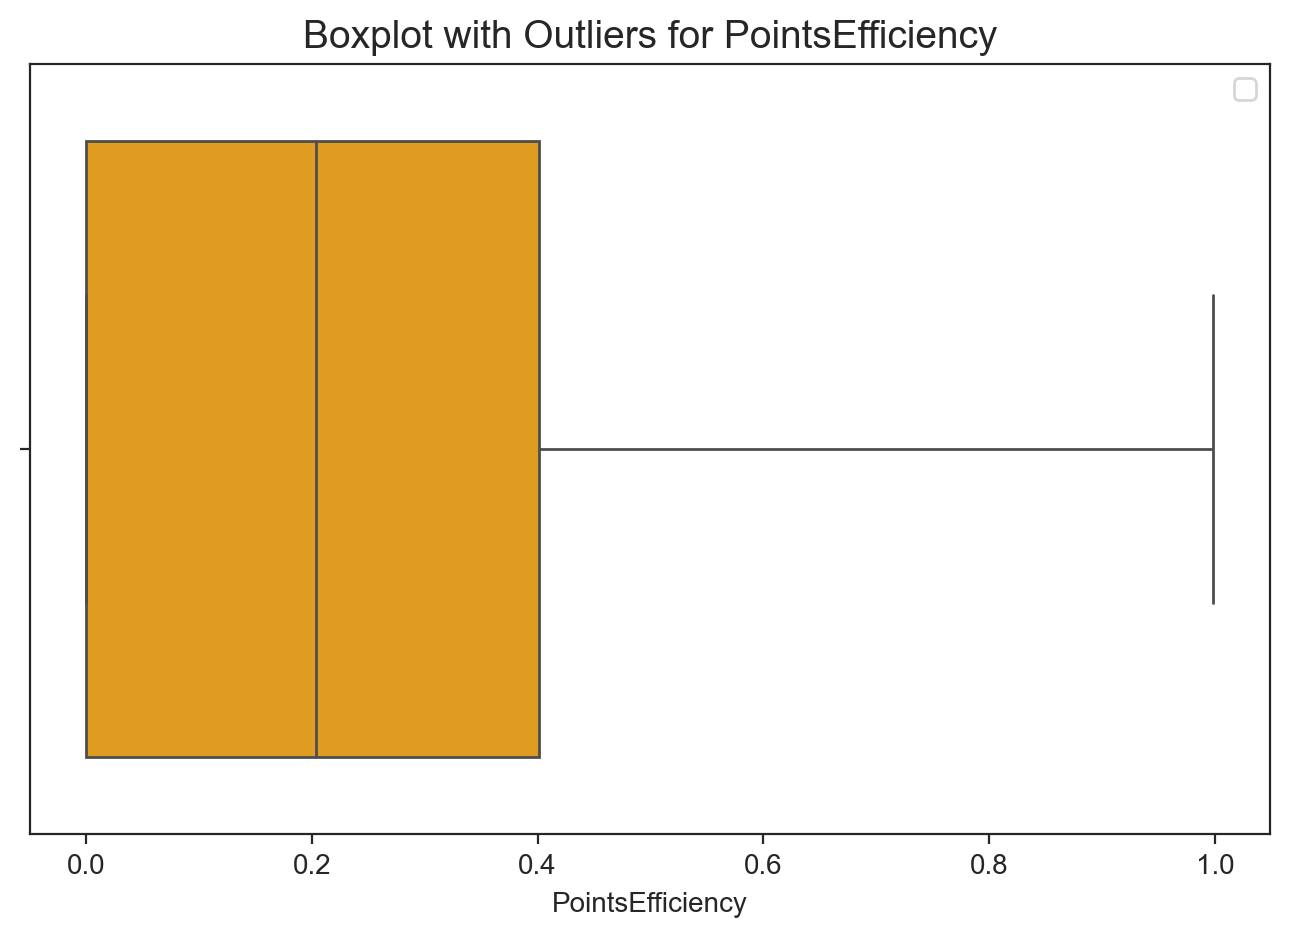

,Column,Num_Outliers,Pct_Outliers


In [75]:
pointsefficiency = ['PointsEfficiency']
detect_outliers_iqr(df_agg_merged[pointsefficiency], 0.001)

<h3>DistPerFlight

In [76]:
df_agg_merged.loc[df_agg_merged['DistPerFlight']>8000, ['Loyalty#', 'Flights_Sum', 'DistKM_Sum', 'DistPerFlight']]

,Loyalty#,Flights_Sum,DistKM_Sum,DistPerFlight
2074,443557,2.0,23267.0,11633.50
2254,295795,2.0,19998.0,9999.00
6612,353308,4.0,32980.0,8245.00
7539,305572,1.0,10463.0,10463.00
8428,472921,3.0,25851.0,8617.00
9591,840659,4.0,46958.0,11739.50
11064,278059,2.0,21275.0,10637.50
11346,731254,1.0,10216.0,10216.00
12286,808341,2.0,28057.0,14028.50
12759,430221,6.0,52914.0,8819.00


These values are high and can affect clustering algorithms. But these clients travel a lot and this means that they are valuable customers to AIAI, therefore, we will try to mitigate the impact by a log transformation or robust scalling 

Log-Transform

In [77]:
df_agg_merged["DistPerFlight_log"] = np.log1p(df_agg_merged["DistPerFlight"])

<h3>Customer Lifetime Value

In [78]:
df_agg_merged.loc[df_agg_merged['Customer Lifetime Value']>50000, ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum', 'PointsEfficiency']]

,Customer Lifetime Value,Income,Days_sub,Flights_Sum,DistKM_Sum,PtsAcc_Sum,PtsRed_Sum,PointsEfficiency
4065,51016.07,25167,902,169.0,491965.9,49188.39,8905.3,0.181045
4066,51426.25,84650,244,21.0,71013.0,7100.00,0.0,0.000000
4067,52811.49,0,372,49.0,88399.0,8838.00,4225.0,0.478049
4068,55277.45,40740,68,12.0,4104.0,410.00,0.0,0.000000
4069,56675.94,77237,1366,230.0,469220.7,46912.27,35839.3,0.763964
4070,57520.50,48367,331,209.0,414025.5,41394.35,10106.2,0.244144
4071,58166.55,61321,1025,145.0,250238.3,25016.63,9132.0,0.365037
4072,58753.88,24964,851,37.0,66859.0,6685.00,0.0,0.000000
4073,61850.19,0,2000,129.0,231506.5,23146.75,0.0,0.000000
4074,66025.75,33481,546,144.0,231571.6,23150.86,0.0,0.000000


These observations represent high-value customers, we will take the same approach we took with DistPerFlight.

LogTransform

In [79]:
df_agg_merged["Customer_Lifetime_Value_log"] = np.log1p(df_agg_merged["Customer Lifetime Value"])

<h3>Customers with Flights_Sum == 0 and customer lifetime value > 0

In [80]:
df_agg_merged.loc[(df_agg_merged['Flights_Sum'] == 0) & (df_agg_merged['Customer Lifetime Value'] > 0),
                    ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']].shape

(1470, 11)

In [81]:
df_agg_merged.loc[(df_agg_merged['Flights_Sum'] == 0) & (df_agg_merged['Customer Lifetime Value'] > 0),
                    ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']].sample(10)

,Customer Lifetime Value,Income,Days_sub,Flights_Sum,Flights_Mean,DistKM_Sum,DistKM_Mean,PtsAcc_Sum,PtsAcc_Mean,PtsRed_Sum,PtsRed_Mean
7891,8161.94,32967,571,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16103,17263.64,96917,242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10853,2545.52,29250,2427,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12930,4813.28,0,179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7461,7305.94,83221,242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2694,8750.71,25806,173,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5082,3536.65,31727,2434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2830,9185.03,73795,554,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13313,5216.91,60861,25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1660,6382.05,88663,226,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This doesn't mean that these are errors, this just means that these customers haven't done any flight since joining the loyalty program. To confirm that, we can see that most of them have low number of Days_sub.

## Scaling

MinMax ou Standard???

In [82]:
merged_agg_metric = ['Income','Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight_log']

In [83]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the data and transform it
df_agg_scaled = scaler.fit_transform(df_agg_merged[merged_agg_metric])

# Convert scaled data into a DataFrame with the same index as the original DataFrame
df_agg_scaled_df = pd.DataFrame(df_agg_scaled, columns=merged_agg_metric, index=df_agg_merged.index)

# Select the non-metric features from the original data
non_metric_features_agg = df_agg_merged.drop(columns=merged_agg_metric)

# Combine the scaled metric features with the non-metric features (ensure no new rows are added)
df_combined_agg2 = pd.concat([df_agg_scaled_df, non_metric_features_agg], axis=1)

df_combined_agg2.sample(5)

,Income,Customer_Lifetime_Value_log,Days_sub,Flights_Sum,Flights_Mean,Flights_Max,FlightsComp_Sum,FlightsComp_Mean,DistKM_Sum,DistKM_Mean,...,Loyalty#,Province or State,City,Gender,Education,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,DistPerFlight
13809,0.432902,0.295718,0.480325,0.786127,0.786127,0.857143,0.613445,0.613445,0.531942,0.531942,...,939932,Manitoba,Winnipeg,male,Bachelor,Divorced,Star,5808.93,Standard,1393.863971
13352,0.284524,0.269457,0.833671,0.543353,0.543353,0.619048,0.378151,0.378151,0.534204,0.534204,...,242348,Quebec,Quebec City,male,Bachelor,Married,Star,5259.71,Standard,2025.227128
14812,0.253858,0.386896,0.010142,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,780389,British Columbia,Vancouver,male,Bachelor,Single,Star,8200.79,Standard,0.000000
4739,0.297036,0.133744,0.138742,0.187861,0.187861,0.857143,0.008403,0.008403,0.100310,0.100310,...,533391,Ontario,Toronto,female,Bachelor,Divorced,Nova,3147.97,Standard,1099.907692
6695,0.702033,0.284989,0.981744,0.728324,0.728324,0.952381,0.369748,0.369748,0.606975,0.606975,...,895921,British Columbia,Vancouver,male,Bachelor,Single,Nova,5577.94,Standard,1716.701984


In [84]:
# Initialize MinMaxScaler
scaler2 = StandardScaler()

# Fit the scaler on the data and transform it
df_agg_scaled = scaler2.fit_transform(df_agg_merged[merged_agg_metric])

# Convert scaled data into a DataFrame with the same index as the original DataFrame
df_agg_scaled_df = pd.DataFrame(df_agg_scaled, columns=merged_agg_metric, index=df_agg_merged.index)

# Select the non-metric features from the original data
non_metric_features_agg = df_agg_merged.drop(columns=merged_agg_metric)

# Combine the scaled metric features with the non-metric features (ensure no new rows are added)
df_combined_agg = pd.concat([df_agg_scaled_df, non_metric_features_agg], axis=1)

df_combined_agg.sample(5)

,Income,Customer_Lifetime_Value_log,Days_sub,Flights_Sum,Flights_Mean,Flights_Max,FlightsComp_Sum,FlightsComp_Mean,DistKM_Sum,DistKM_Mean,...,Loyalty#,Province or State,City,Gender,Education,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,DistPerFlight
6379,0.030411,-0.285116,-0.421215,0.328885,0.328885,0.077925,1.798818,1.798818,0.889039,0.889039,...,495942,Ontario,Trenton,female,Bachelor,Married,Nova,5219.20,Standard,2462.417514
8047,-1.245134,0.455938,-1.126491,-0.830687,-0.830687,1.178734,-0.178719,-0.178719,-0.890450,-0.890450,...,689839,British Columbia,Vancouver,male,College,Single,Nova,8460.81,2021 Promotion,1814.753086
3694,-0.776856,1.663646,0.043534,1.585087,1.585087,0.995266,0.225777,0.225777,1.714290,1.714290,...,793384,Quebec,Montreal,female,Doctor,Married,Aurora,18591.55,Standard,2027.777224
1510,0.957639,-0.073883,-1.184924,-1.809075,-1.809075,-2.674098,-1.527040,-1.527040,-1.796019,-1.796019,...,477867,Ontario,Trenton,female,Bachelor,Single,Aurora,5989.77,Standard,0.000000
12435,-0.631947,-0.655450,-1.184924,-1.809075,-1.809075,-2.674098,-1.527040,-1.527040,-1.796019,-1.796019,...,441719,Quebec,Montreal,female,High School or Below,Married,Star,4099.66,Standard,0.000000


## Encoding of categorical features

We will encode the categorical features using the OHE.

In [85]:
df_combined_agg.columns

Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight_log', 'Loyalty#',
       'Province or State', 'City', 'Gender', 'Education', 'Marital Status',
       'LoyaltyStatus', 'Customer Lifetime Value', 'EnrollmentType',
       'DistPerFlight'],
      dtype='object')

In [86]:
non_metric_features_agg = ['City',	'Province or State',
                       		'Gender',	'Education',	'Marital Status',
                        	'LoyaltyStatus',	'EnrollmentType']

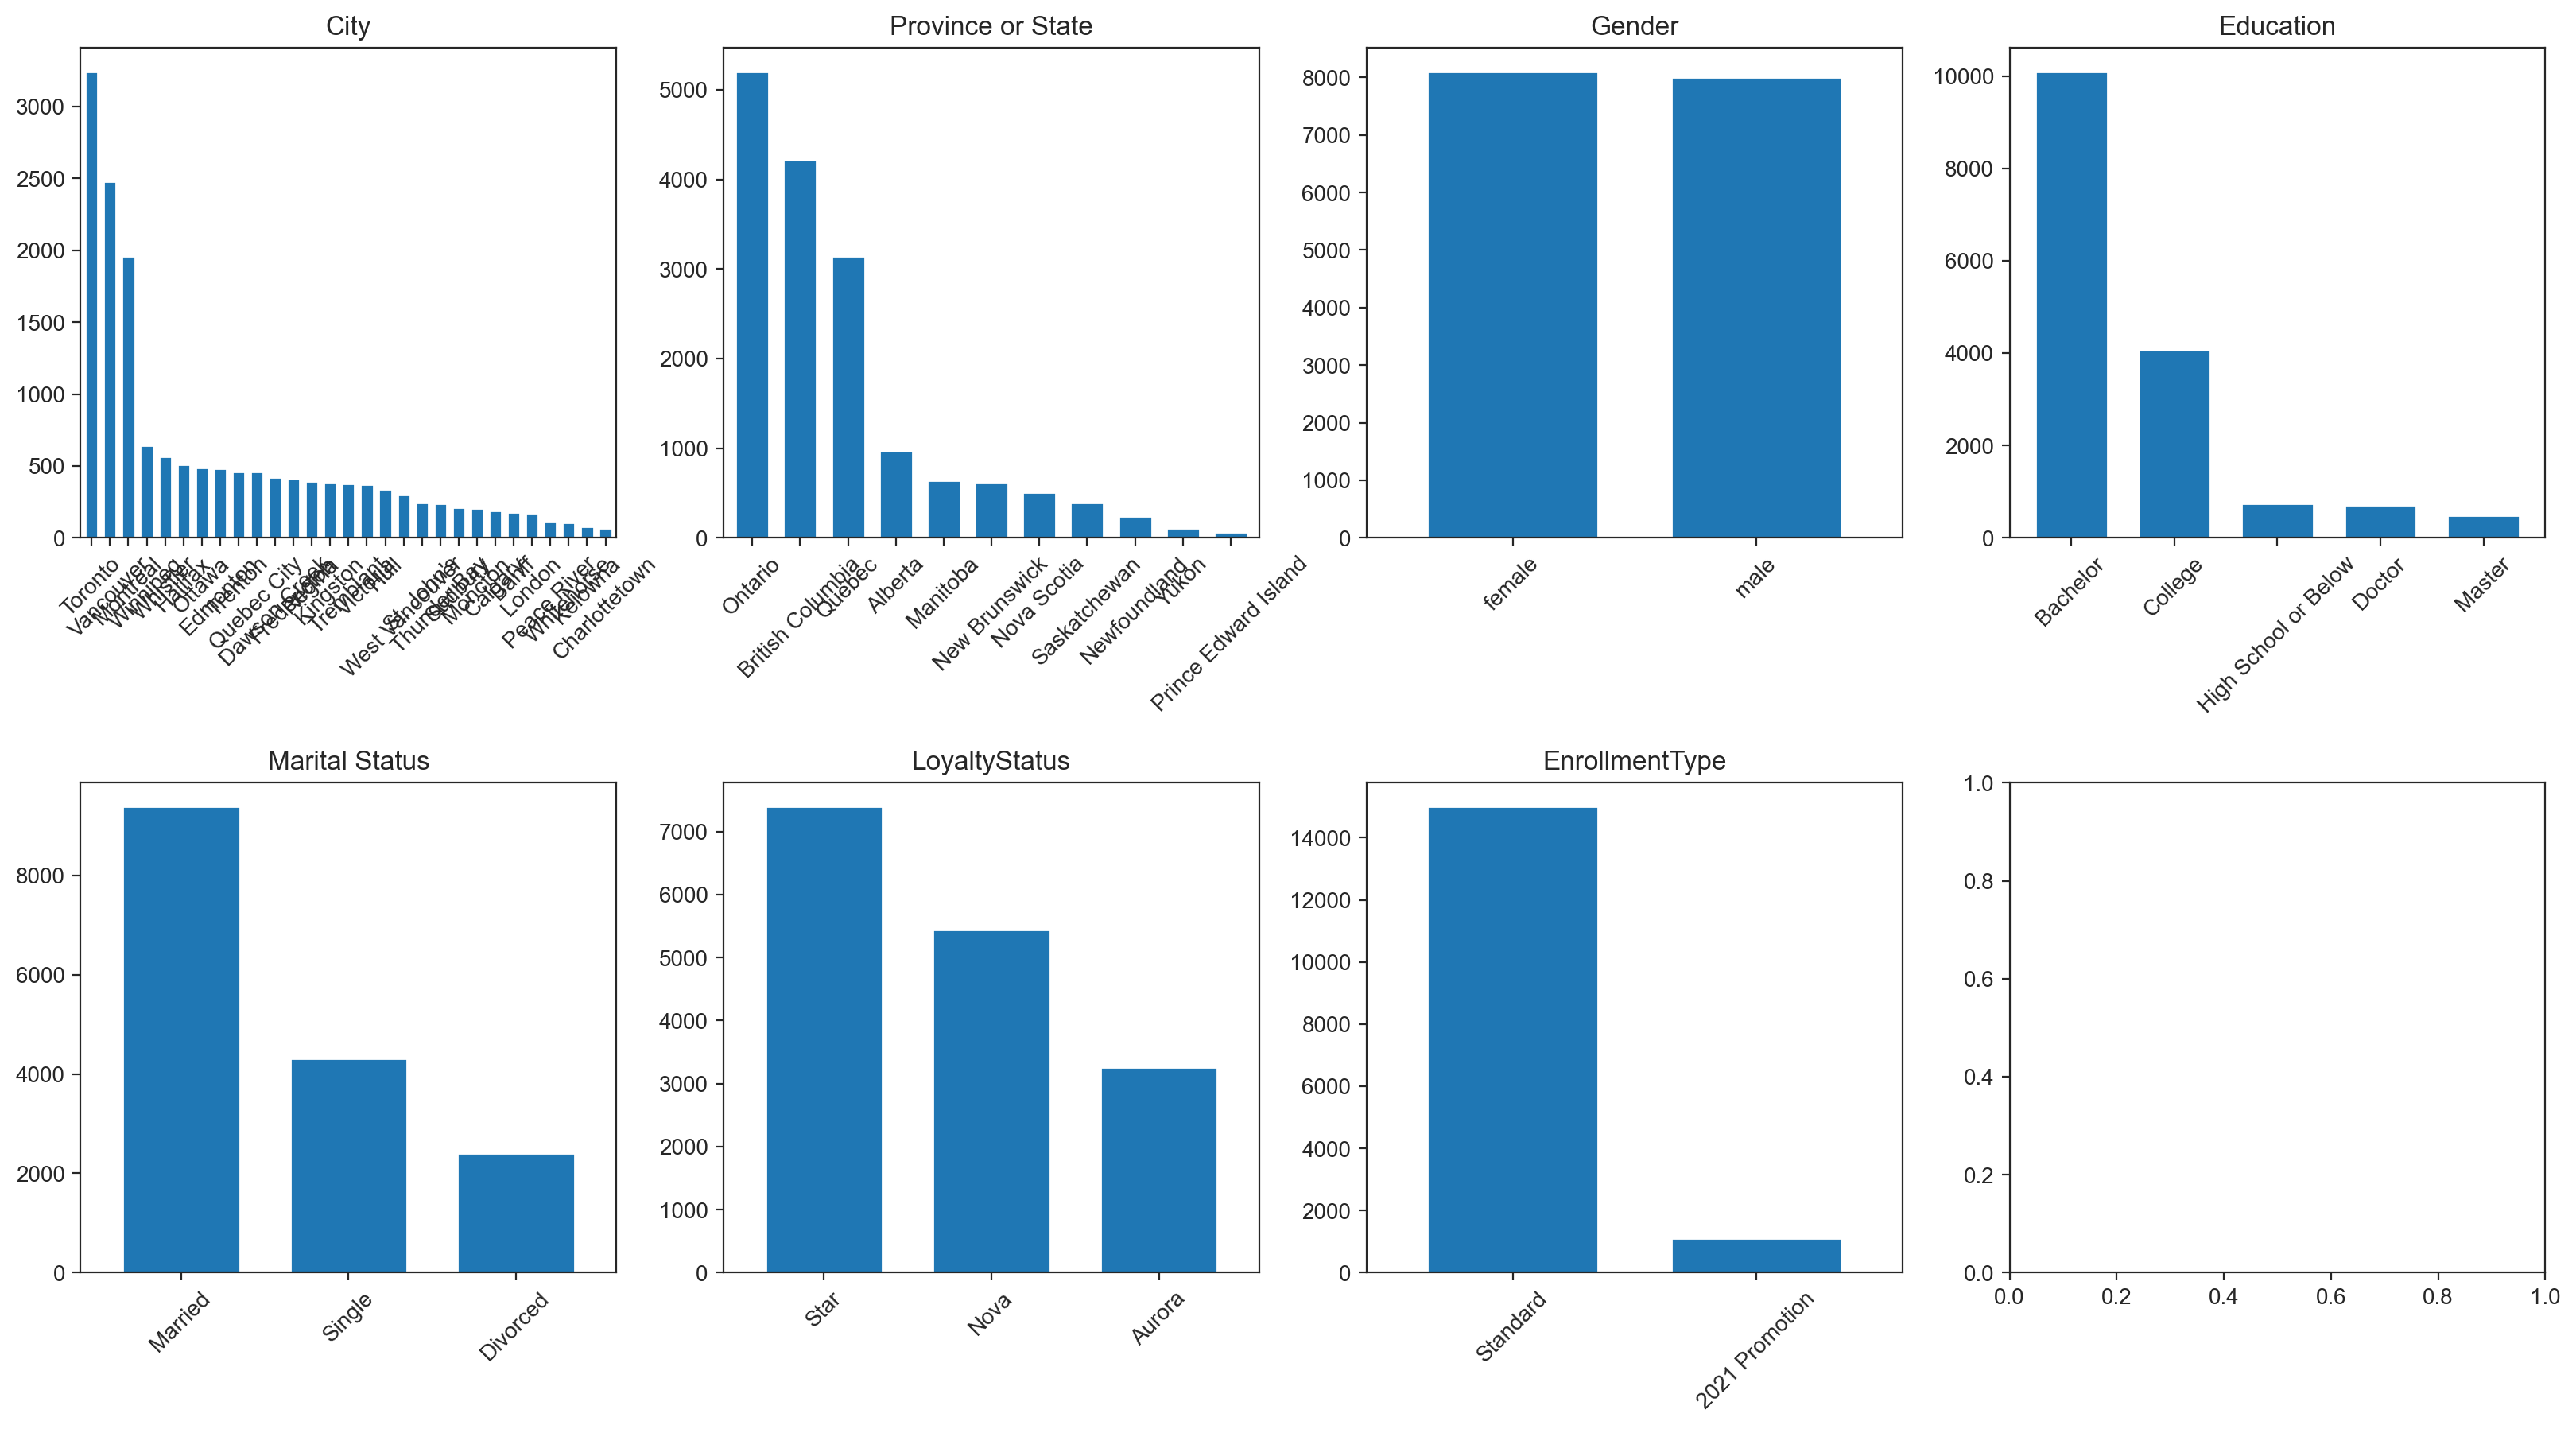

In [87]:
fig, axes = plt.subplots(
    2,
    ceil(len(non_metric_features_agg) / 2),
    figsize=(20,10))

for ax, feat in zip(axes.flatten(), non_metric_features_agg):
    df_combined_agg[feat].value_counts().plot.bar(ax=ax, width=.7)
    ax.set_title(feat)
    ax.set_xlabel(None)
    ax.set_ylabel(None) 
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=0.5)
plt.show()

We are going to use the One hot Encondig for the features "Gender", "Marital Status" and "Enrollment Type". For "Education" since we can order them from the least level of studies to the highest, we are using the Ordinal Enconding. Due to its high cardinality, for "Province or State" and "City" we are using the Frequency Enconding.

In [88]:
df_ohc = df_combined_agg.copy()

categorical_features = ['Gender','Marital Status', 'EnrollmentType']

ohc = OneHotEncoder(sparse_output=False)

ohc_feat = ohc.fit_transform(df_ohc[categorical_features])

ohc_feat_names = ohc.get_feature_names_out(categorical_features)

ohc_df = pd.DataFrame(ohc_feat, index=df_ohc.index, columns=ohc_feat_names)

df_ohc = pd.concat([df_ohc, ohc_df], axis=1)

df_final = df_ohc.copy()
# Dropping categorical Variables
df_final = df_final.drop(columns=['Gender','Marital Status', 'EnrollmentType'])

In [89]:
df_final = df_final.set_index('Loyalty#')

In [90]:
education_order = [
    'High School or Below',
    'College',
    'Bachelor',
    'Master',
    'Doctor'
]

encoder_edu = OrdinalEncoder(categories=[education_order])

df_final['Education_Encoded'] = encoder_edu.fit_transform(
    df_final[['Education']]
)

df_final = df_final.drop(columns=['Education'])

In [91]:
# Proporção (0–1). Se quiser em %, multiplicar por 100 (ver abaixo).
province_share = df_final['Province or State'].value_counts(normalize=True)
df_final['Province_FE'] = df_final['Province or State'].map(province_share)

city_share = df_final['City'].value_counts(normalize=True)
df_final['City_FE'] = df_final['City'].map(city_share)

# (opcional) se quiser em percentagem 0–100:
# df_final['Province_FE'] *= 100
# df_final['City_FE'] *= 100

df_final = df_final.drop(columns=['Province or State', 'City'])

df_final[['Province_FE', 'City_FE']].head()

,Province_FE,City_FE
Loyalty#,,
480934,0.322971,0.201353
549612,0.060002,0.030032
429460,0.261976,0.153884
608370,0.322971,0.201353
530508,0.194899,0.021221


## Feature Selection

In [92]:
df_final = df_final.drop('Customer Lifetime Value', axis=1)
df_final = df_final.drop('DistPerFlight', axis=1)

**Checking for multiculinearity**

We will indentify pairs of features that are highly correlated. First, we will define a treshold of |0.8|.



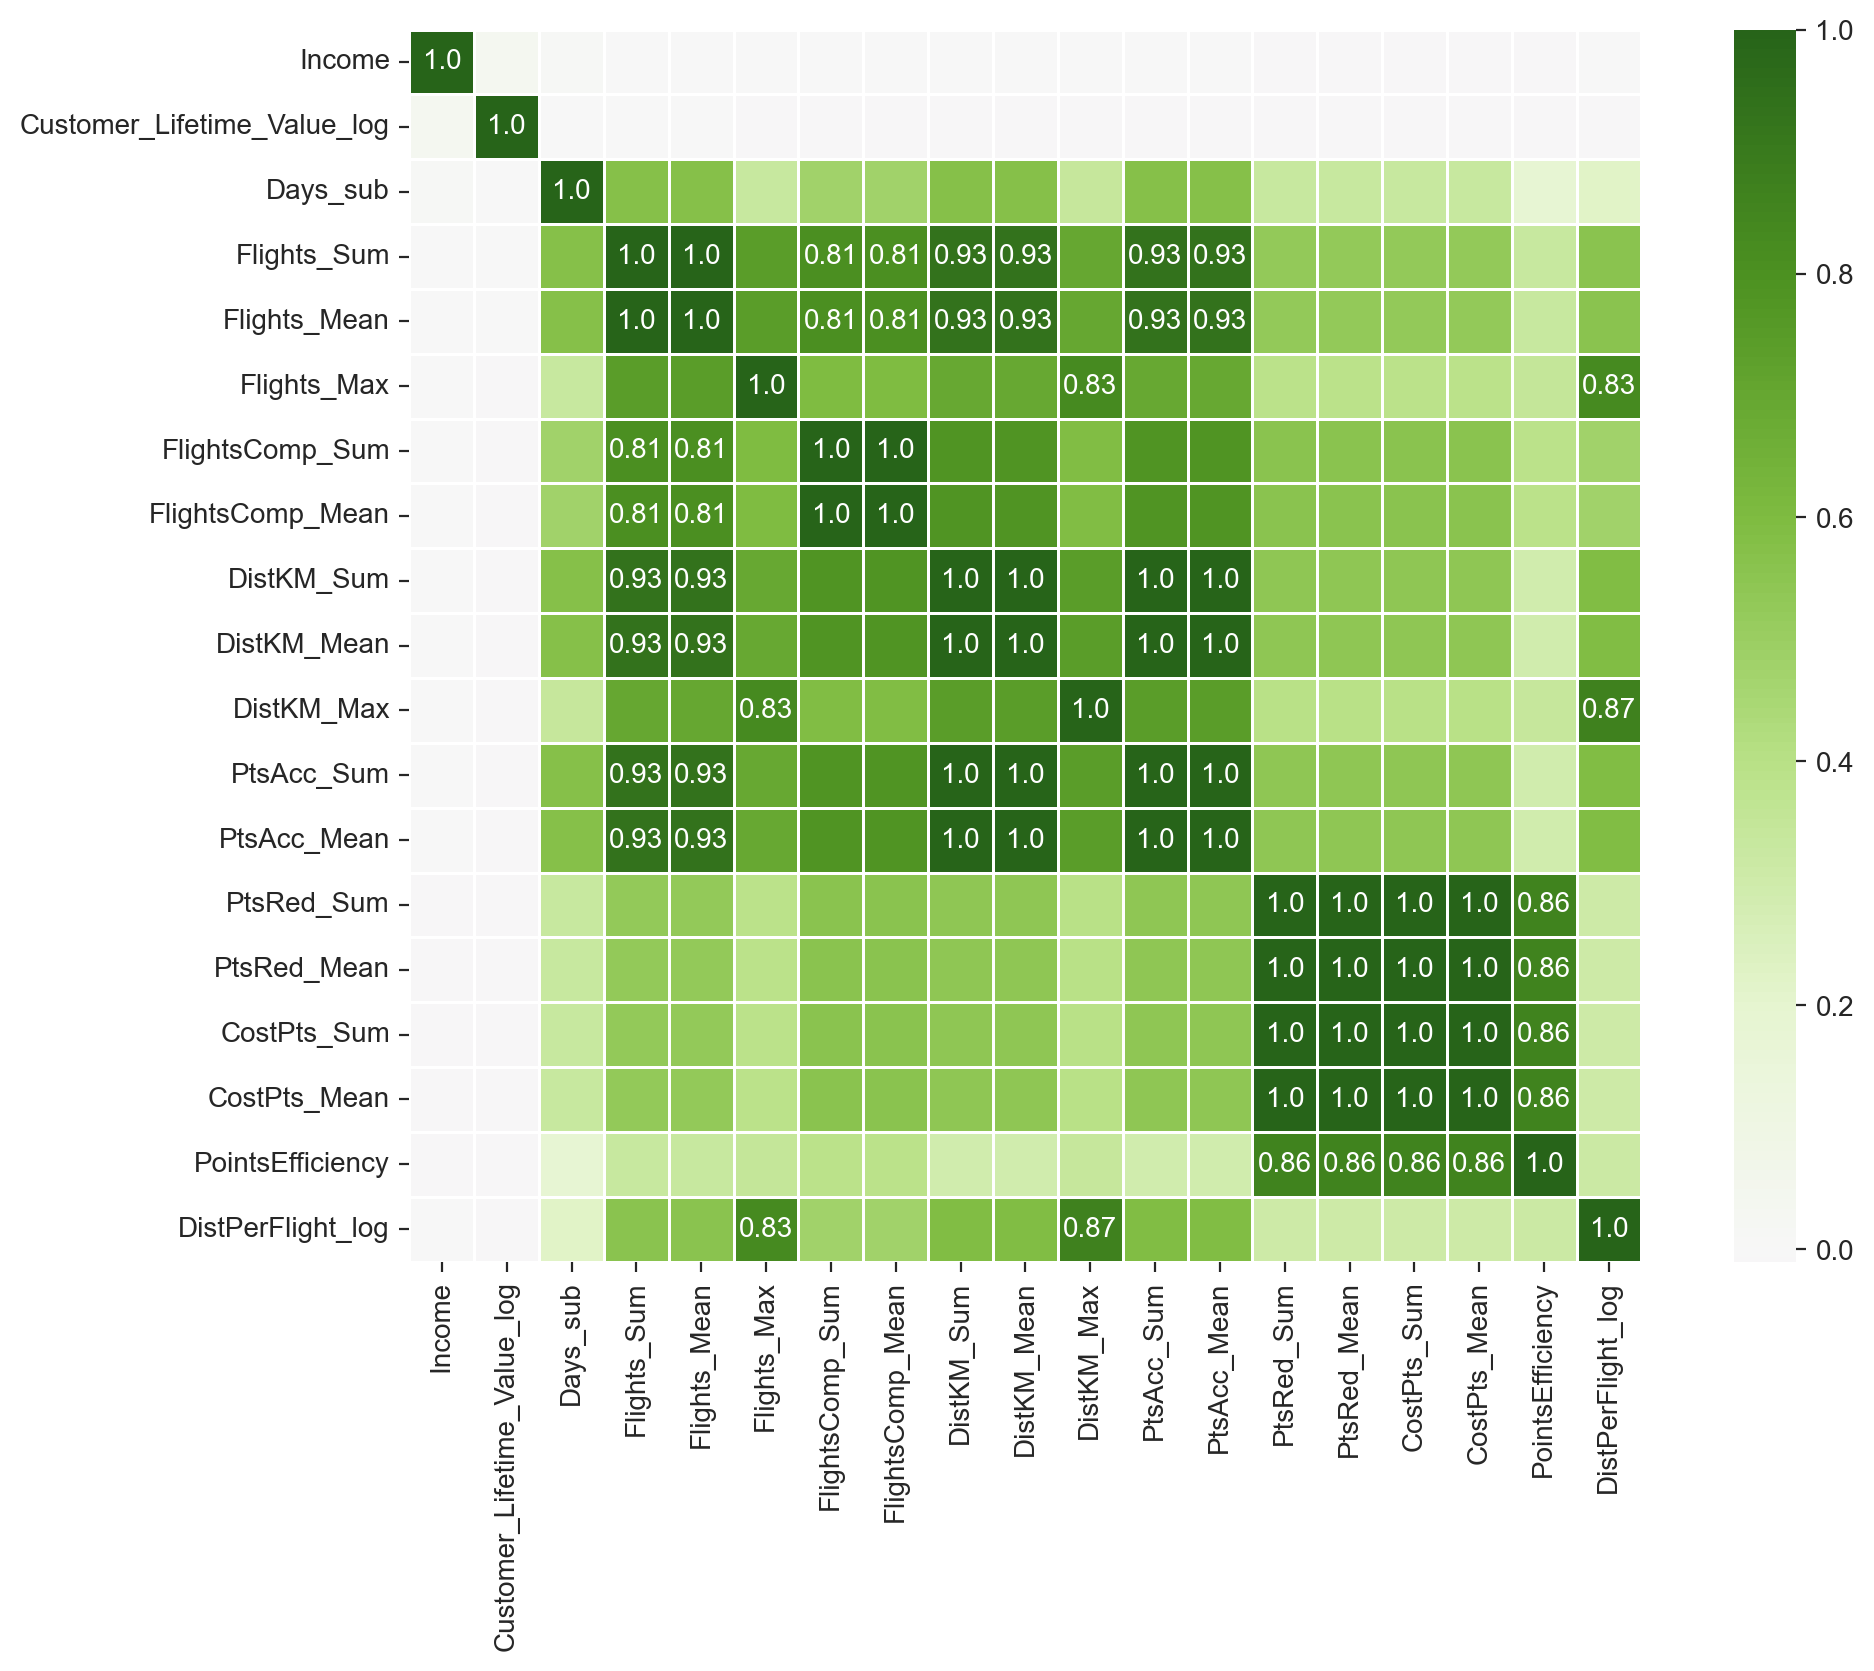

In [93]:
plt.figure(figsize=(12,8))
corr = df_final[merged_agg_metric].corr()
corr = corr.round(2)

sns.heatmap(
    corr,
    center = 0,
    cmap='PiYG',
    annot=np.where(np.absolute(corr) >= 0.8, corr.values, np.full(corr.values.shape, "")),
    fmt='s',
    square=True,
    linewidths=.5,
)
plt.show()

In [94]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

high_corr_pairs = corr_pairs[corr_pairs['Correlation'] > 0.8]

high_corr_pairs

,Feature1,Feature2,Correlation
51,Flights_Sum,Flights_Mean,1.00
53,Flights_Sum,FlightsComp_Sum,0.81
54,Flights_Sum,FlightsComp_Mean,0.81
55,Flights_Sum,DistKM_Sum,0.93
56,Flights_Sum,DistKM_Mean,0.93
58,Flights_Sum,PtsAcc_Sum,0.93
59,Flights_Sum,PtsAcc_Mean,0.93
67,Flights_Mean,FlightsComp_Sum,0.81
68,Flights_Mean,FlightsComp_Mean,0.81
69,Flights_Mean,DistKM_Sum,0.93


For the flights group of features, since thry're all high correlated, the one that makes more sence to keep is "FlightsSum".

For the Distance group of features, the same conclusion as for the previous one, we must keep "DistKM_Sum".

For the Points Accumulated group of features, same conclusion as the previous ones, we must kepp "PtsAcc_Sum".

For the Points Redeemed group of features, same conclusion as the previous ones, we must kepp "PtsRed_Sum".

For the Cost Points group of features, same conclusion as the previous ones, we must kepp "CostPts_Sum".

For the Companions Flights group of features, same conclusion as the previous ones, we must kepp "FlightsComp_Sum".


In [95]:
features_to_drop = [
    'Flights_Mean',
    'Flights_Max',
    'FlightsComp_Mean',
    'DistKM_Mean',
    'DistKM_Max',
    'PtsAcc_Mean',
    'PtsRed_Mean',
    'CostPts_Mean'
]

df_final = df_final.drop(columns=[col for col in features_to_drop if col in df_final.columns])
merged_agg_metric = [col for col in merged_agg_metric if col not in features_to_drop]
df_final.columns


Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum',
       'CostPts_Sum', 'PointsEfficiency', 'DistPerFlight_log', 'LoyaltyStatus',
       'Gender_female', 'Gender_male', 'Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single',
       'EnrollmentType_2021 Promotion', 'EnrollmentType_Standard',
       'Education_Encoded', 'Province_FE', 'City_FE'],
      dtype='object')

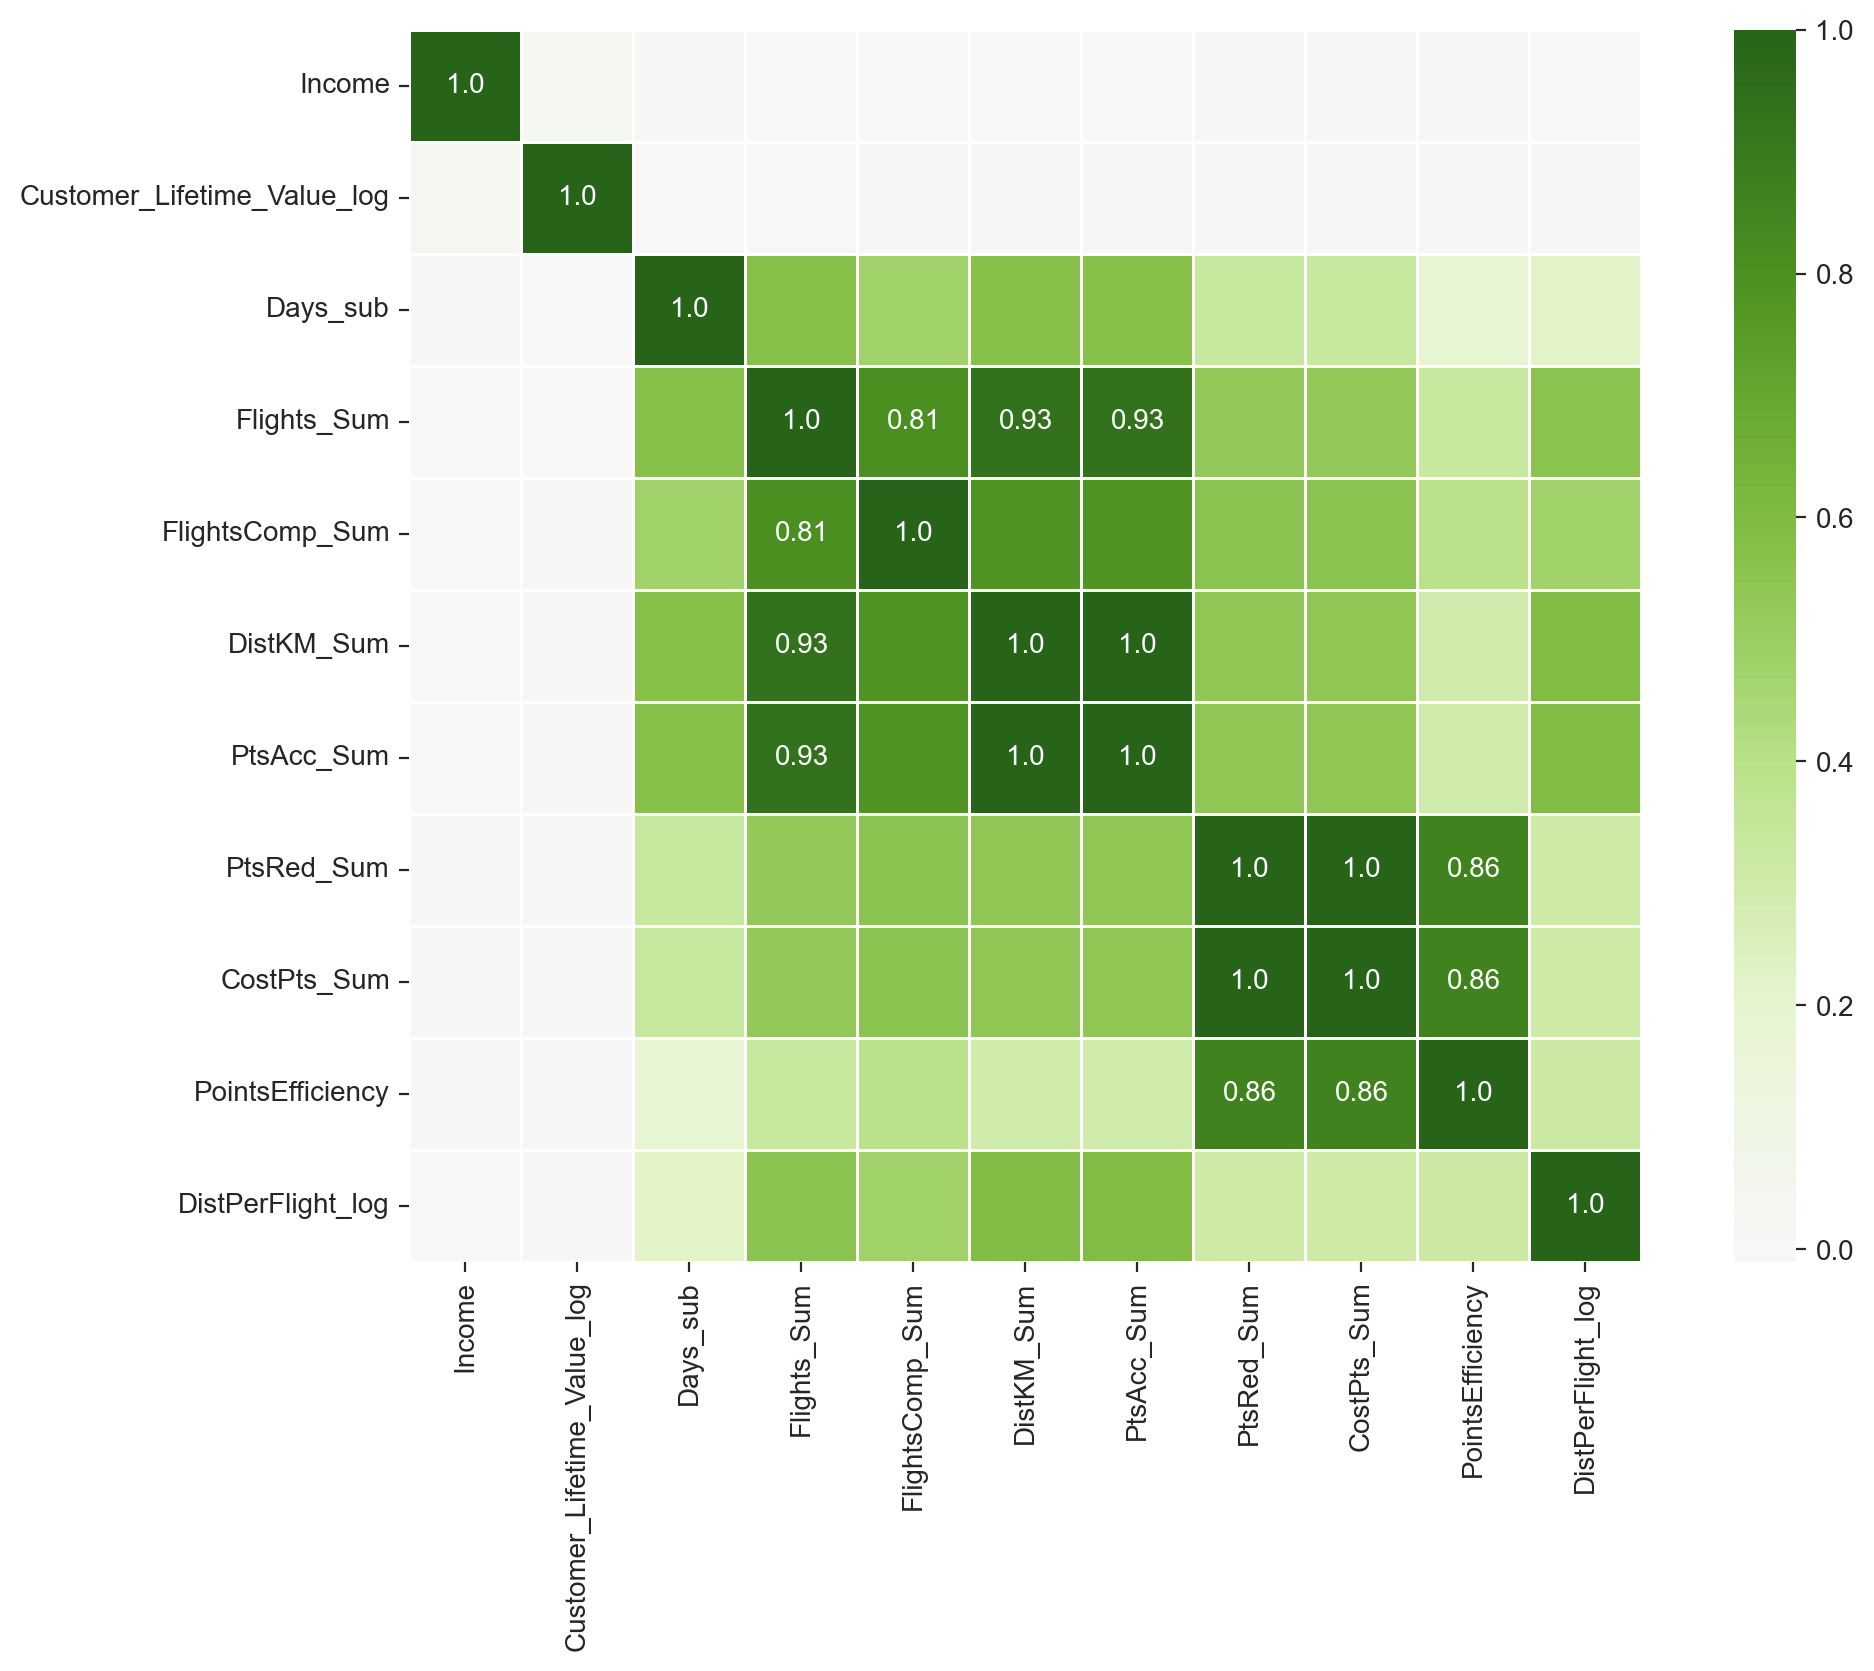

In [96]:
plt.figure(figsize=(12,8))
corr = df_final[merged_agg_metric].corr()
corr = corr.round(2)

sns.heatmap(
    corr,
    center = 0,
    cmap='PiYG',
    annot=np.where(np.absolute(corr) >= 0.8, corr.values, np.full(corr.values.shape, "")),
    fmt='s',
    square=True,
    linewidths=.5,
)
plt.show()

In [97]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

high_corr_pairs = corr_pairs[corr_pairs['Correlation'] > 0.8]

high_corr_pairs

,Feature1,Feature2,Correlation
27,Flights_Sum,FlightsComp_Sum,0.81
28,Flights_Sum,DistKM_Sum,0.93
29,Flights_Sum,PtsAcc_Sum,0.93
40,DistKM_Sum,PtsAcc_Sum,1.00
49,PtsRed_Sum,CostPts_Sum,1.00
50,PtsRed_Sum,PointsEfficiency,0.86
52,CostPts_Sum,PointsEfficiency,0.86


We still observe some redundant features. Since "Flights_Sum" and "PtsAcc_Sum" have a strong correlation, we will only keep `Flights_Sum`. Since "PtsRed_Sum" and "CostPts_Sum" have a perfect correlation, we will only keep `PtsRed_Sum`.  "PointsEfficiency" still has a strong correlation with "PtsRed_Sum" so we decided to keep `PointsEfficiency`since this gives us more information. We decided to keep both "Flights_Sum" and "FlightsComp_Sum" even having more than 0.8 because it can still give us some useful information but, between "Flights_Sum" and "DistKm_Sum" we will only keep "Flights_Sum".

In [98]:
features_to_drop = [
'CostPts_Sum', 'PtsAcc_Sum', 'PtsRed_Sum','DistKM_Sum'
]

df_final = df_final.drop(columns=[col for col in features_to_drop if col in df_final.columns])
merged_agg_metric = [col for col in merged_agg_metric if col not in features_to_drop]
df_final.columns

Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'PointsEfficiency', 'DistPerFlight_log',
       'LoyaltyStatus', 'Gender_female', 'Gender_male',
       'Marital Status_Divorced', 'Marital Status_Married',
       'Marital Status_Single', 'EnrollmentType_2021 Promotion',
       'EnrollmentType_Standard', 'Education_Encoded', 'Province_FE',
       'City_FE'],
      dtype='object')

### Univariance

In [99]:
round(df_final[merged_agg_metric].var(), 6)

Income                         1.000062
Customer_Lifetime_Value_log    1.000062
Days_sub                       1.000062
Flights_Sum                    1.000062
FlightsComp_Sum                1.000062
PointsEfficiency               1.000062
DistPerFlight_log              1.000062
dtype: float64

We should not remove any of the features.

### Categorical (encoded features)

In [100]:
df_final[['City_FE','Province_FE']].corr()

,City_FE,Province_FE
City_FE,1.00000,0.53458
Province_FE,0.53458,1.00000


Since they don't have a high correlation value, we should keep both.

Our final features are:

In [101]:
df_final.columns

Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'PointsEfficiency', 'DistPerFlight_log',
       'LoyaltyStatus', 'Gender_female', 'Gender_male',
       'Marital Status_Divorced', 'Marital Status_Married',
       'Marital Status_Single', 'EnrollmentType_2021 Promotion',
       'EnrollmentType_Standard', 'Education_Encoded', 'Province_FE',
       'City_FE'],
      dtype='object')

# Clustering

**Suggested Prespectives :**

1. Economic (Value Based): Based on customers capacity, profitability, and the level of activation in the program.

In [102]:
df_E = df_final[['Income', 'Customer_Lifetime_Value_log','PointsEfficiency']]

clust_features = ['Income', 'Customer_Lifetime_Value_log','PointsEfficiency']

# K-Means

In [103]:
range_clusters = range(1, 8)

In [104]:
inertia = []
for n_clus in range_clusters:  # iterate over desired ncluster range
    kmclust = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust.fit(df_E)
    inertia.append(kmclust.inertia_)  

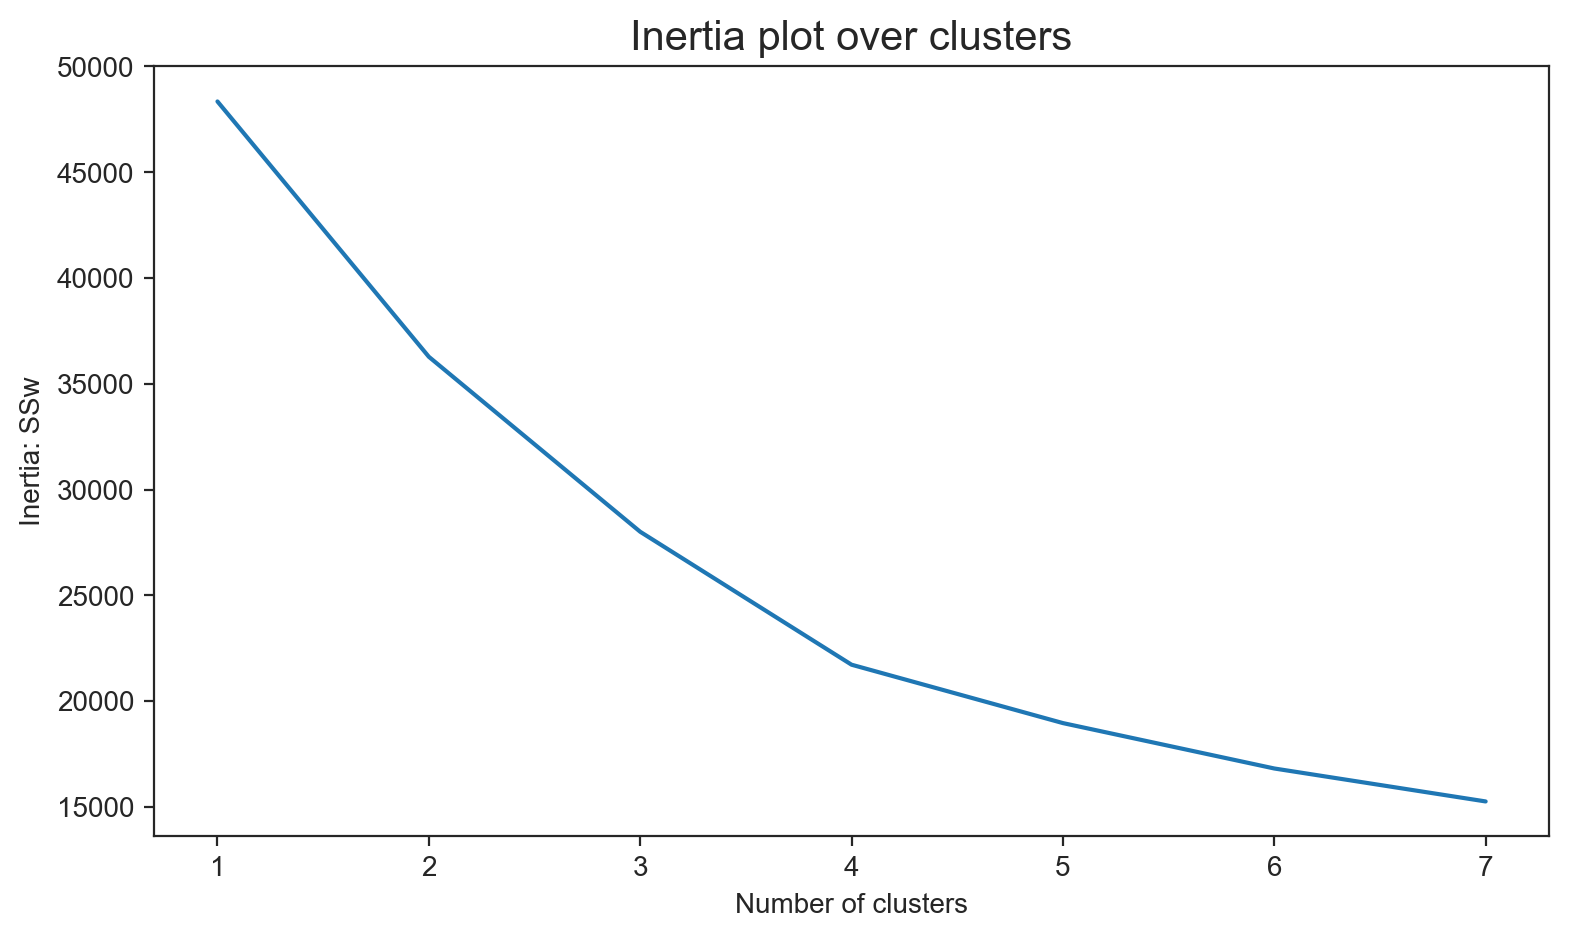

In [105]:
# The inertia plot

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters, inertia)
ax.set_xticks(range_clusters)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

For n_clusters = 2, the average silhouette_score is : 0.2550734830245549
For n_clusters = 3, the average silhouette_score is : 0.2667992072247818
For n_clusters = 4, the average silhouette_score is : 0.28341279818124326
For n_clusters = 5, the average silhouette_score is : 0.27407997944840556
For n_clusters = 6, the average silhouette_score is : 0.26550607688338523
For n_clusters = 7, the average silhouette_score is : 0.25053978491133005


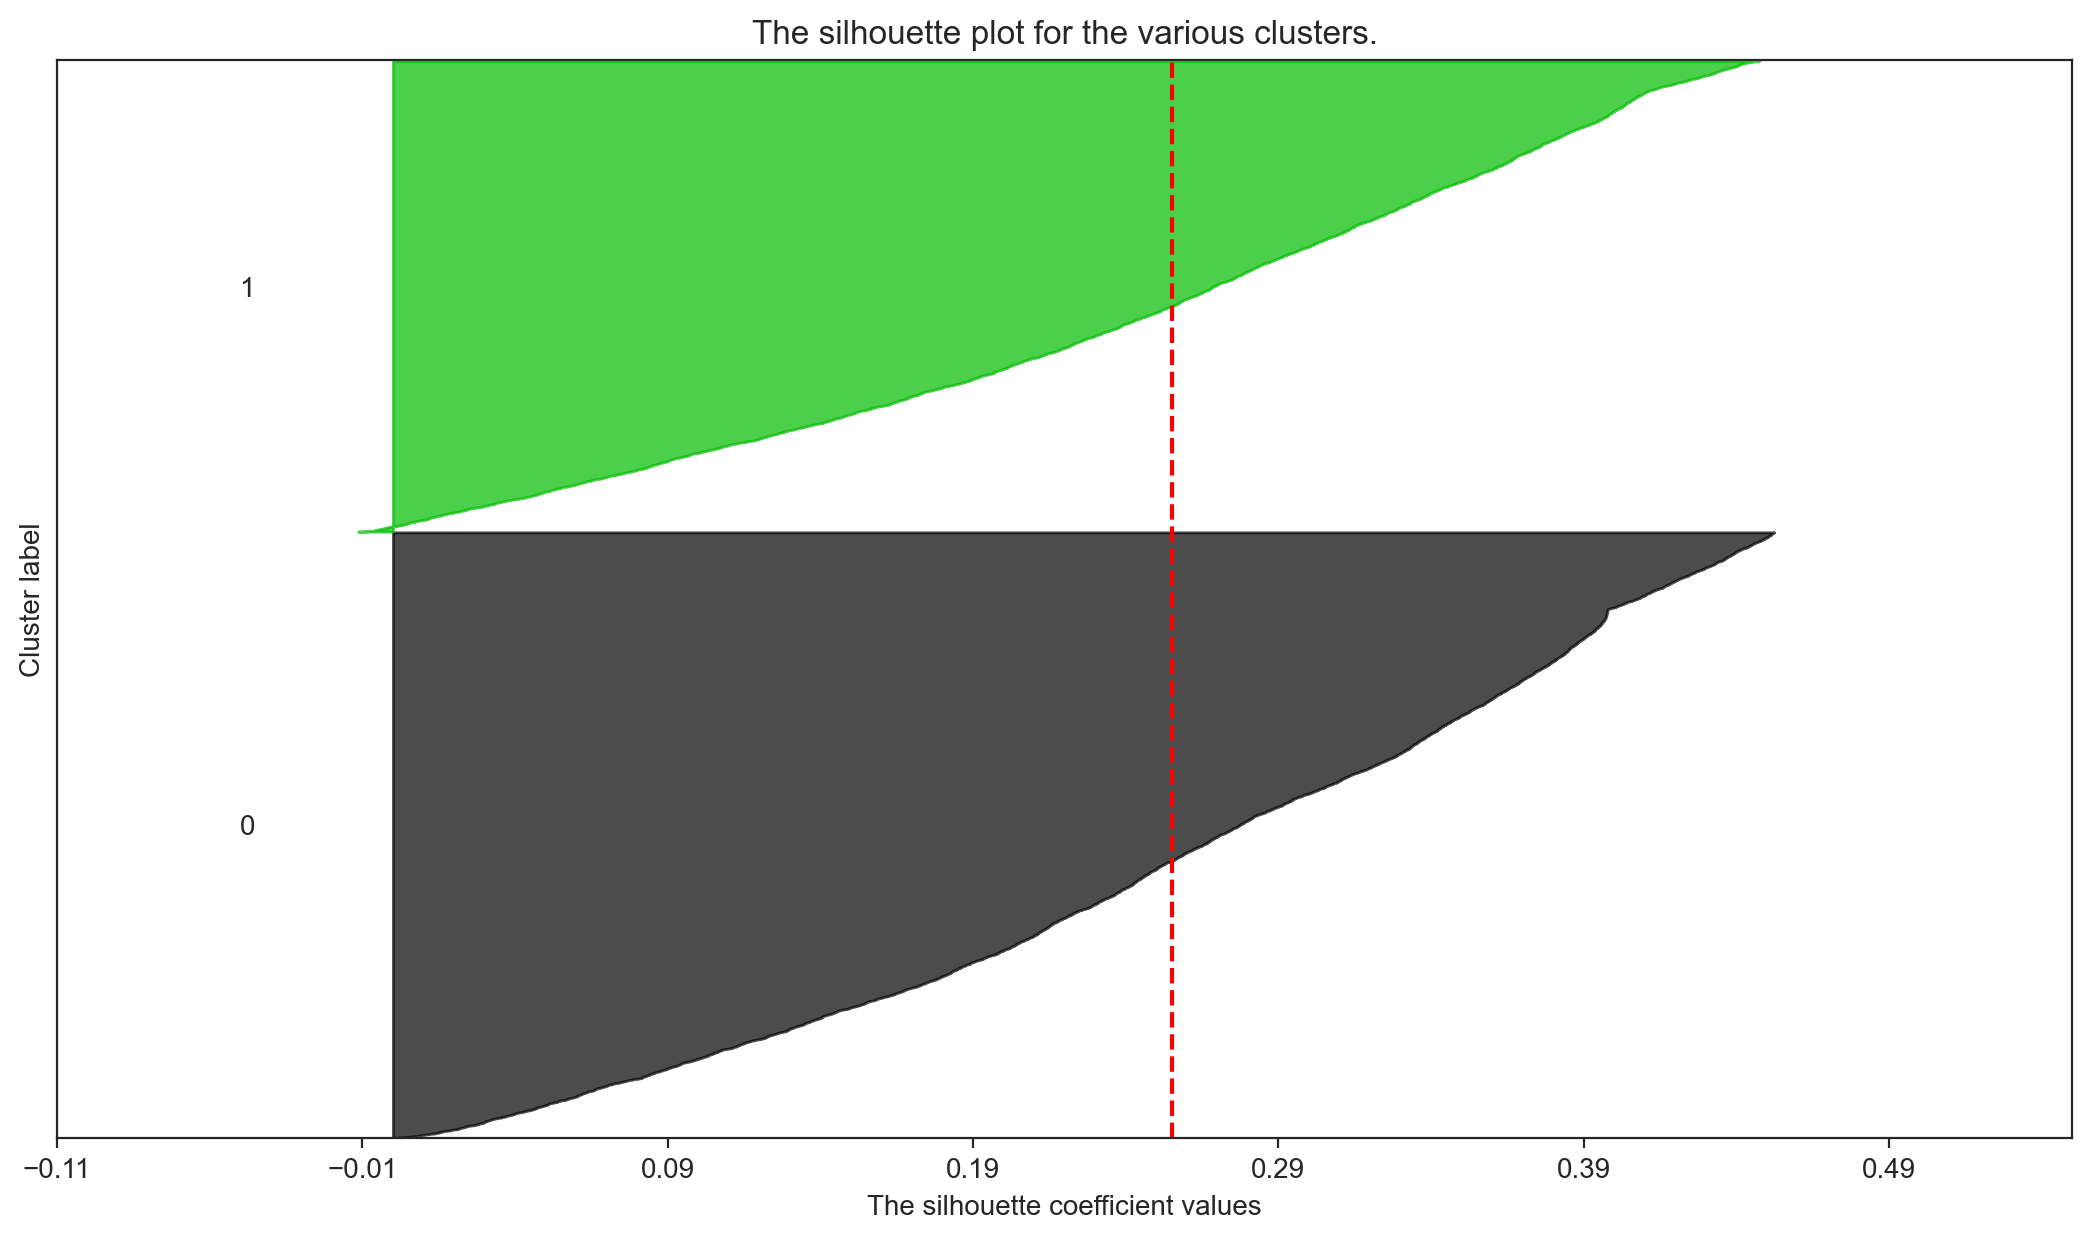

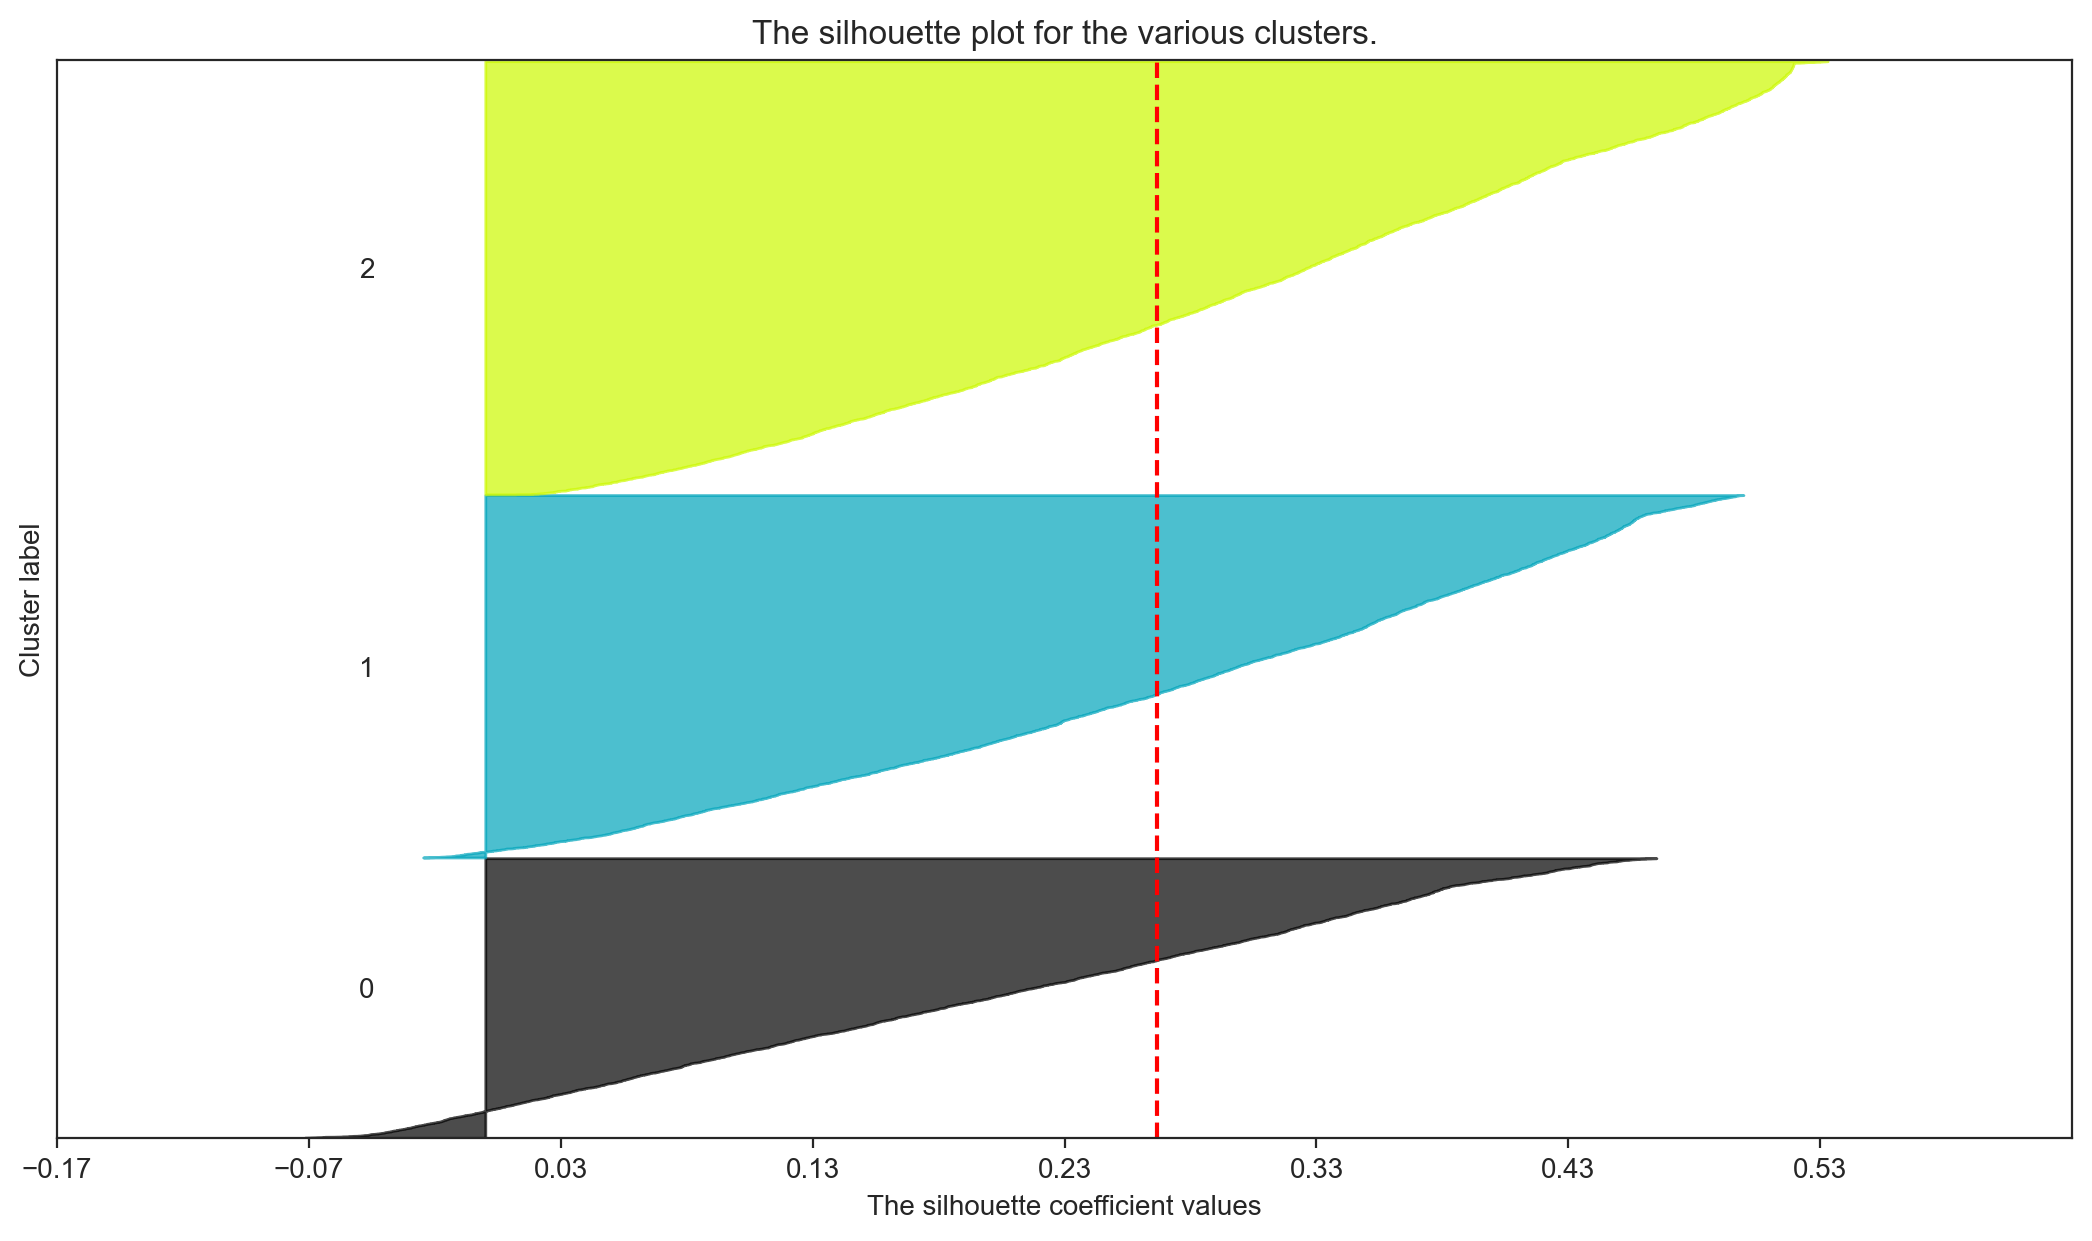

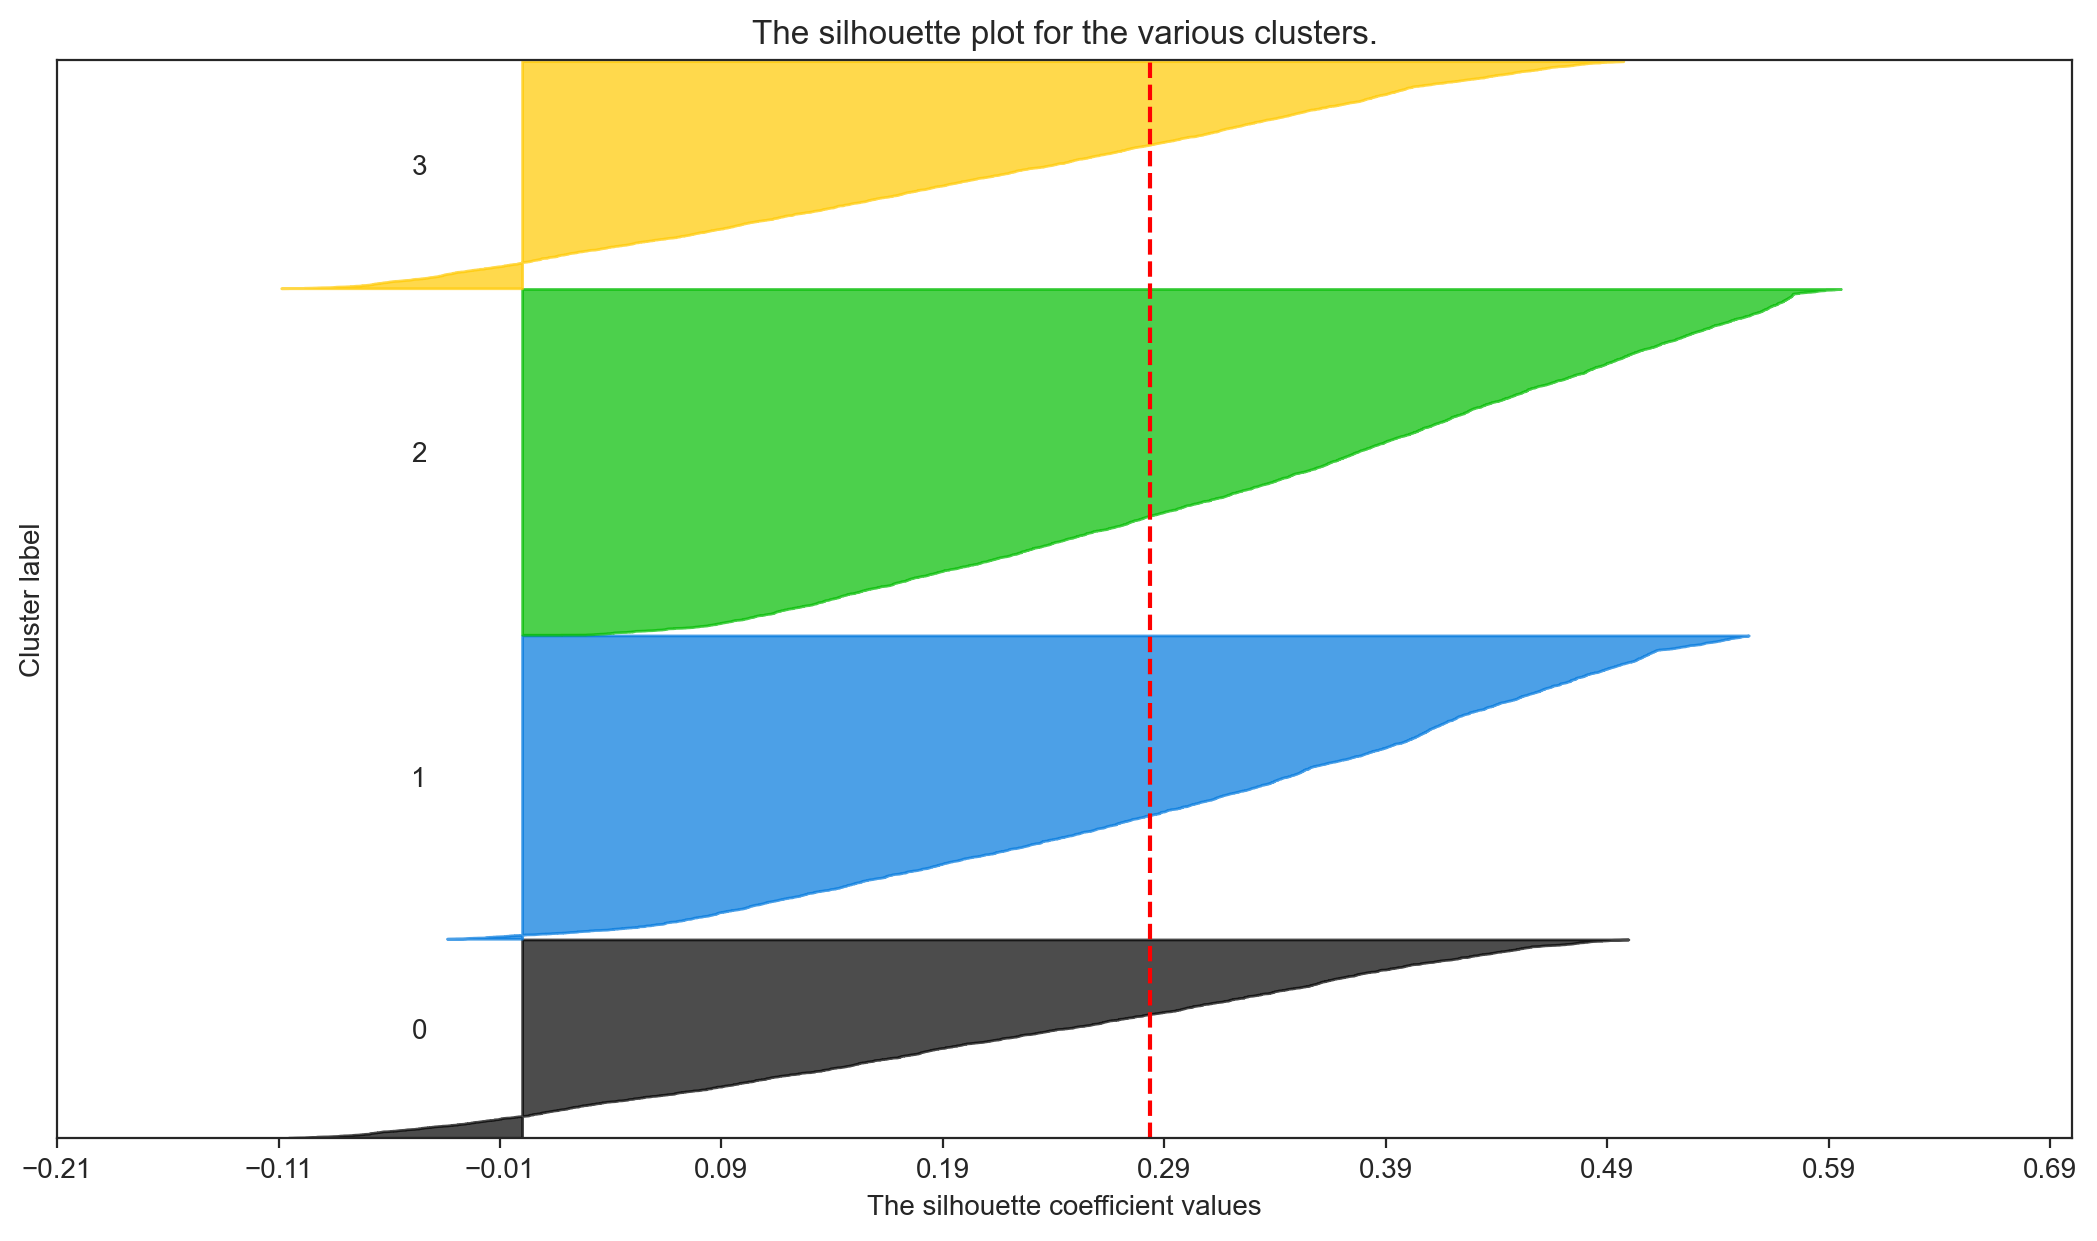

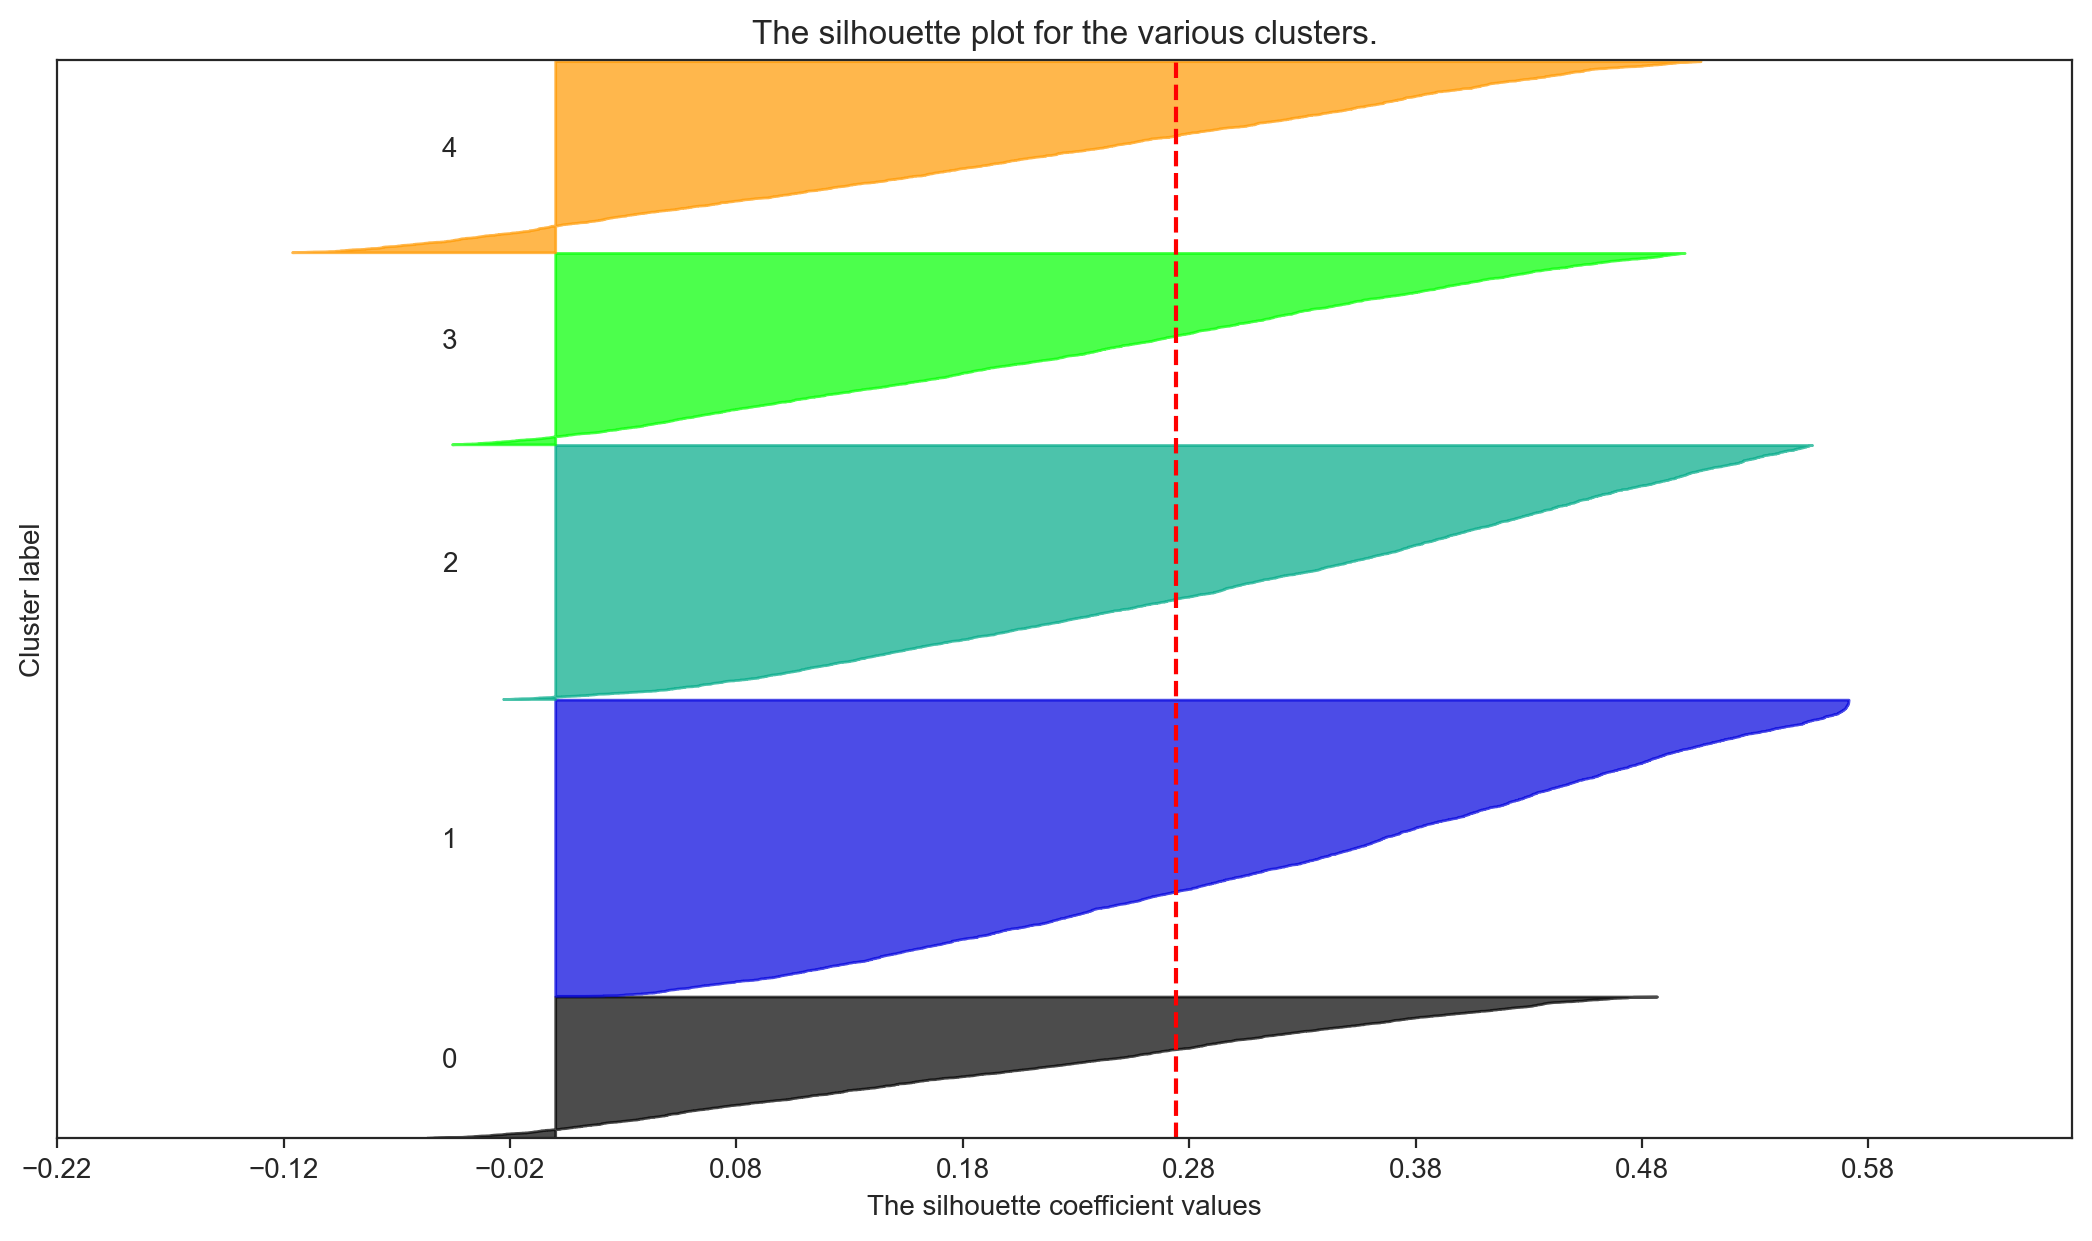

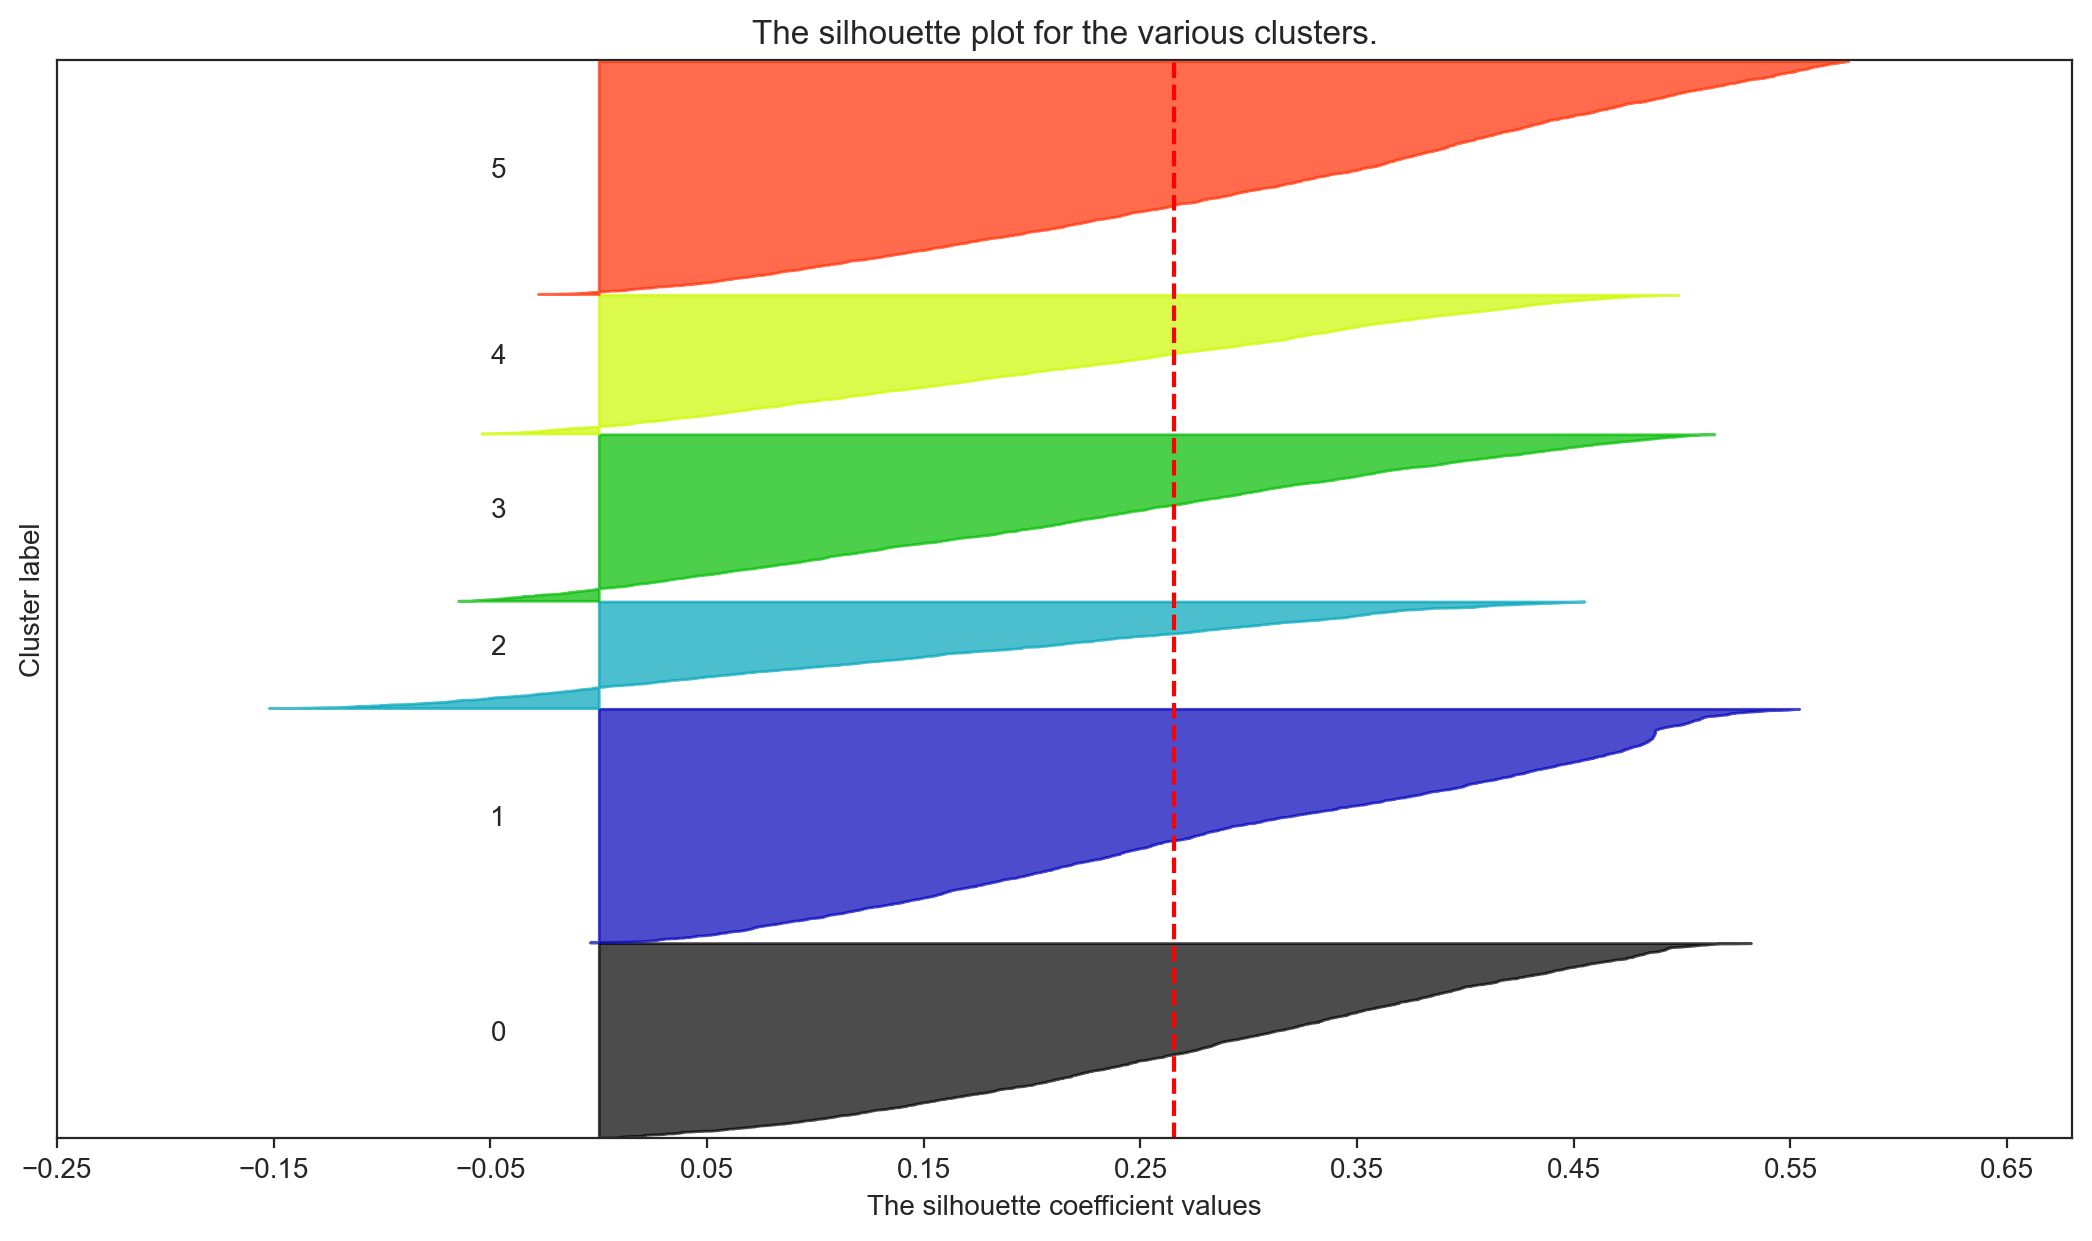

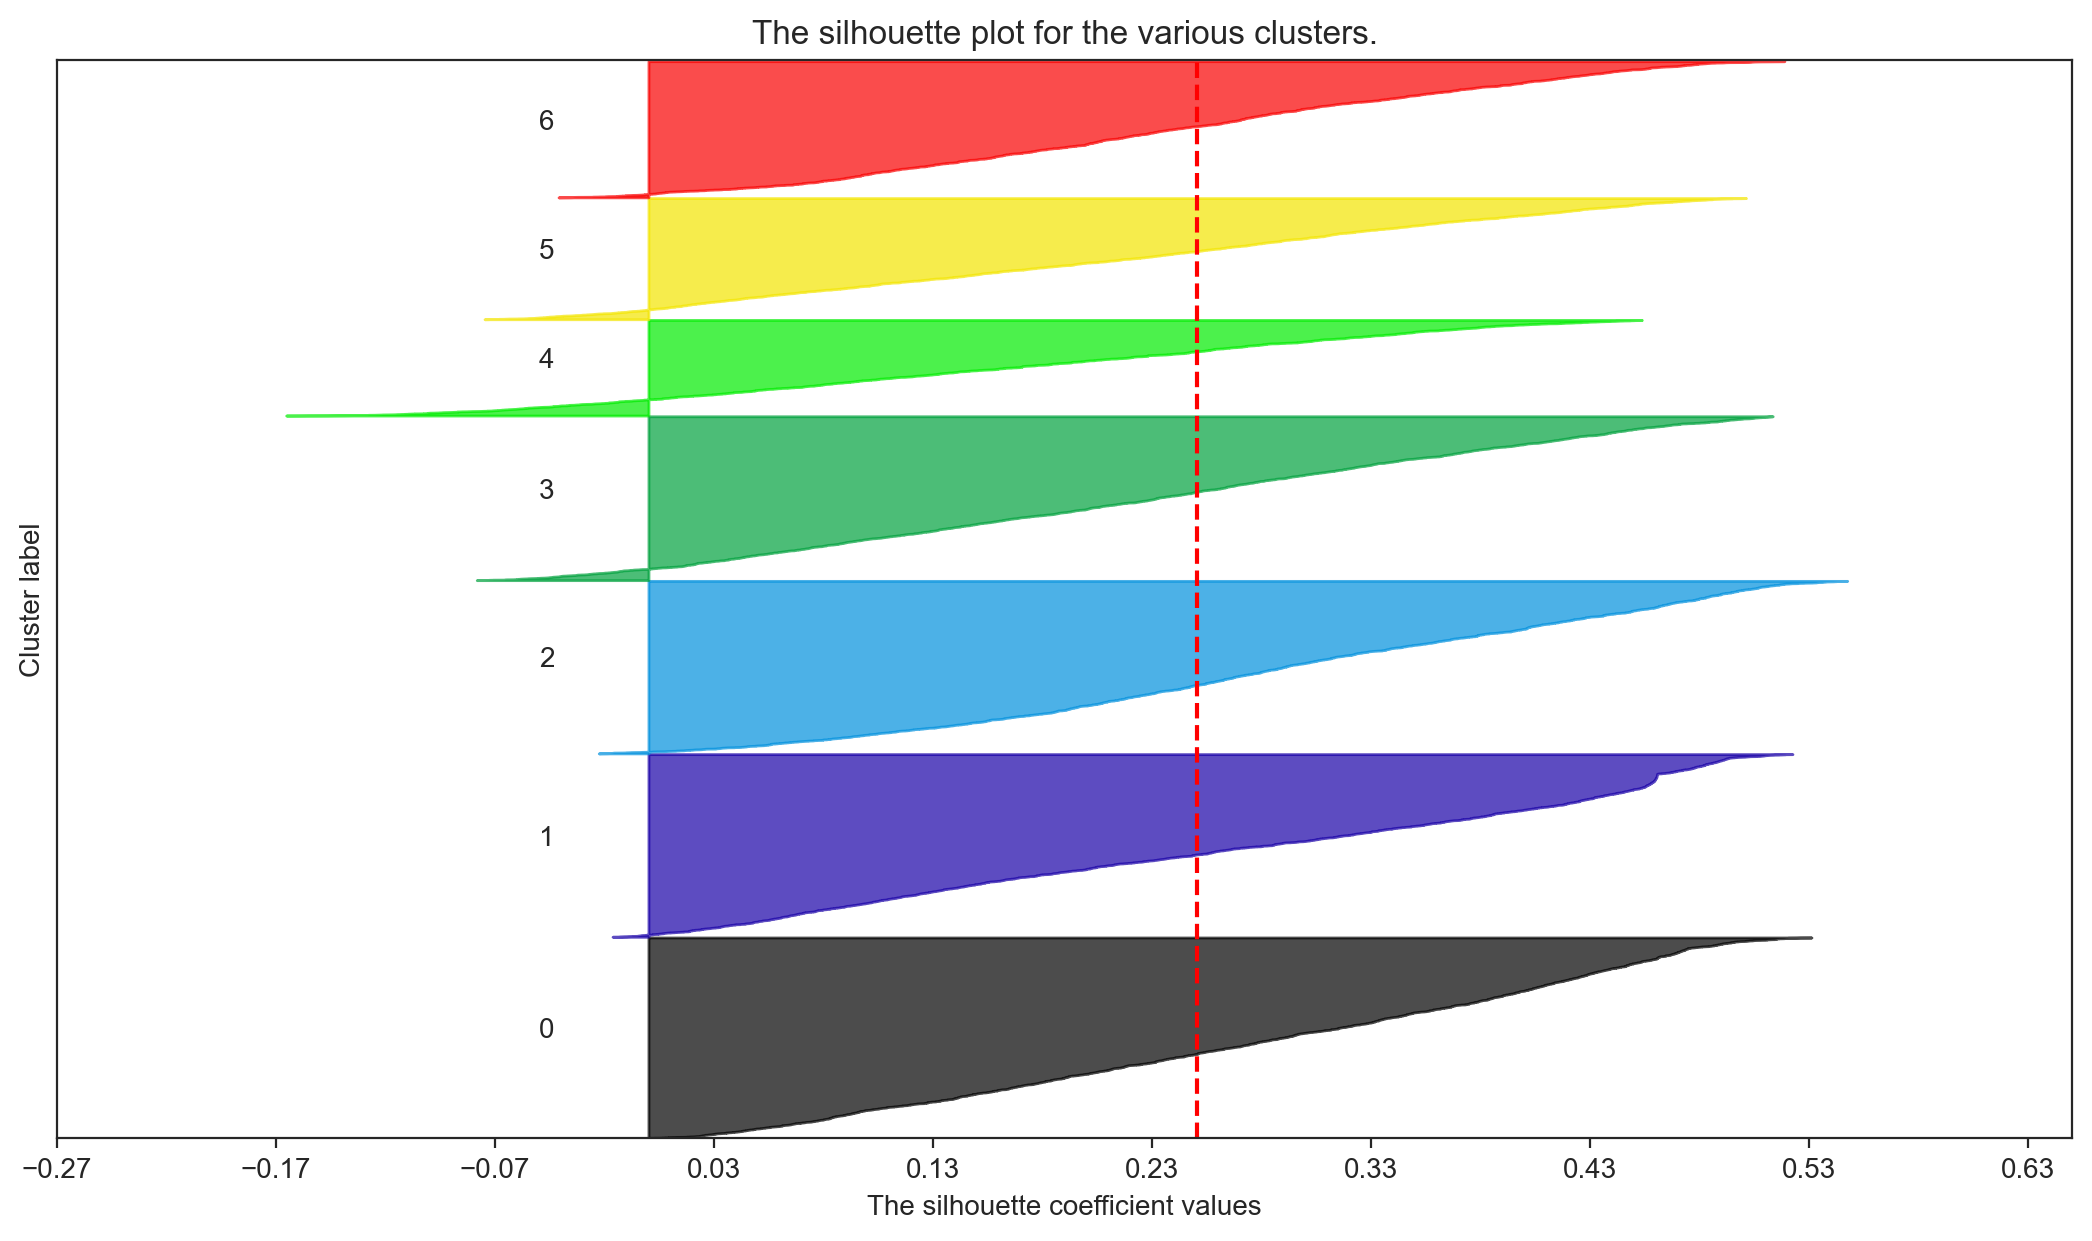

In [106]:
# Storing average silhouette metric
avg_silhouette = []
for nclus in range_clusters:
    # Skip nclus == 1
    if nclus == 1:
        continue
    
    # Create a figure
    fig = plt.figure(figsize=(13, 7))

    # Initialize the KMeans object with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    kmclust = KMeans(n_clusters=nclus, init='k-means++', n_init=15, random_state=1)
    cluster_labels = kmclust.fit_predict(df_E)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(df_E, cluster_labels)
    avg_silhouette.append(silhouette_avg)
    print(f"For n_clusters = {nclus}, the average silhouette_score is : {silhouette_avg}")

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(df_E, cluster_labels)

    y_lower = 10
    for i in range(nclus):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        # Get y_upper to demarcate silhouette y range size
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        # Filling the silhouette
        color = cm.nipy_spectral(float(i) / nclus)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    plt.title("The silhouette plot for the various clusters.")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    
    # The silhouette coefficient can range from -1, 1
    xmin, xmax = np.round(sample_silhouette_values.min() -0.1, 2), np.round(sample_silhouette_values.max() + 0.1, 2)
    plt.xlim([xmin, xmax])
    
    # The (nclus+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    plt.ylim([0, len(df_E) + (nclus + 1) * 10])

    plt.yticks([])  # Clear the yaxis labels / ticks
    plt.xticks(np.arange(xmin, xmax, 0.1))

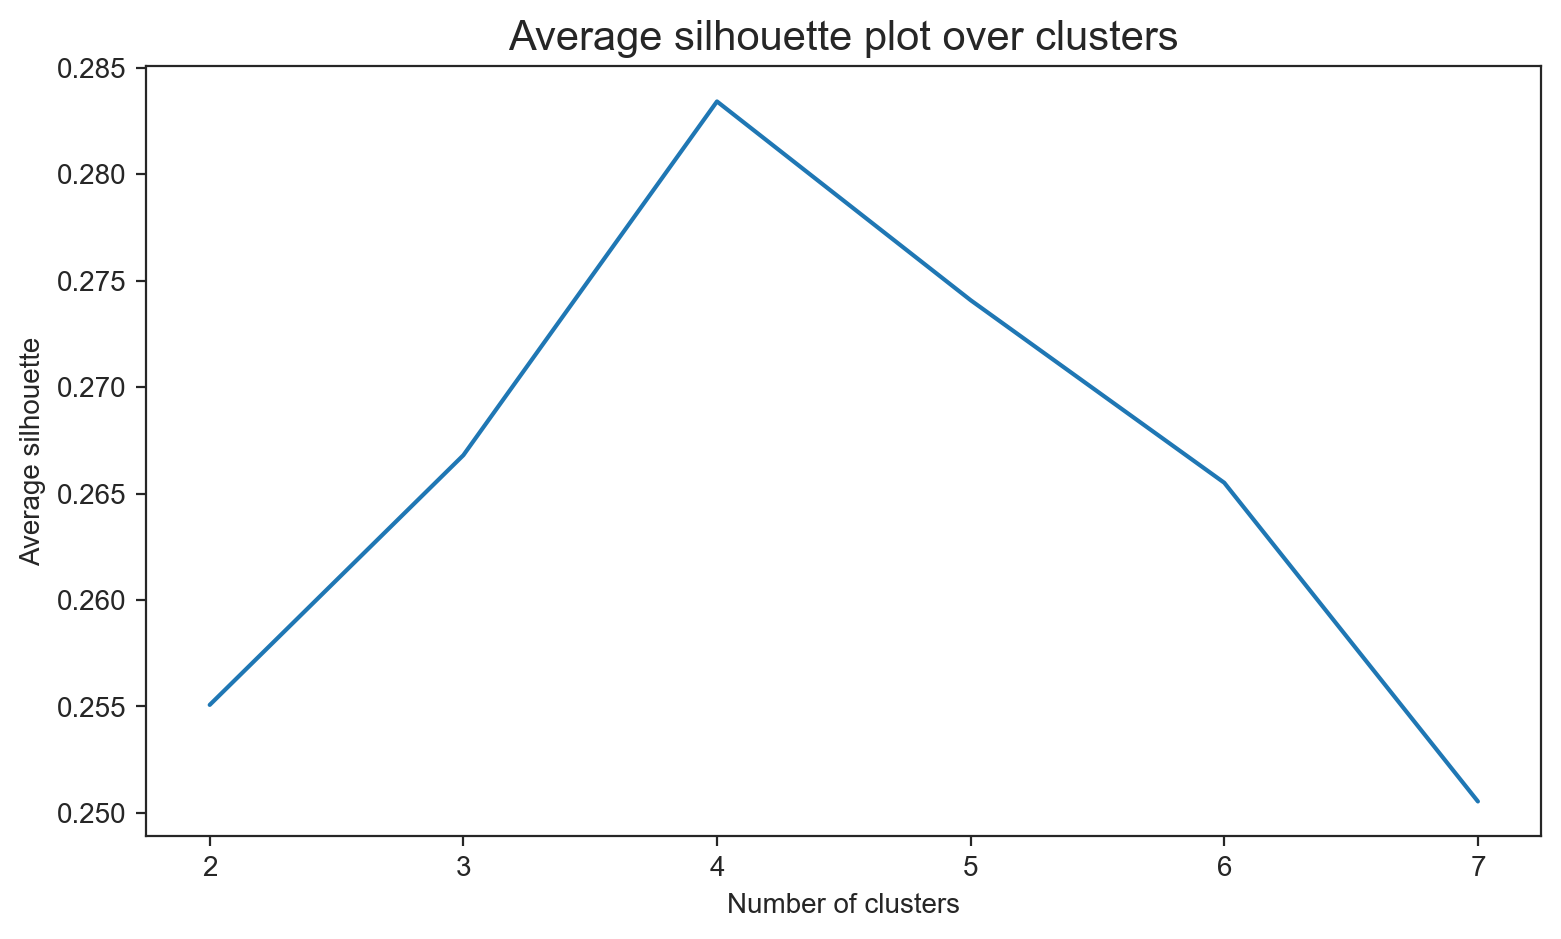

In [107]:
# The average silhouette plot
# The inertia plot
plt.figure(figsize=(9,5))


#  Why range_clusters[1:] ? 
# Remember we skipped k=1 in the cell above

plt.plot(range_clusters[1:], ## Plot X-axis; 
         avg_silhouette)     ## Plot Y-axis

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters", size=15)
plt.show()

The optimal number of clusters was determined by jointly analyzing the inertia (elbow method) and the average silhouette score. The inertia curve shows a clear inflection point at k=4, after which additional clusters lead to marginal reductions in within-cluster variance. Consistently, the silhouette score reaches its maximum at k=4, indicating the best balance between cluster cohesion and separation. Beyond this value, silhouette scores decrease, suggesting over-segmentation. Therefore, k=4 was selected as the most appropriate solution, also supported by the emergence of a distinct and interpretable customer segment.

In [108]:
# final cluster solution
number_clusters = 4
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels = kmclust.fit_predict(df_E)
km_labels

array([1, 3, 2, ..., 0, 0, 0], dtype=int32)

In [109]:
# Characterizing the final clusters
df_concat = pd.concat((df_E, pd.Series(km_labels, name='labels', index=df_E.index)), axis=1)
df_concat.groupby('labels').mean()

,Income,Customer_Lifetime_Value_log,PointsEfficiency
labels,,,
0,-0.164666,1.479310,-0.225547
1,1.121017,-0.222473,-0.362791
2,-0.772035,-0.515478,-0.511079
3,-0.177878,-0.210115,1.459716


In [110]:
cluster_sizes = df_concat['labels'].value_counts().sort_index()

cluster_sizes_pct = (
    df_concat['labels']
    .value_counts(normalize=True)
    .sort_index() * 100
)

cluster_distribution = pd.DataFrame({
    'Count': cluster_sizes,
    'Percentage (%)': cluster_sizes_pct.round(2)
})

cluster_distribution

,Count,Percentage (%)
labels,,
0,2975,18.46
1,4549,28.23
2,5186,32.18
3,3406,21.13


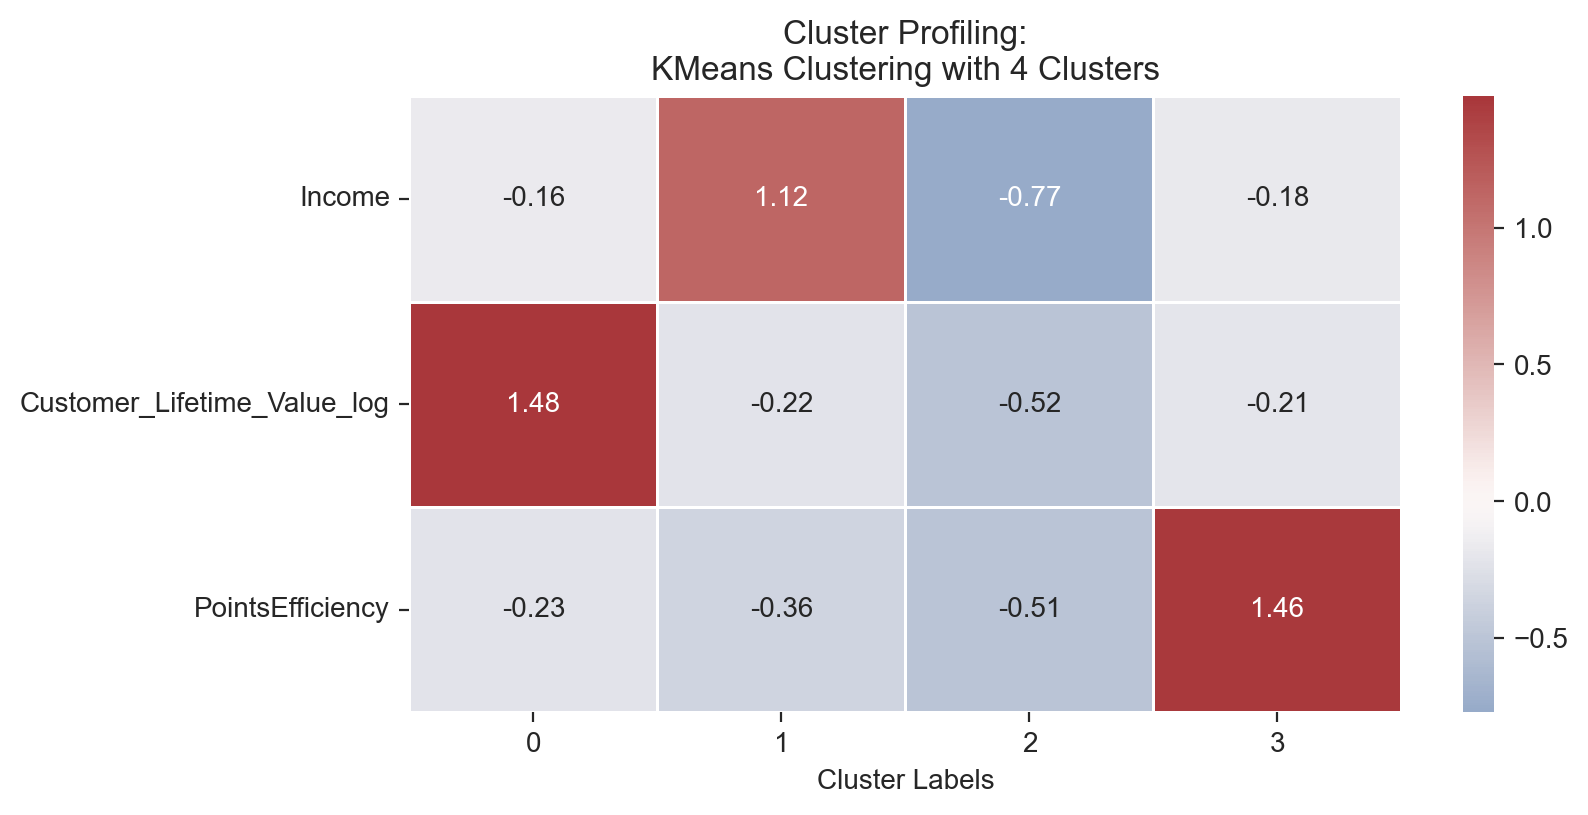

In [111]:
fig, ax = plt.subplots(figsize=(8,4))

km_profile = df_concat.groupby('labels').mean().T

sns.heatmap(km_profile,
            
            ax=ax,
            annot = True,
            fmt = '.2f',
            cmap = 'vlag',
            center=0,
            linewidths=0.4
            )

ax.set_xlabel("Cluster Labels")
ax.set_title(f"Cluster Profiling:\nKMeans Clustering with {number_clusters} Clusters")
plt.show()

Cluster 0 (18,46%) — High CLV / Not High Income / Low Efficiency - “High-Value Loyalists (CLV-driven)”<br>

Cluster 1 (28,23%) — High Income / Low Efficiency / Average-Low CLV — “Affluent but Under-engaged”<br>

Cluster 2 (32,18%) — Low Income / Low CLV / Low Efficiency — “Low-Value / Early-Stage (incl. students)”<br>

Cluster 3 (21,13%) — Points Efficient / Average-Low Income & CLV - C3 – “Points Maximizers”<br>

Cluster 0 (18.46% of customers) is primarily characterized by a markedly high Customer Lifetime Value, with an average CLV_log approximately 1.5 standard deviations above the global mean. In contrast, both Income and Points Efficiency are slightly below average. This segment represents customers who generate substantial long-term value for the company despite not belonging to the highest income bracket or exhibiting particularly efficient points usage. Such a profile is indicative of sustained loyalty and consistent engagement over time, making this group strategically important from a retention and relationship management perspective.

Cluster 1 (28.23%) exhibits a contrasting pattern, with Income significantly above the global mean (over one standard deviation), while CLV_log and Points Efficiency remain slightly below average. This suggests a segment of economically affluent customers whose financial capacity does not fully translate into proportional lifetime value or effective engagement with the loyalty program. From a business standpoint, this cluster may represent under-leveraged potential, where targeted incentives or tailored loyalty strategies could enhance long-term value extraction.

Cluster 2 (32.18%), the largest segment, shows consistently below-average values across all three variables, particularly Income and Customer Lifetime Value. This cluster corresponds to a low economic contribution and low engagement profile, likely encompassing early-stage customers or individuals with limited purchasing power, such as students or customers with zero or very low reported income. While not a priority for high-value strategies, this segment is relevant for understanding the baseline customer population and for designing low-cost, scalable engagement approaches.

Cluster 3 (21.13%) is clearly distinguished by very high Points Efficiency, exceeding the global mean by more than one standard deviation, while both Income and CLV_log remain slightly below average. This pattern indicates customers who are particularly effective at accumulating and redeeming loyalty points, despite not yet translating this behavior into high lifetime value. This segment may reflect optimization-oriented or deal-seeking behavior and represents a potential opportunity for conversion into higher-value customers through mechanisms that encourage increased spending or longer-term commitment.

Overall, the four-cluster solution reveals economically interpretable and behaviorally distinct customer segments. The standardized profiling highlights clear trade-offs between income level, accumulated value, and loyalty program efficiency, supporting the selection of four clusters as a balanced and meaningful segmentation for downstream strategic analysis.

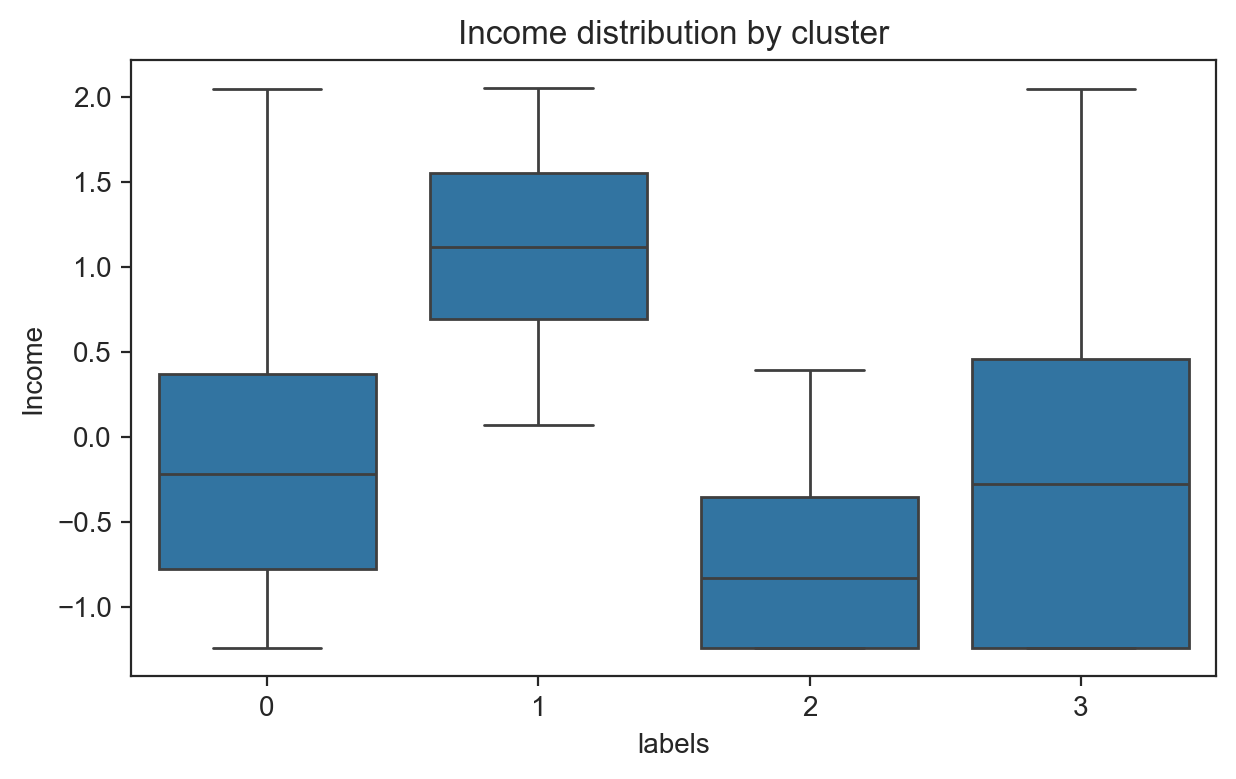

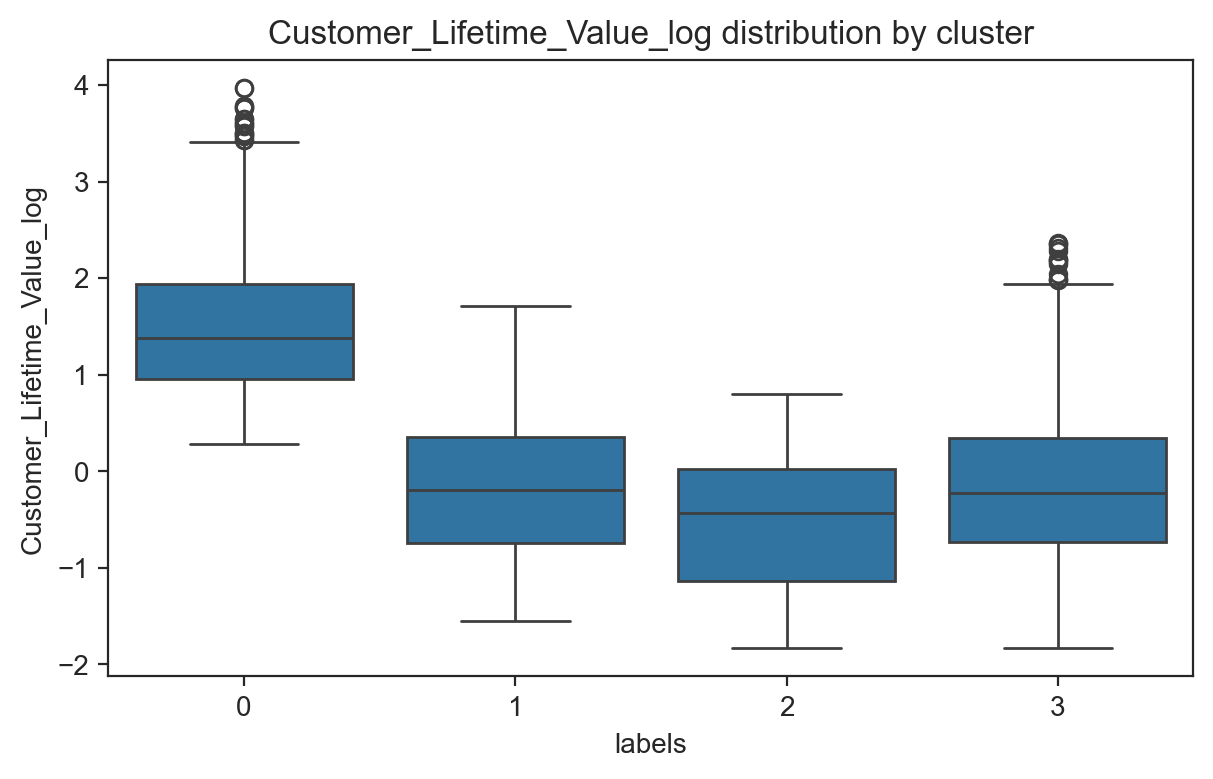

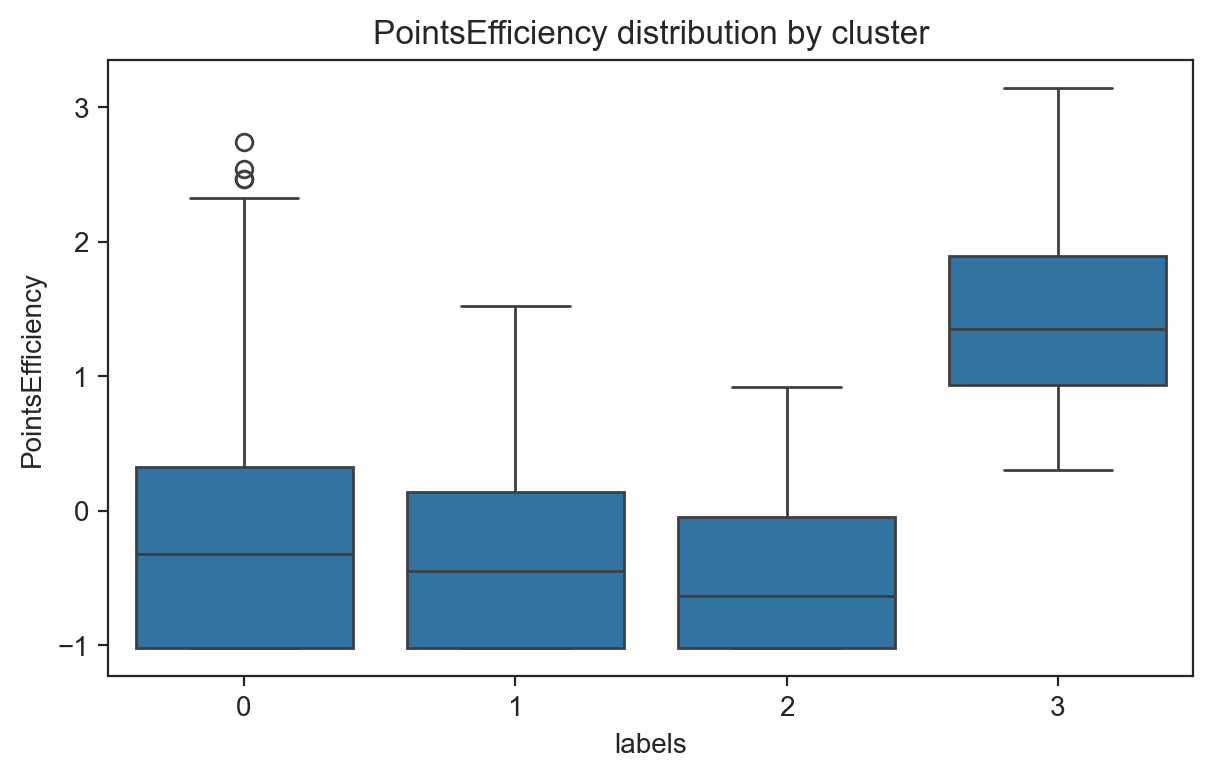

In [112]:
vars_ = ['Income', 'Customer_Lifetime_Value_log', 'PointsEfficiency']

for v in vars_:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df_concat, x='labels', y=v)
    plt.title(f'{v} distribution by cluster')
    plt.show()

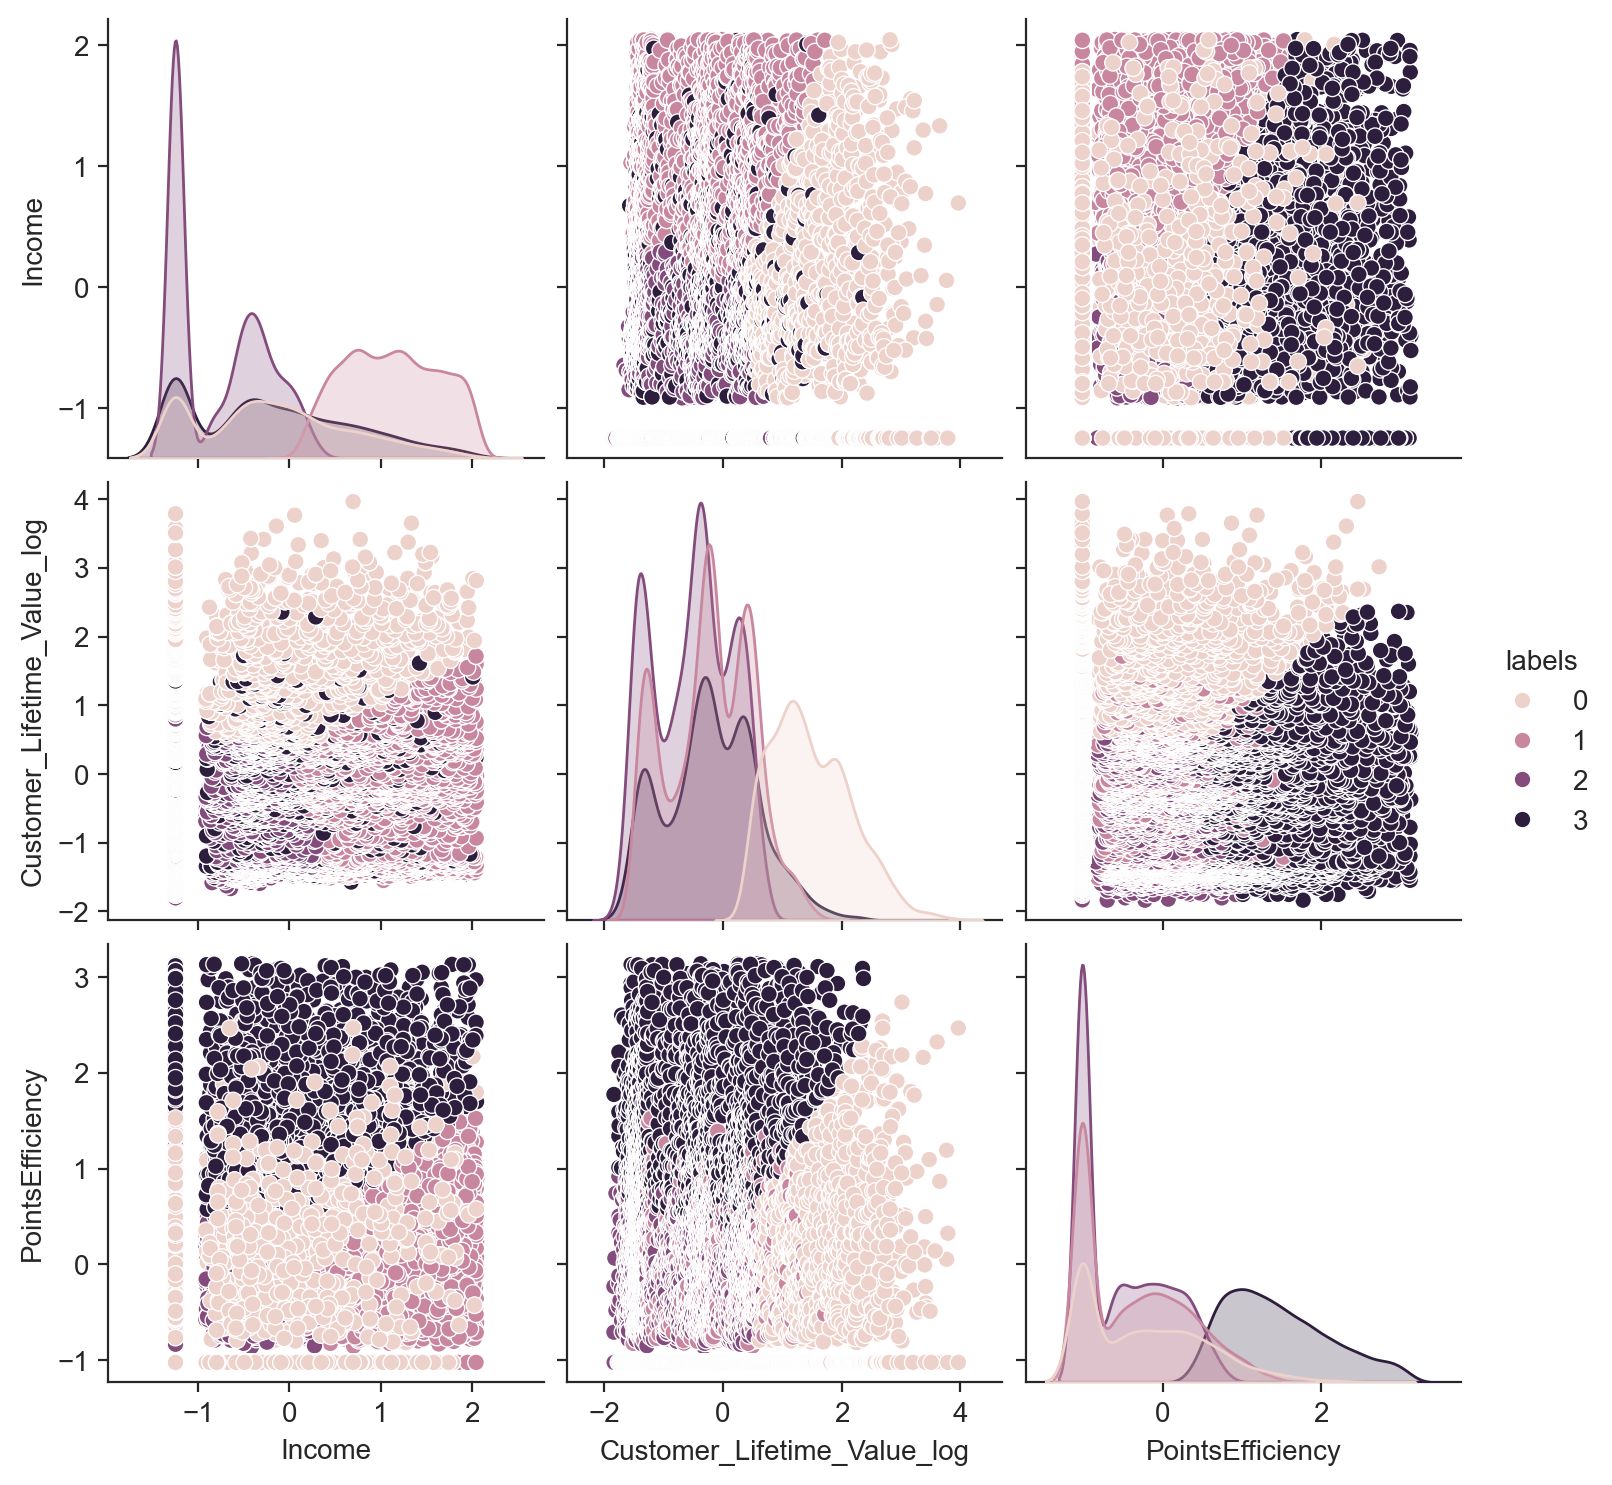

In [113]:
sns.pairplot(df_concat, vars=['Income','Customer_Lifetime_Value_log','PointsEfficiency'], hue='labels', diag_kind='kde')


Overall, the distributional and multivariate visualizations corroborate the earlier profiling based on standardized means. They demonstrate that the four-cluster solution captures not only differences in central tendency but also meaningful differences in dispersion, overlap, and joint variable behavior. This strengthens the validity of the segmentation and confirms that each cluster represents a distinct and interpretable customer archetype rather than an artifact of averaging or scaling.

# Gaussian Mixture Models (GMM) 

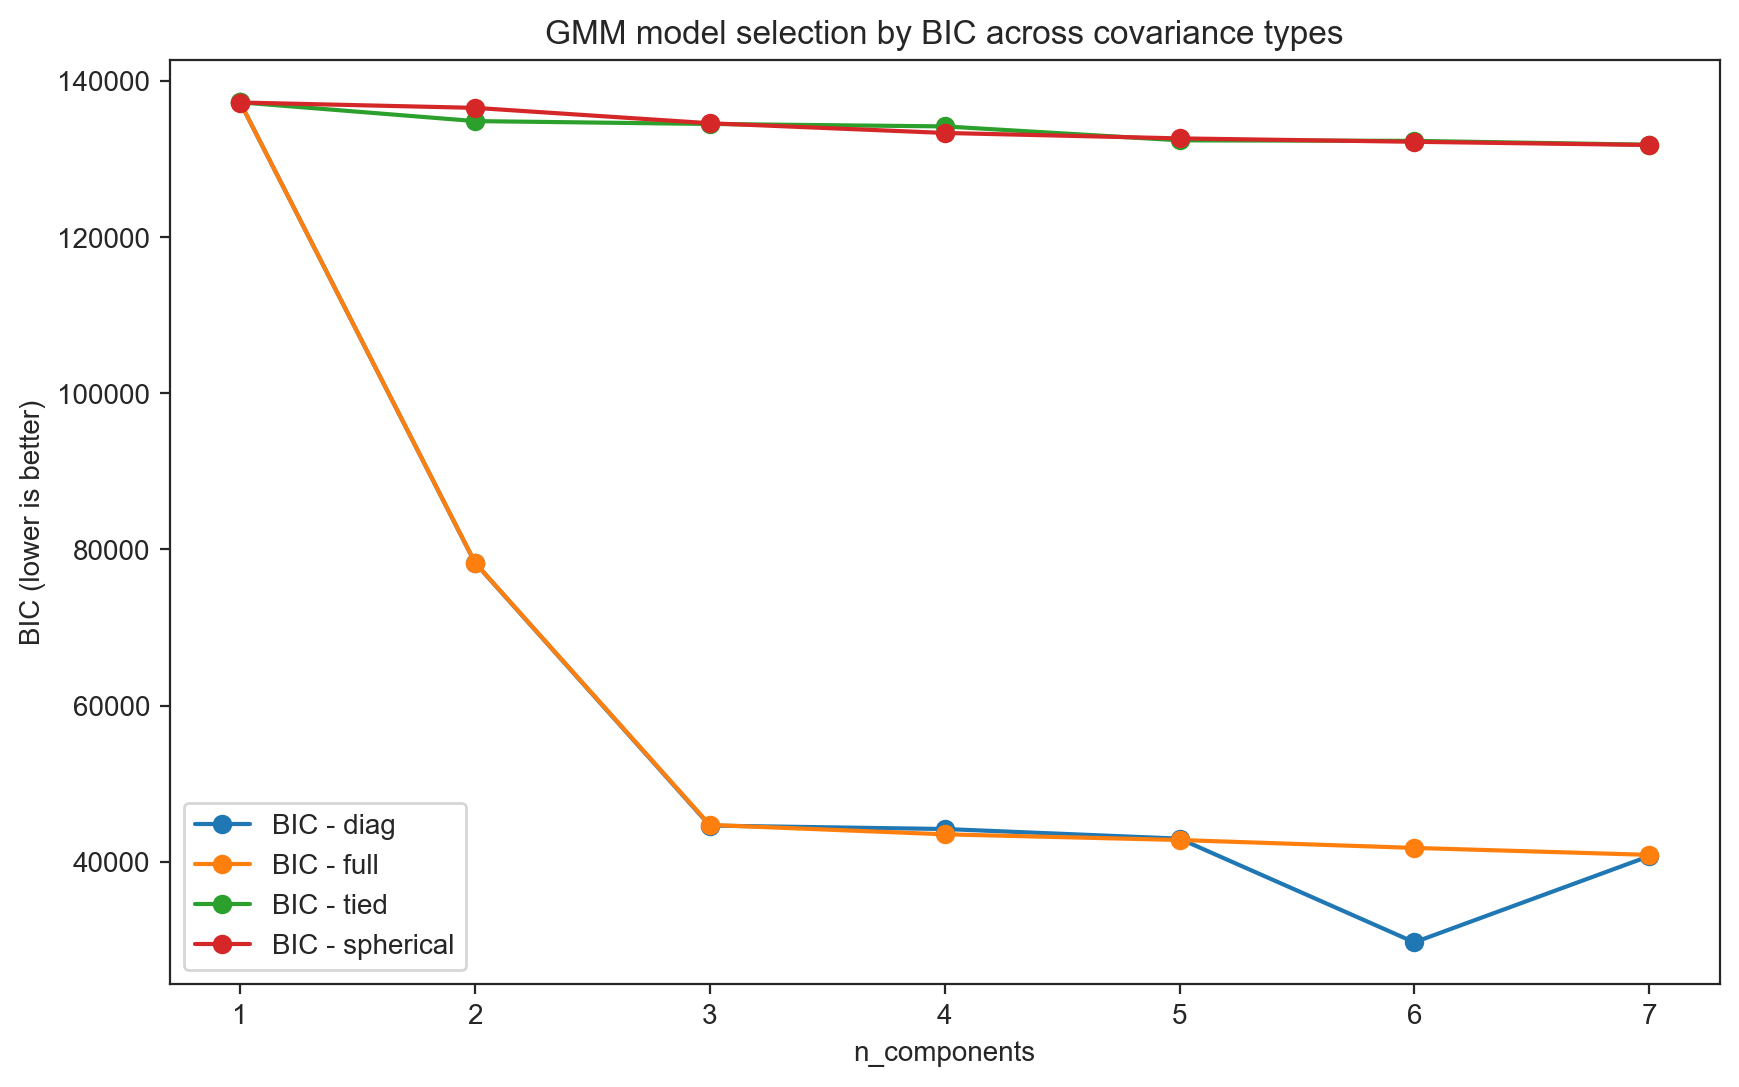

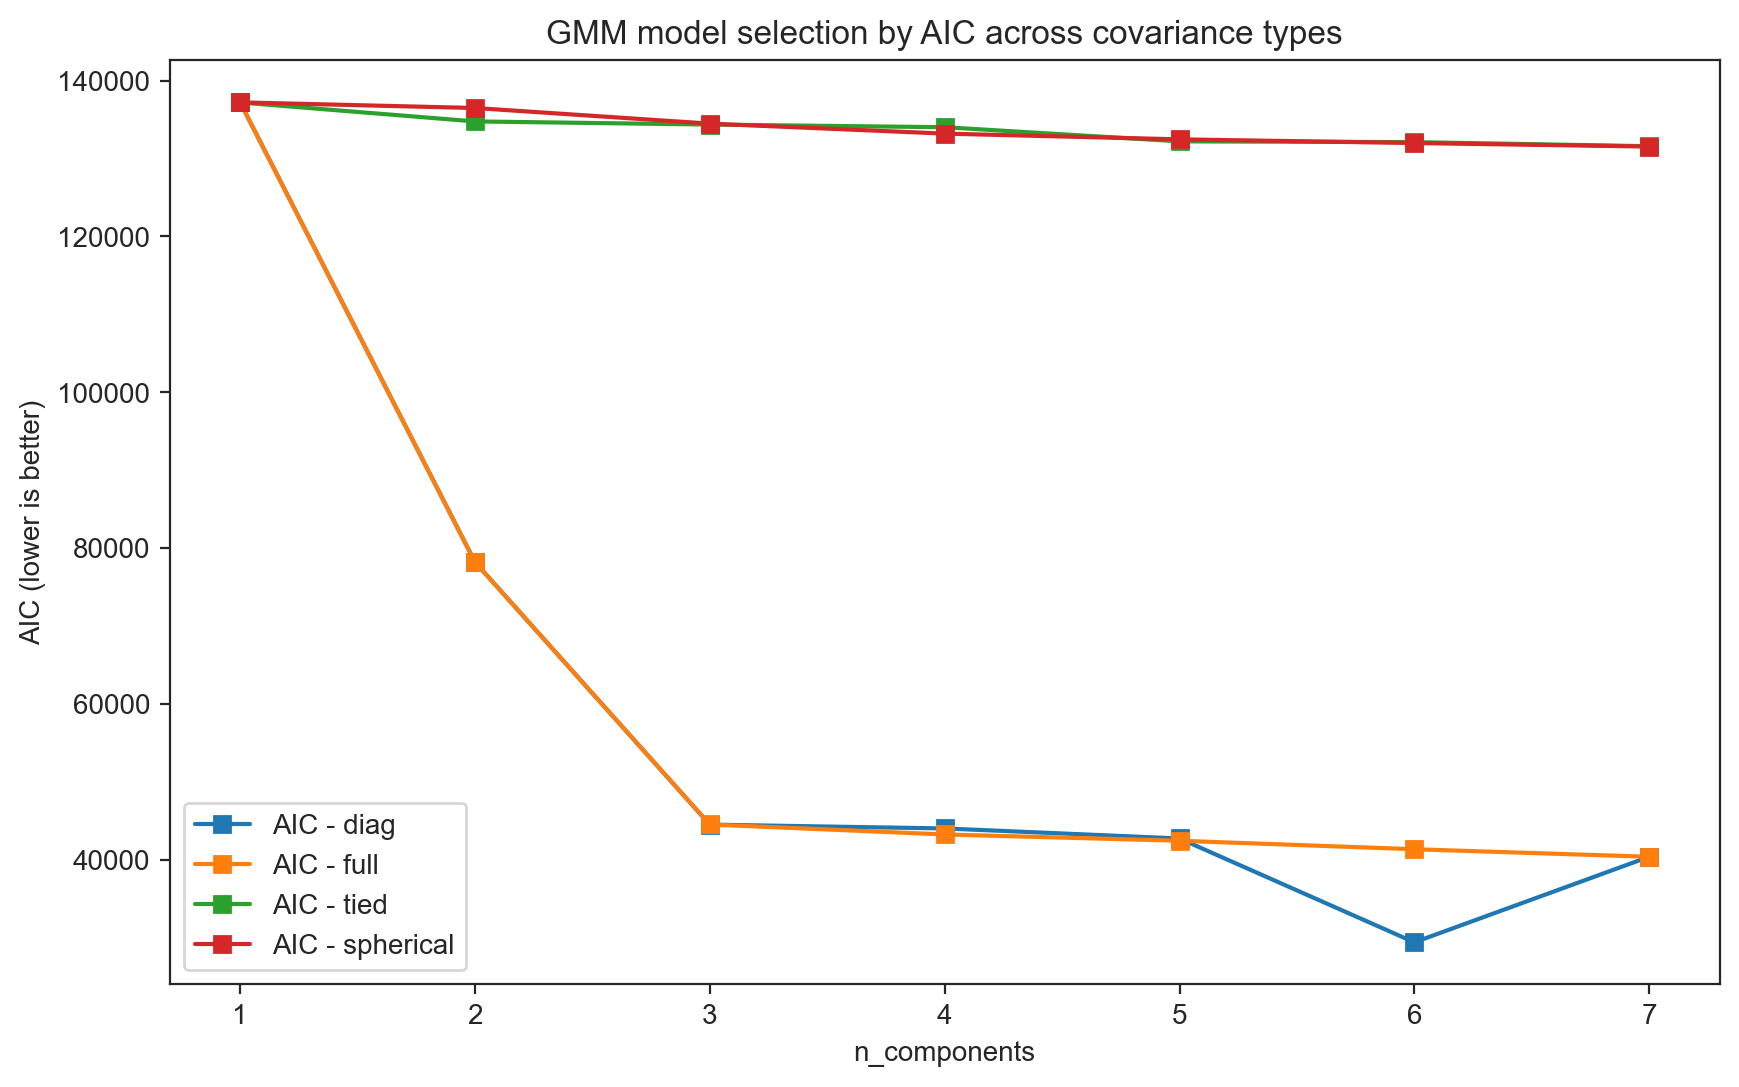

In [114]:
# ---------------------------------------------------------------------
# 1) Define X explicitly (so you never accidentally include extra cols)
# ---------------------------------------------------------------------
clust_features = ['Income', 'Customer_Lifetime_Value_log', 'PointsEfficiency']
X = df_final[clust_features].copy() 

# ---------------------------------------------------------------------
# 2) Grid search over n_components and covariance_type
# ---------------------------------------------------------------------
n_components_grid = range(1, 8)  # 1..8
cov_types = ['diag', 'full', 'tied', 'spherical']

results = []
models = {}  # store fitted models if you want to reuse best later

for cov in cov_types:
    for k in n_components_grid:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            n_init=10,
            random_state=1
        )
        gmm.fit(X)

        bic = gmm.bic(X)
        aic = gmm.aic(X)

        results.append({
            "covariance_type": cov,
            "n_components": k,
            "BIC": bic,
            "AIC": aic
        })
        models[(cov, k)] = gmm

res_df = pd.DataFrame(results).sort_values(["BIC", "AIC"]).reset_index(drop=True)

# ---------------------------------------------------------------------
# 4) Plot BIC/AIC curves per covariance type
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 6))
for cov in cov_types:
    sub = res_df[res_df["covariance_type"] == cov].sort_values("n_components")
    plt.plot(sub["n_components"], sub["BIC"], marker='o', label=f"BIC - {cov}")
plt.xticks(list(n_components_grid))
plt.xlabel("n_components")
plt.ylabel("BIC (lower is better)")
plt.title("GMM model selection by BIC across covariance types")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for cov in cov_types:
    sub = res_df[res_df["covariance_type"] == cov].sort_values("n_components")
    plt.plot(sub["n_components"], sub["AIC"], marker='s', label=f"AIC - {cov}")
plt.xticks(list(n_components_grid))
plt.xlabel("n_components")
plt.ylabel("AIC (lower is better)")
plt.title("GMM model selection by AIC across covariance types")
plt.legend()
plt.show()

In [115]:
# Performing GMM clustering
gmm = GaussianMixture(n_components=4, covariance_type='full', n_init=10, init_params='kmeans', random_state=1)

gmm_labels = gmm.fit_predict(df_E)

In [116]:
# Concatenating the labels to df
df_concat = pd.concat([df_E, pd.Series(gmm_labels, index=df_E.index, name="gmm_labels")], axis=1)

df_concat['gmm_labels'].value_counts().sort_index()

gmm_labels
0    2335
1    3893
2    5858
3    4030
Name: count, dtype: int64

In [117]:
# Helper function from previous labs
def get_ss(df, features):
    """Calculate total sum of squares (SST)"""
    return np.sum(df[features].var() * (df[features].count() - 1))

def get_ssw(df, features, labels):
    """Calculate within-cluster sum of squares (SSW)"""
    df_temp = df[features].copy()
    df_temp['labels'] = labels
    return df_temp.groupby('labels')[features].apply(lambda x: get_ss(x, features)).sum()

def get_rsq(df, features, labels):
    """Calculate R² for clustering quality"""
    sst = get_ss(df, features)
    ssw = get_ssw(df, features, labels)
    return 1 - (ssw / sst)

r2_gmm = get_rsq(df_E, clust_features, gmm_labels)
print(f"GMM R² score: {r2_gmm:.4f}")

GMM R² score: 0.3792


~38% of the variance is explained by the segmentation

In [118]:
gmm.covariances_.shape

(4, 3, 3)

In [119]:
probabilities = gmm.predict_proba(df_E)
probabilities

array([[1.43221803e-02, 0.00000000e+00, 9.85677820e-01, 0.00000000e+00],
       [8.89835260e-05, 0.00000000e+00, 1.98036225e-04, 9.99712980e-01],
       [6.88880805e-06, 0.00000000e+00, 5.19986649e-04, 9.99473125e-01],
       ...,
       [3.30186354e-03, 0.00000000e+00, 6.26860333e-07, 9.96697510e-01],
       [9.99999341e-01, 0.00000000e+00, 6.59491094e-07, 0.00000000e+00],
       [1.09009509e-02, 9.89097232e-01, 1.81704202e-06, 0.00000000e+00]])

In [120]:
max_probs = probabilities.max(axis=1)

uncertain_threshold = 0.7

certain_customers = df_E[max_probs >= uncertain_threshold]
uncertain_customers = df_E[max_probs < uncertain_threshold]

print(f"GMM Probability Analysis:")
print(f"- Clear assignments (≥70% probability): {len(certain_customers):,} customers")
print(f"- Uncertain assignments (<70% probability): {len(uncertain_customers):,} customers ({len(uncertain_customers)/len(df_E):.1%})")


GMM Probability Analysis:
- Clear assignments (≥70% probability): 13,684 customers
- Uncertain assignments (<70% probability): 2,432 customers (15.1%)


Gaussian Mixture Models with three, four, and five components were evaluated to determine the most appropriate level of segmentation. The three-component solution exhibited low assignment uncertainty (approximately 7%) but explained a substantially smaller proportion of variance, indicating an overly coarse representation of the underlying economic structure. Increasing the model to four components led to a marked improvement in explanatory power, with the variance explained rising to approximately 38%, while maintaining assignment uncertainty at an acceptable level (around 15%). In contrast, the five-component solution yielded only a marginal additional gain in explained variance (approximately +2 percentage points) but resulted in a pronounced increase in uncertain assignments (over 20%), suggesting over-segmentation and fragmentation of already overlapping customer profiles. Considering the trade-off between explanatory power, interpretability, and probabilistic stability, the four-component GMM was selected as the most balanced and informative segmentation.

In [121]:
gmm.weights_

array([0.1577746 , 0.2766894 , 0.35076837, 0.21476764])

The 4 clusters present aprox equal weights.

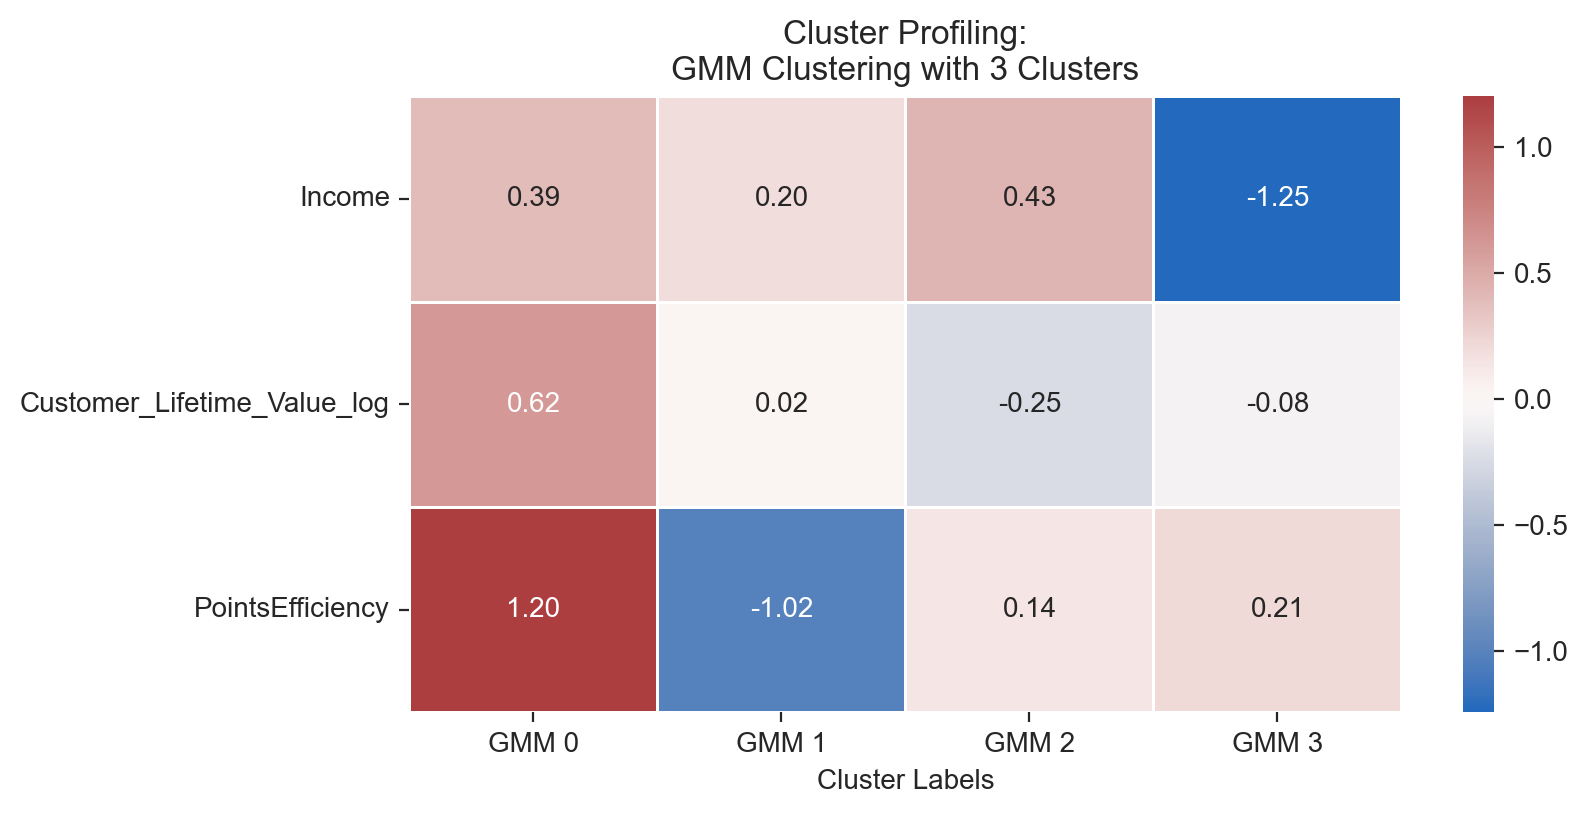

In [122]:
fig, ax = plt.subplots(figsize=(8,4))

means = gmm.means_
n_components, n_features = means.shape

component_names = [f"GMM {k}" for k in range(n_components)]

gmm_means_df = pd.DataFrame(means, columns=clust_features, index=component_names).T

sns.heatmap(gmm_means_df,
            
            ax=ax,
            annot = True,
            fmt = '.2f',
            cmap = 'vlag',
            center=0,
            linewidths=0.4
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nGMM Clustering with 3 Clusters")
plt.show()

GMM 0 – High-Value, High-Efficiency Customers
This cluster is characterized by high Customer Lifetime Value and very high Points Efficiency, combined with above-average income. It represents strongly engaged customers who extract and generate high value from the loyalty program.

GMM 1 – Low-Efficiency, Average-Value Customers
Customers in this cluster have near-average income and CLV, but very low Points Efficiency. This segment reflects under-engaged users who do not effectively interact with the loyalty mechanics despite reasonable economic capacity.

GMM 2 – Income-Driven, Under-Converted Customers
This group shows the highest income levels, while Customer Lifetime Value remains below average and Points Efficiency is close to the mean. These customers have economic potential that has not yet translated into sustained value or loyalty engagement.

GMM 3 – Low-Income, Low-Value Customers
This cluster is defined by very low income and below-average CLV, with slightly positive but modest Points Efficiency. It likely corresponds to early-stage customers or low purchasing-power profiles, such as students or infrequent travelers.

These profiles highlight how the GMM differentiates customers not only by economic capacity but also by how effectively that capacity is converted into long-term value and loyalty behavior.

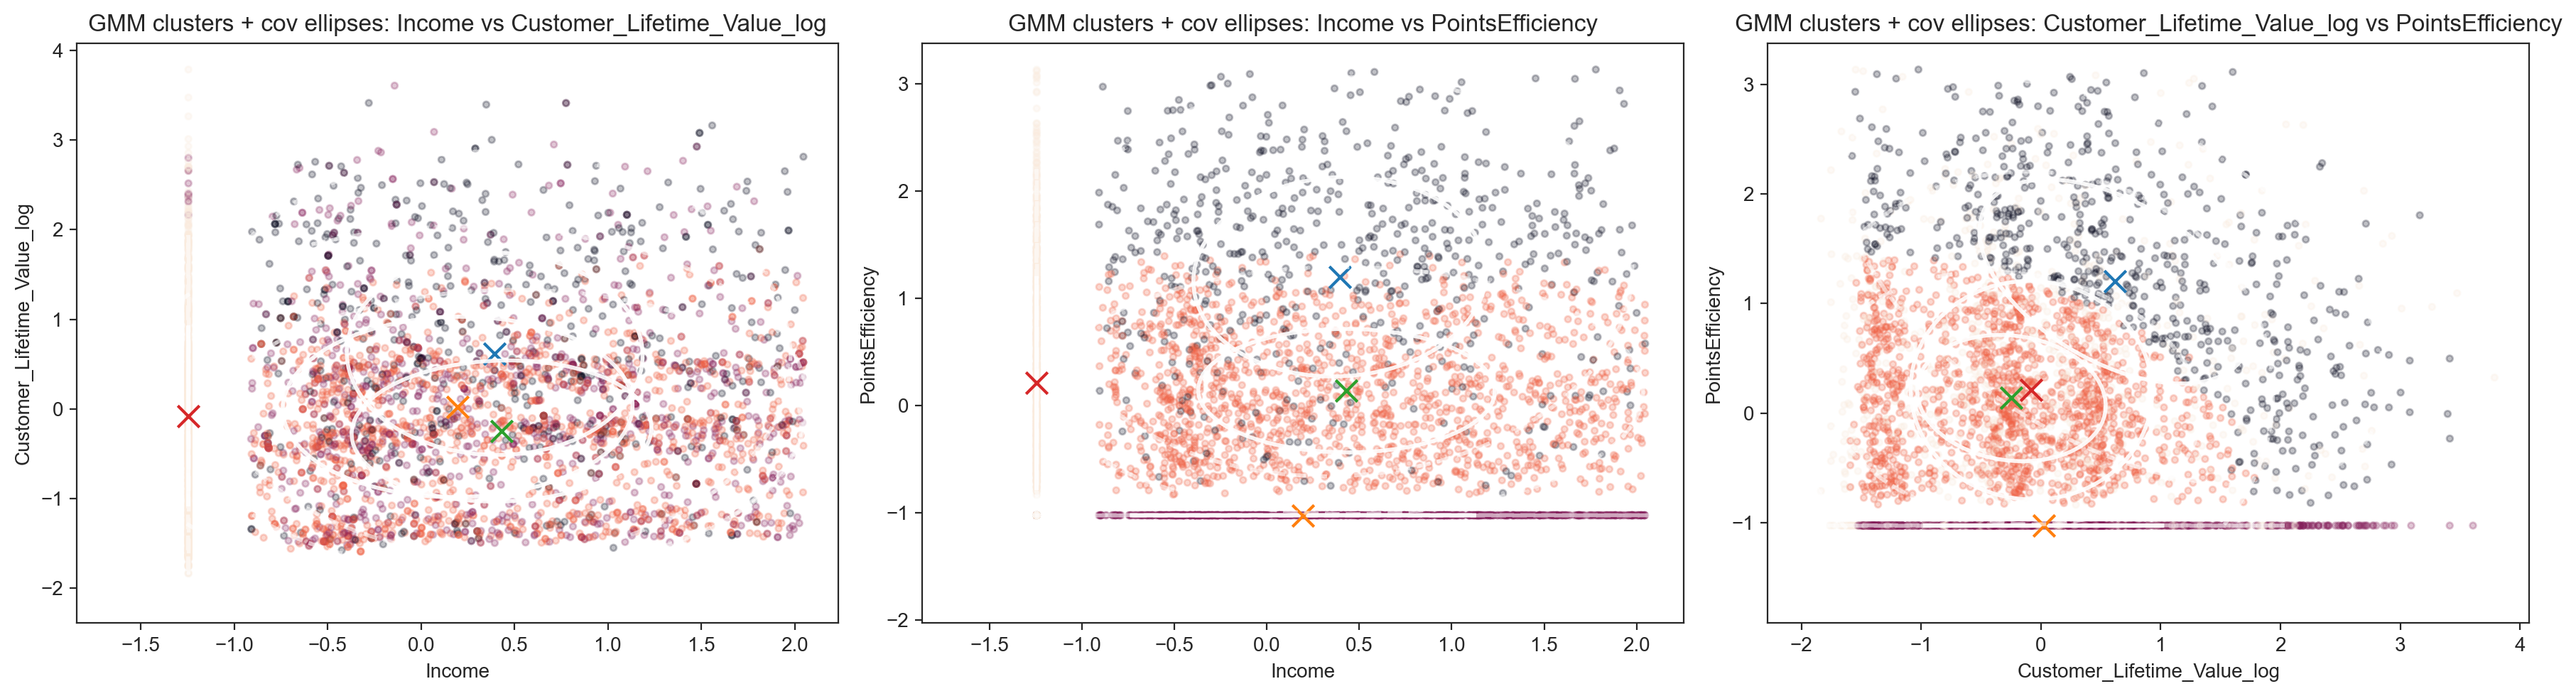

Uncertain (<0.70) = 15.09% (2432 / 16116)


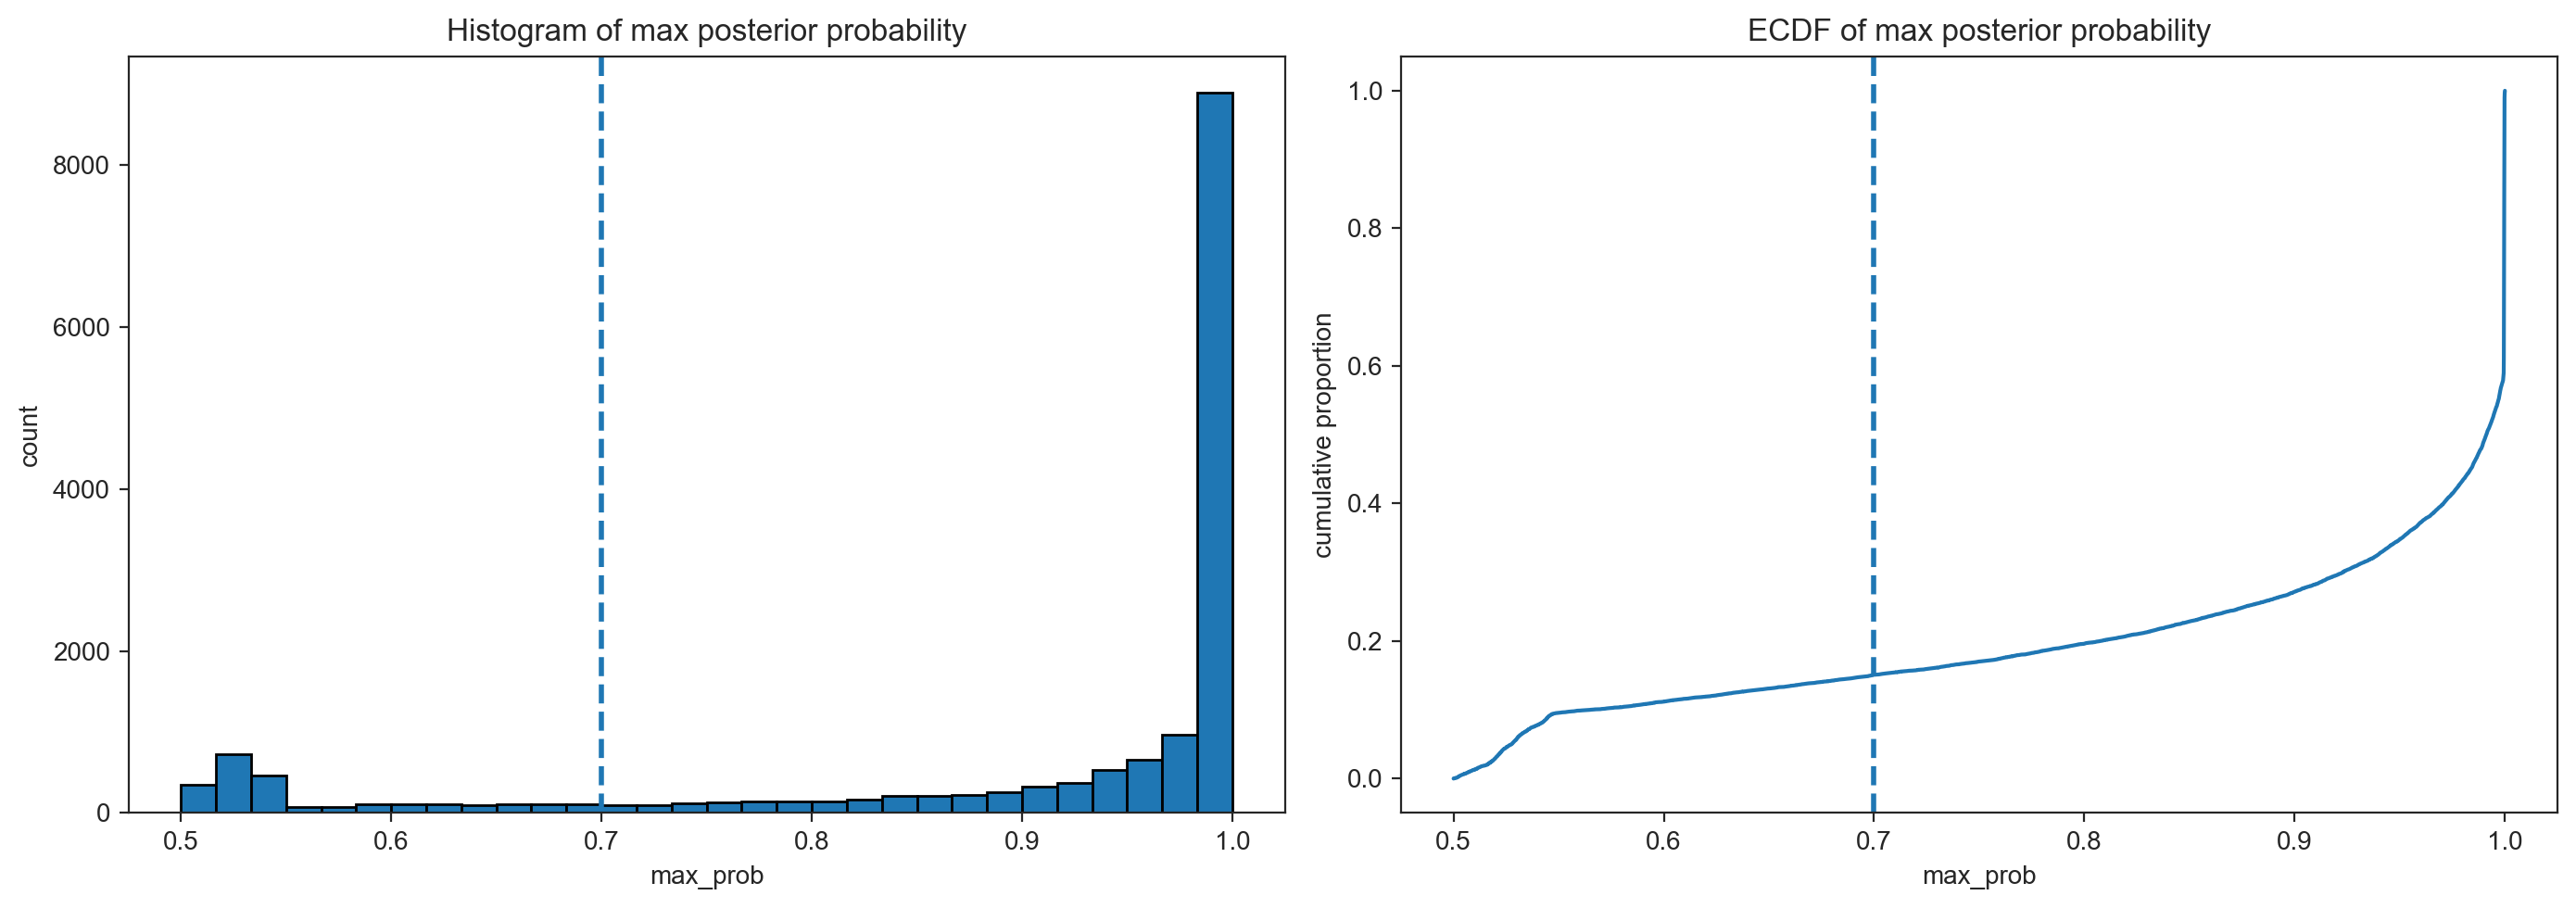

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# =========================
# INPUTS (ajusta aqui)
# =========================
features = clust_features          # lista com 3 nomes de colunas, ex.: ['Income', 'CLV', 'Spend']
X = df_E[features].to_numpy()
labels = gmm_labels                # output de gmm.fit_predict(df_E)
probs = gmm.predict_proba(df_E)    # ou gmm.predict_proba(X)
max_prob = probs.max(axis=1)

# (opcional) subsample para plots mais legíveis
sample = 4000
if len(X) > sample:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X), size=sample, replace=False)
    Xp = X[idx]
    lp = labels[idx]
    pp = probs[idx]
    mp = max_prob[idx]
else:
    Xp = X
    lp = labels
    pp = probs
    mp = max_prob

# =========================
# 1) Scatter 2D por pares + elipses de covariância (1σ e 2σ)
# =========================
pairs = [(0, 1), (0, 2), (1, 2)]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), tight_layout=True)

for ax, (i, j) in zip(axes, pairs):
    ax.scatter(Xp[:, i], Xp[:, j], c=lp, s=10, alpha=0.25)

    for k in range(gmm.n_components):
        mean_ij = gmm.means_[k, [i, j]]
        cov_ij = gmm.covariances_[k][np.ix_([i, j], [i, j])]

        # eigen-decomposition para parâmetros da elipse
        vals, vecs = np.linalg.eigh(cov_ij)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

        # 1σ
        w1, h1 = 2 * 1.0 * np.sqrt(np.maximum(vals, 0))
        e1 = Ellipse(xy=mean_ij, width=w1, height=h1, angle=angle,
                     fill=False, linewidth=2, alpha=0.9)
        ax.add_patch(e1)

        # 2σ
        w2, h2 = 2 * 2.0 * np.sqrt(np.maximum(vals, 0))
        e2 = Ellipse(xy=mean_ij, width=w2, height=h2, angle=angle,
                     fill=False, linewidth=2, alpha=0.6, linestyle="--")
        ax.add_patch(e2)

        # marca a média do componente
        ax.scatter(mean_ij[0], mean_ij[1], s=120, marker="x")

    ax.set_xlabel(features[i])
    ax.set_ylabel(features[j])
    ax.set_title(f"GMM clusters + cov ellipses: {features[i]} vs {features[j]}")

plt.show()


# =========================
# 3) Incerteza: Histograma + ECDF de max_prob (+ limiar)
# =========================
threshold = 0.7
unc = (max_prob < threshold)
print(f"Uncertain (<{threshold:.2f}) = {unc.mean()*100:.2f}% ({unc.sum()} / {len(max_prob)})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)

# Histograma
axes[0].hist(max_prob, bins=30, edgecolor="black")
axes[0].axvline(threshold, linestyle="--", linewidth=2)
axes[0].set_title("Histogram of max posterior probability")
axes[0].set_xlabel("max_prob")
axes[0].set_ylabel("count")

# ECDF
xs = np.sort(max_prob)
ys = np.arange(1, len(xs) + 1) / len(xs)
axes[1].plot(xs, ys)
axes[1].axvline(threshold, linestyle="--", linewidth=2)
axes[1].set_title("ECDF of max posterior probability")
axes[1].set_xlabel("max_prob")
axes[1].set_ylabel("cumulative proportion")

plt.show()


Visually, the GMM first isolates a distinct low-income component, which occupies a separated region along the income axis. Among the remaining customers, separation is driven primarily by PointsEfficiency, effectively splitting the population into low-, mid-, and high-efficiency profiles. Customer lifetime value contributes as a secondary discriminator—particularly within the high-efficiency group—while overlap between intermediate efficiency profiles explains the presence of uncertain assignments near component boundaries.

# DB-Scan

In [124]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

X = df_E[clust_features].to_numpy()

for ms in [6, 8, 10, 15, 25]:
    for eps in [0.28, 0.30, 0.32, 0.34, 0.38]:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        lab = db.fit_predict(X)

        k = len(set(lab)) - (1 if -1 in lab else 0)
        noise = (lab == -1).mean()

        # silhouette só se houver >=2 clusters e pontos não-ruído suficientes
        if k >= 2 and (lab != -1).sum() > 100:
            sil = silhouette_score(X[lab != -1], lab[lab != -1])
        else:
            sil = np.nan

        largest = (np.bincount(lab[lab!=-1]) if (lab!=-1).any() else np.array([0])).max()
        print(f"ms={ms:>2}, eps={eps:.2f} | k={k}, noise={noise:.3f}, sil={sil:.3f}, largest={largest}")

ms= 6, eps=0.28 | k=13, noise=0.017, sil=0.025, largest=11727
ms= 6, eps=0.30 | k=6, noise=0.014, sil=0.090, largest=11831
ms= 6, eps=0.32 | k=4, noise=0.011, sil=0.108, largest=11895
ms= 6, eps=0.34 | k=1, noise=0.008, sil=nan, largest=15982
ms= 6, eps=0.38 | k=2, noise=0.006, sil=0.347, largest=16018
ms= 8, eps=0.28 | k=8, noise=0.029, sil=0.057, largest=11553
ms= 8, eps=0.30 | k=8, noise=0.021, sil=0.069, largest=11699
ms= 8, eps=0.32 | k=5, noise=0.015, sil=0.096, largest=11811
ms= 8, eps=0.34 | k=1, noise=0.012, sil=nan, largest=15918
ms= 8, eps=0.38 | k=1, noise=0.008, sil=nan, largest=15985
ms=10, eps=0.28 | k=8, noise=0.041, sil=0.005, largest=11370
ms=10, eps=0.30 | k=6, noise=0.030, sil=0.075, largest=11554
ms=10, eps=0.32 | k=5, noise=0.023, sil=0.095, largest=11653
ms=10, eps=0.34 | k=1, noise=0.017, sil=nan, largest=15848
ms=10, eps=0.38 | k=1, noise=0.010, sil=nan, largest=15952
ms=15, eps=0.28 | k=5, noise=0.075, sil=0.094, largest=10901
ms=15, eps=0.30 | k=5, noise=0.05

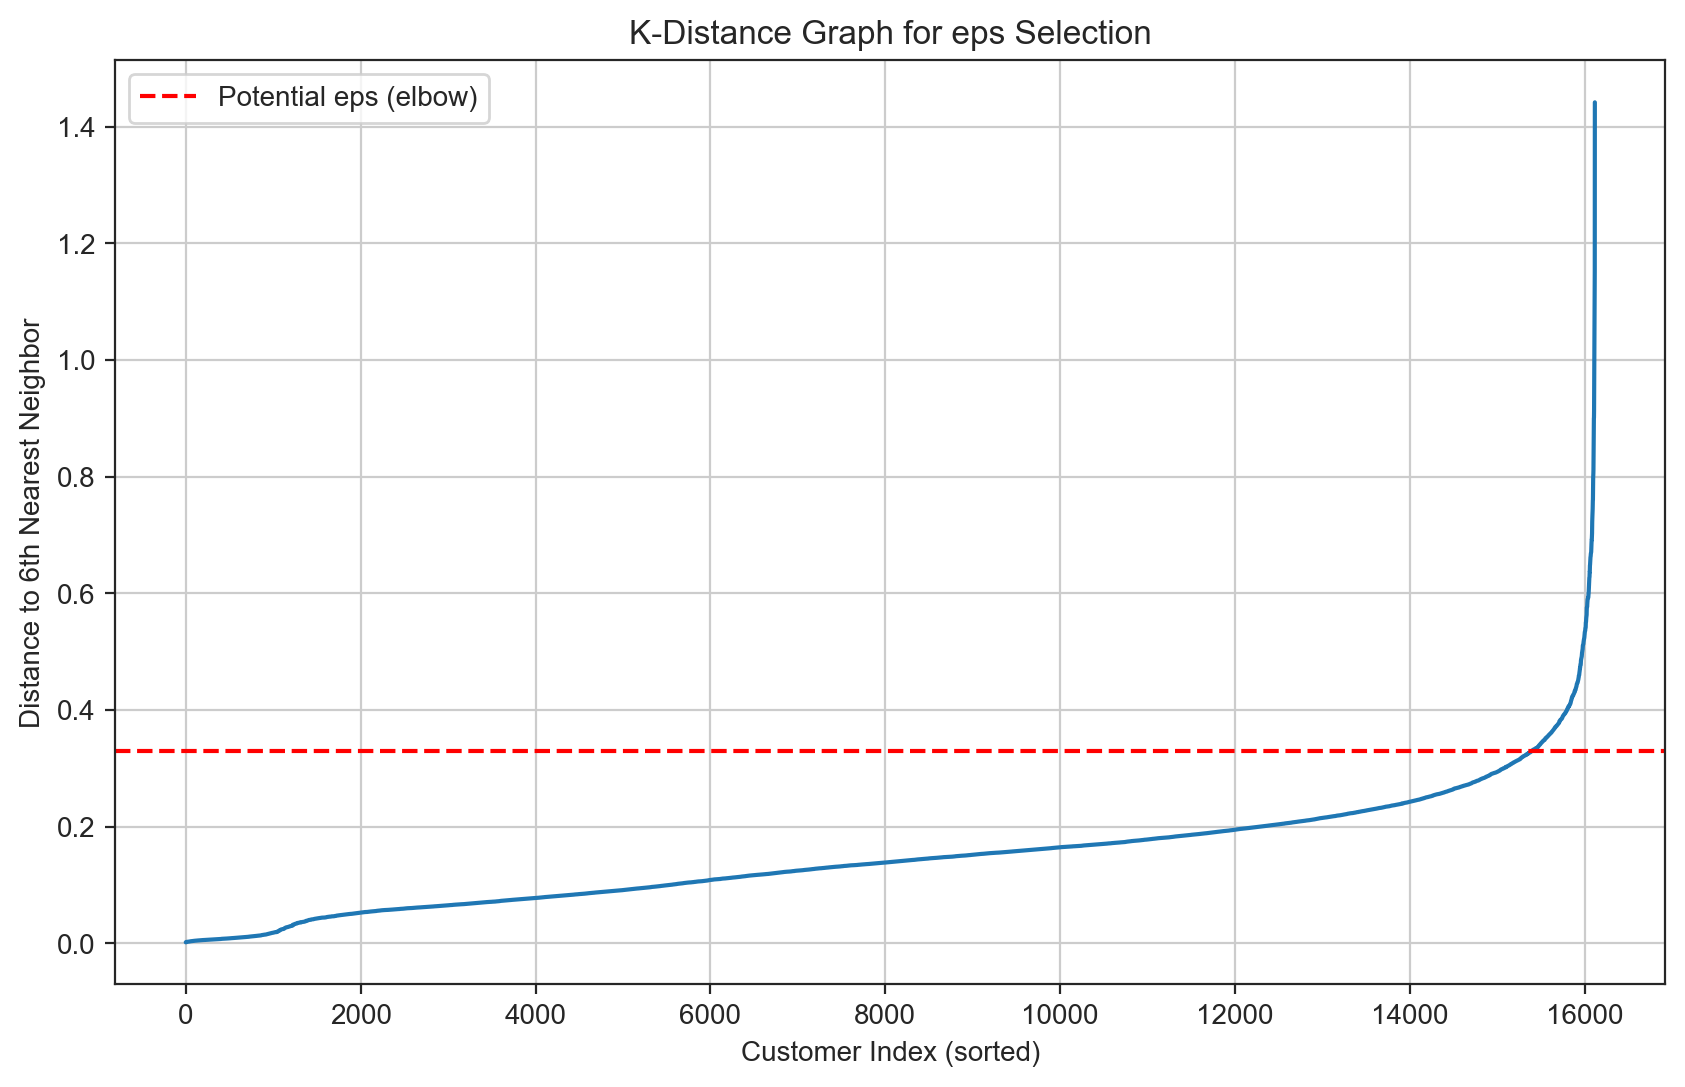

In [ ]:
# Find optimal eps using K-distance method
neigh = NearestNeighbors(n_neighbors=10) # n_features * 2 as a rule of thumb
neigh.fit(df_E)
distances, _ = neigh.kneighbors(df_E)
# matrix of n_samples x n_neighbors nearest neighbors distances
distances = np.sort(distances[:, -1])


plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph for eps Selection")
plt.xlabel("Customer Index (sorted)")
plt.ylabel("Distance to 6th Nearest Neighbor")
plt.grid(True)

plt.axhline(y=0.33, color='r', linestyle='--', label='Potential eps (elbow)')

plt.legend()
plt.show()

eps = 0.33 is a more conservetive "elbow" to reduce fragmentation and micro-clusters.

In [178]:
# Perform DBSCAN clustering
dbscan = DBSCAN(eps=0.33, min_samples=10, n_jobs=-1)

dbscan_labels = dbscan.fit_predict(df_E)
np.unique(dbscan_labels)


array([-1,  0,  1])

In [179]:
df_concat = pd.concat([df_E, pd.Series(dbscan_labels, index=df_E.index, name="dbscan_labels")], axis=1)
df_concat

,Income,Customer_Lifetime_Value_log,PointsEfficiency,dbscan_labels
Loyalty#,,,,
480934,1.066626,-0.756152,0.088211,0
549612,-1.245134,-0.755965,1.171109,1
429460,-1.245134,-0.755909,-0.064875,1
608370,-1.245134,-0.755909,0.740965,1
530508,1.979057,-0.754695,-1.023776,0
...,...,...,...,...
823768,-1.245134,3.507692,-1.023776,-1
680886,1.335682,3.651026,0.866845,-1
776187,-1.245134,3.787575,0.325527,-1


In [180]:
df_concat['dbscan_labels'].value_counts().sort_index()

dbscan_labels
-1      312
 0    11769
 1     4035
Name: count, dtype: int64

In [181]:
r2_db = get_rsq(df_E, clust_features, dbscan_labels)
print(f"DBSCAN R² score: {r2_db:.4f}")

DBSCAN R² score: 0.2090


In [182]:
noise_ratio = np.mean(dbscan_labels == -1)
noise_ratio

0.0193596425912137

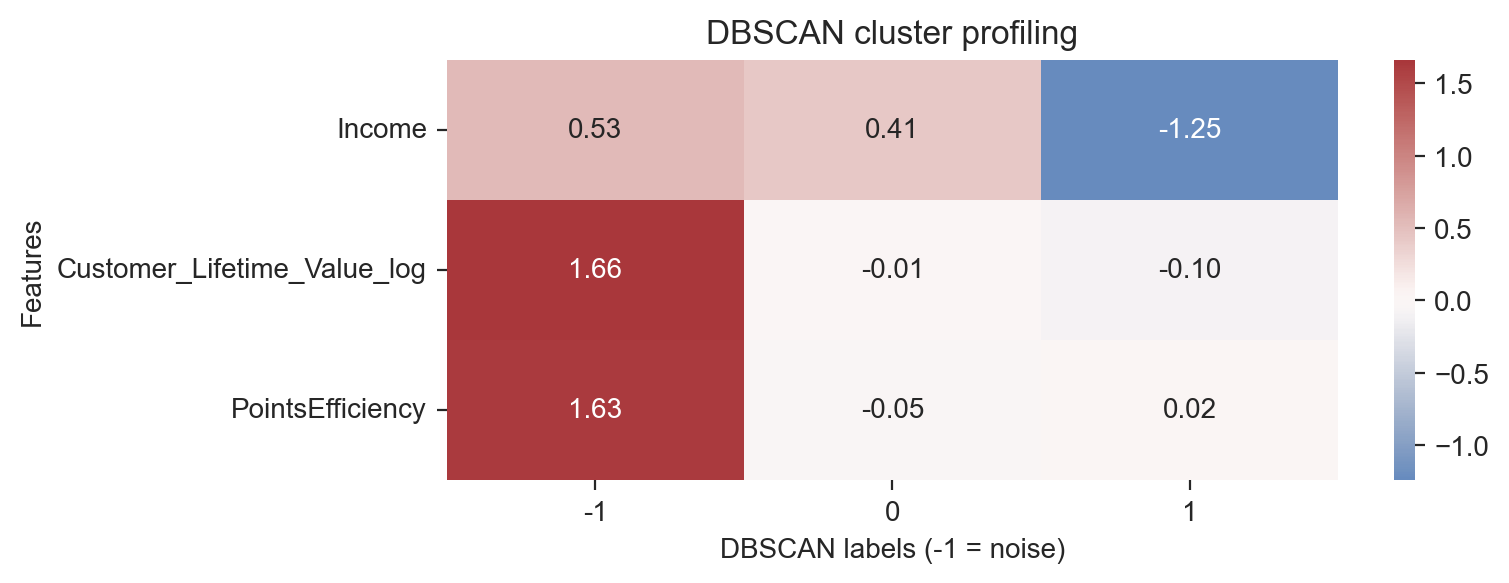

In [183]:
df_db = df_E.copy()
df_db["db"] = dbscan_labels

# médias por cluster (inclui ruído = -1)
profile = df_db.groupby("db").mean().T

plt.figure(figsize=(8,3))
sns.heatmap(
    profile,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
)

plt.title("DBSCAN cluster profiling")
plt.xlabel("DBSCAN labels (-1 = noise)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


The DBSCAN cluster profiling heatmap indicates that cluster 1 is clearly associated with very low income values, while remaining close to the global mean in Customer Lifetime Value and Points Efficiency. This cluster captures a structurally distinct low-income segment rather than noise. In contrast, the label −1 (noise) corresponds to customers with high Customer Lifetime Value and high Points Efficiency, combined with above-average income, reflecting sparse but economically extreme observations rather than a coherent dense cluster. The remaining cluster (label 0) exhibits near-average values across all variables and represents the main dense region of the data. Overall, the results show that DBSCAN primarily isolates a low-income group and flags high-value, low-density observations as noise, rather than producing a balanced multi-cluster economic segmentation.

2. Behavior-based : Based on flight frequency, distance, type of trip, and seniority in the program.

In [132]:
df_B = df_final[['Flights_Sum','FlightsComp_Sum','Days_sub','DistPerFlight_log']]

3. Demographic (profile-based) : Based on personal characteristics and location influence customer behavior.

In [133]:
df_D = df_final[['Gender_female' , 'Gender_male','Education_Encoded','Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single','Province_FE','City_FE','EnrollmentType_2021 Promotion', 'EnrollmentType_Standard']]

LoyaltyStatus  